# Compare Spike Train Similarity for Visually Evoked vs Electrically Evoked Responses

In [274]:
%reload_ext autoreload
%autoreload 2

# Imports
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from tqdm import tqdm
import pickle
import src.utils.preprocess as preprocess
# import src.utils.sigmoid as sigmoid
from scipy.io import savemat, loadmat
from scipy.signal import convolve2d
from scipy.stats import zscore, norm, chi2, chisquare, ncx2, ttest_ind, mannwhitneyu
import re
import visionloader as vl
import sta_utils as su
from scipy.spatial import ConvexHull
import src.utils.cellmap as cellmap
import src.utils.encoding_decoding_simulation_pooled as edsp
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Ellipse
from PIL import Image
import multiprocessing
from multiprocessing import Pool
import warnings

import sys
sys.path.append('/Volumes/Lab/Users/ajphillips/greedy/src/')
import sigmoid

from quantities import ms, s, Hz
from elephant.spike_train_generation import homogeneous_poisson_process
from elephant.spike_train_dissimilarity import victor_purpura_distance
from neo.core import SpikeTrain

Paths

In [268]:
piece = '2024-07-18-0'
analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}"
spike_path = os.path.join(analysis_base, "spikes")
label = ""

frame_no = 9
vstim_trial = 0

In [269]:
# The dictionary and associated data is stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
dict_path = os.path.join(analysis_base, "dictionary")

# Load relevant data from .npz files
with np.load(os.path.join(dict_path,f"selective_stimuli{label}.npz")) as data:
    selective_stimuli = data["selective_stimuli"]

selective_cells_of_interest = np.unique(selective_stimuli[:,1]).astype(int)

Transform to SpikeTrain objects

In [270]:
vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

vstim_spike_trains = np.empty((vstim_responses.shape[0], vstim_responses.shape[1]), dtype=object)
for i in range(vstim_responses.shape[0]):
    for j in range(vstim_responses.shape[1]):
        vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i,j]*ms, t_start=-5.0*ms, t_stop=505.0*ms)

estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], estim_espont_responses.shape[1]), dtype=object)
for i in range(estim_espont_responses.shape[0]):
    for j in range(estim_espont_responses.shape[1]):
        estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i,j]*ms, t_start=-5.0*ms, t_stop=505.0*ms)

In [271]:
print(vstim_responses.shape)
print(estim_espont_responses.shape)

(10, 53)
(15, 53)


Compute Victor-Purpura spike train distances

In [272]:
q = 1. / (10. * ms) # q=0 means no cost for any shift of spikes, q=np.inf means infinite cost for any spike shift and hence exclusion of spike shifts

vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
for i in tqdm(range(vstim_spike_trains.shape[1])):

    spike_train_list = []
    for j in range(vstim_spike_trains.shape[0]):
        spike_train_list.append(vstim_spike_trains[j,i])

    vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
for i in tqdm(range(estim_espont_spike_trains.shape[1])):

    spike_train_list = []
    spike_train_list.append(vstim_spike_trains[vstim_trial,i])
    for j in range(estim_espont_spike_trains.shape[0]):
        spike_train_list.append(estim_espont_spike_trains[j,i])

    estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

100%|██████████| 53/53 [00:14<00:00,  3.76it/s]


In [273]:
print(vstim_vp_distance.shape)
print(estim_espont_vp_distance.shape)

(53, 10, 10)
(53, 16, 16)


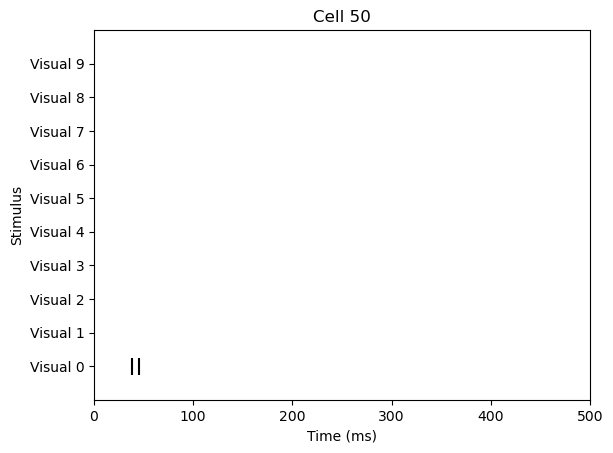

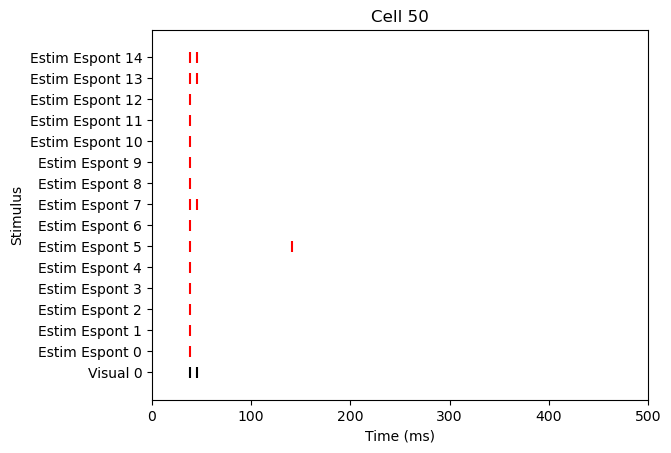

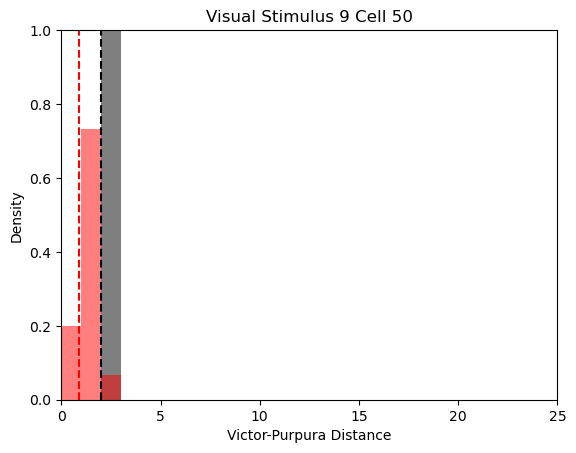

MannwhitneyuResult(statistic=9.0, pvalue=0.9999318859951732)


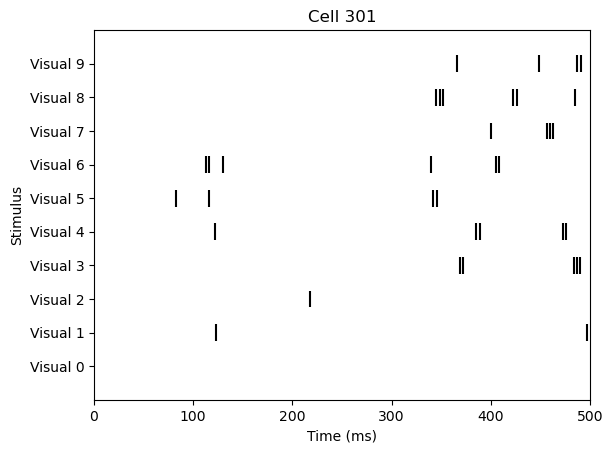

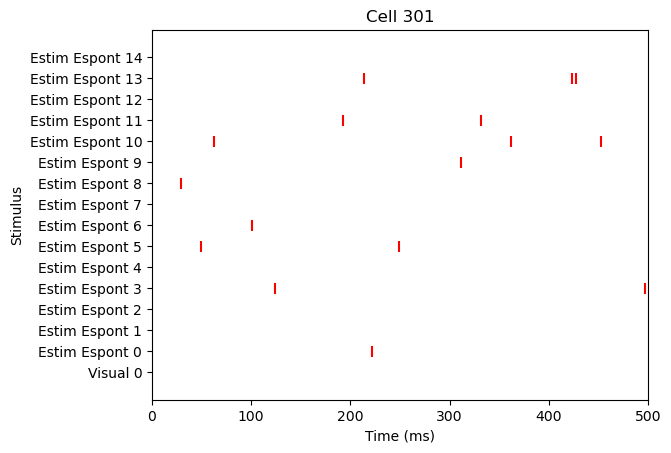

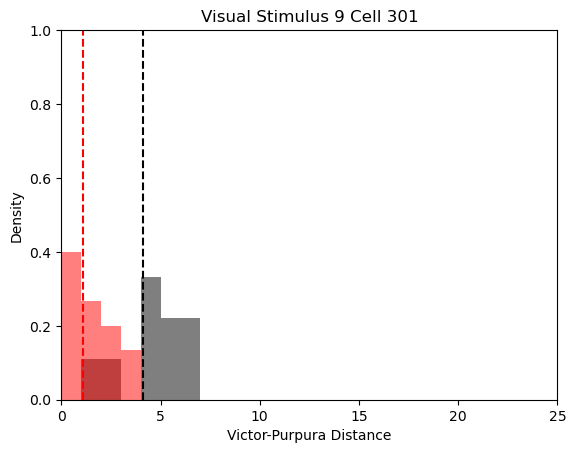

MannwhitneyuResult(statistic=10.5, pvalue=0.9997526380651742)


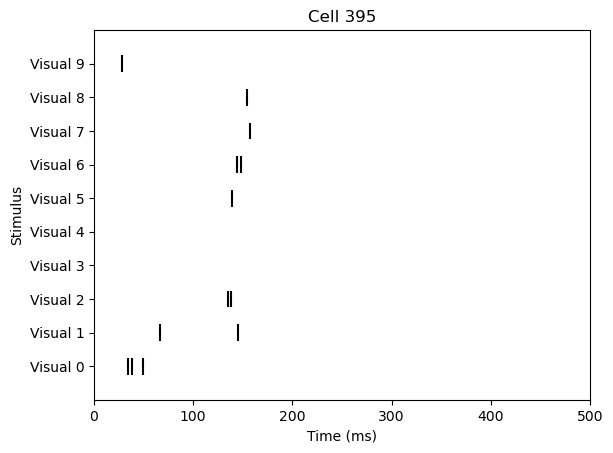

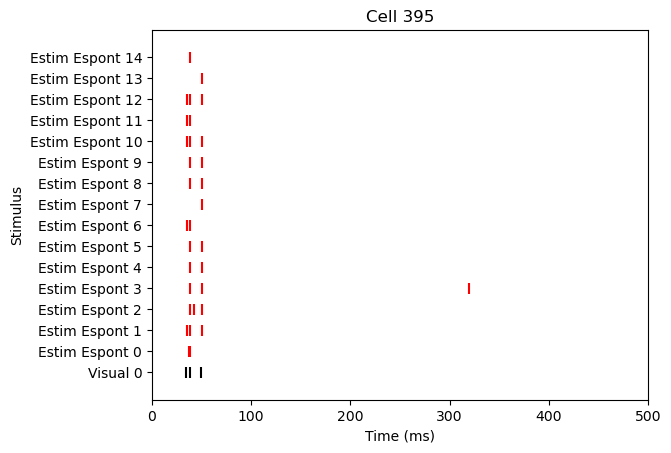

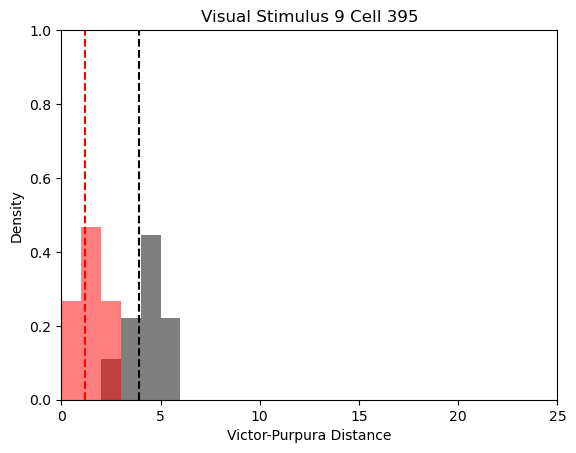

MannwhitneyuResult(statistic=0.0, pvalue=0.9999769204534713)


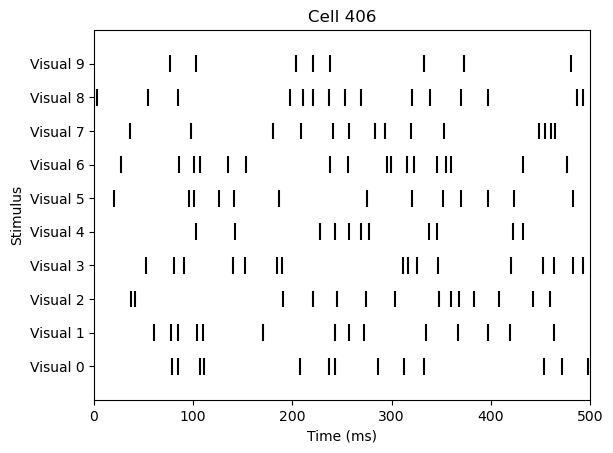

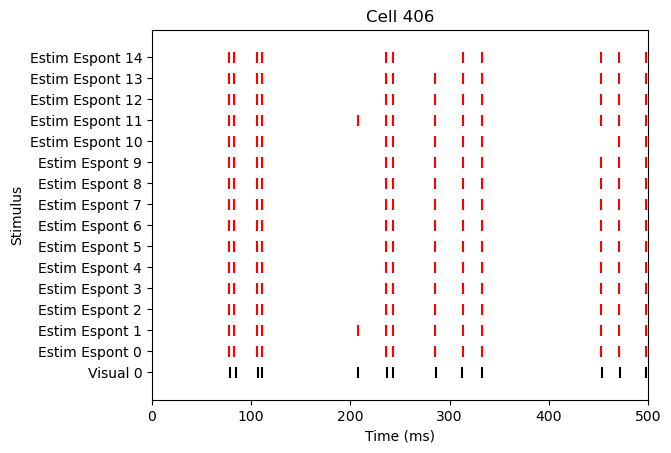

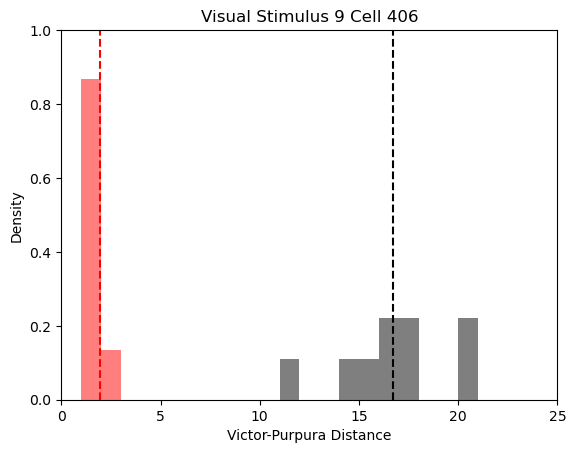

MannwhitneyuResult(statistic=0.0, pvalue=0.9999899962192096)


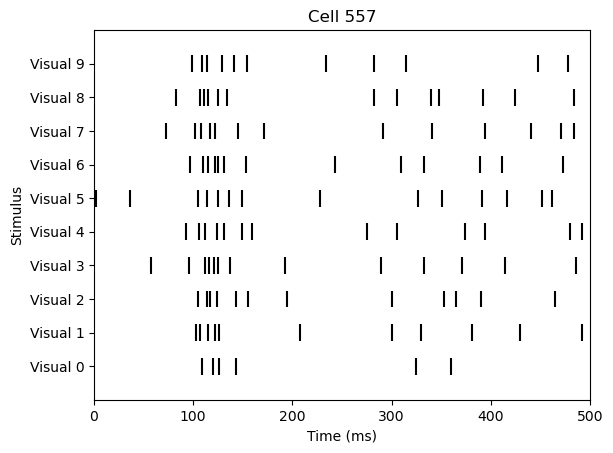

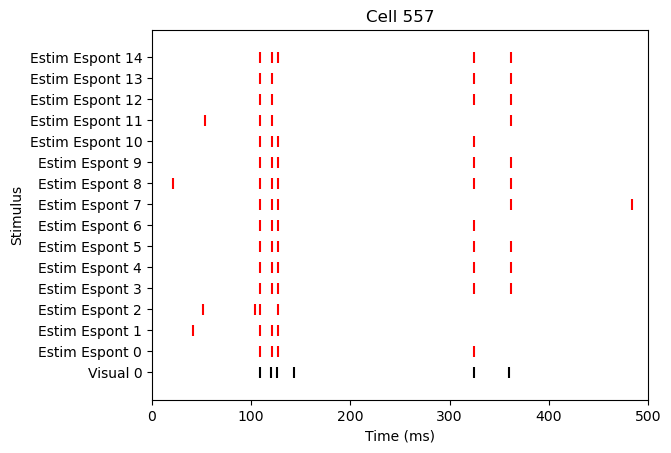

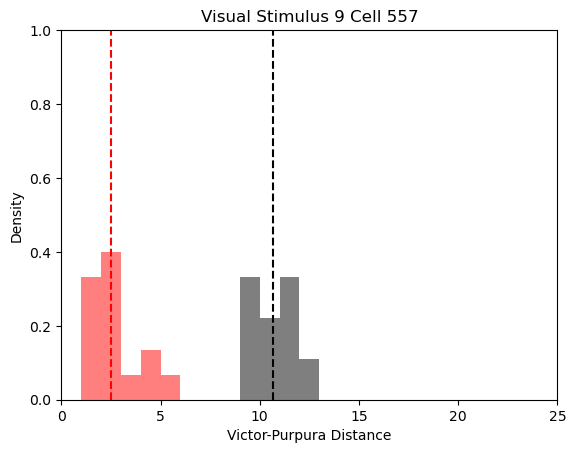

MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


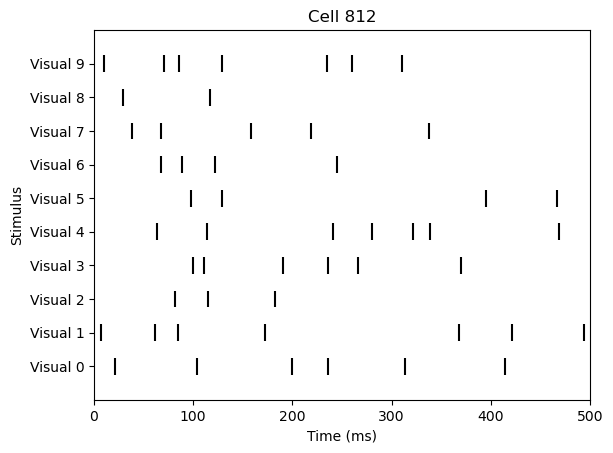

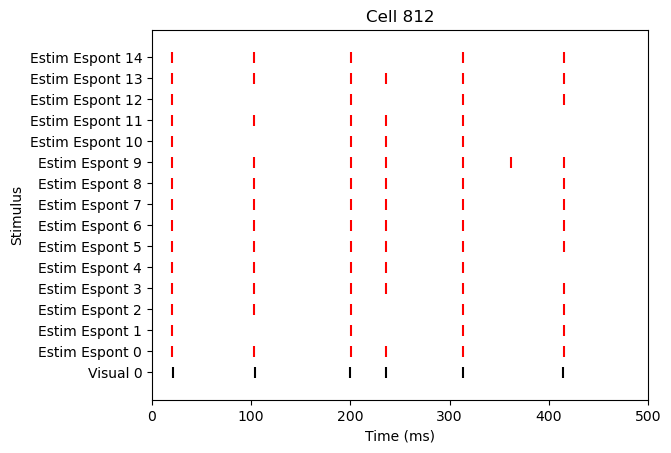

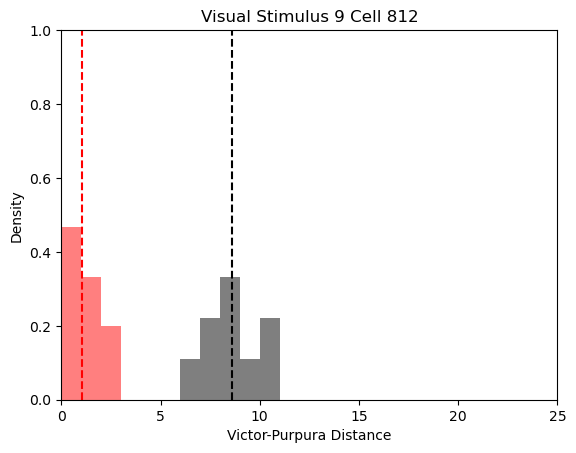

MannwhitneyuResult(statistic=0.0, pvalue=0.9999802613503512)


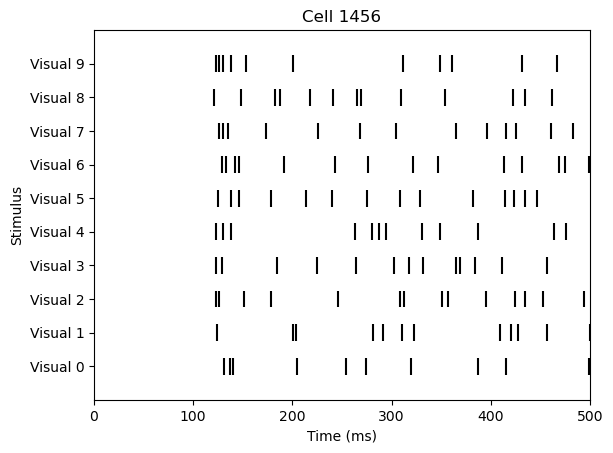

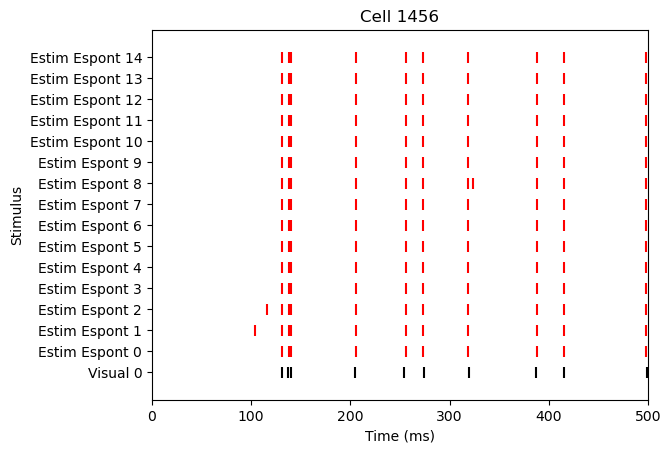

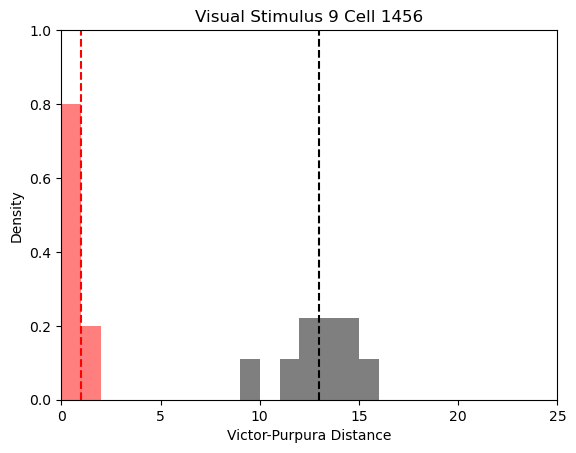

MannwhitneyuResult(statistic=0.0, pvalue=0.9999927907878348)


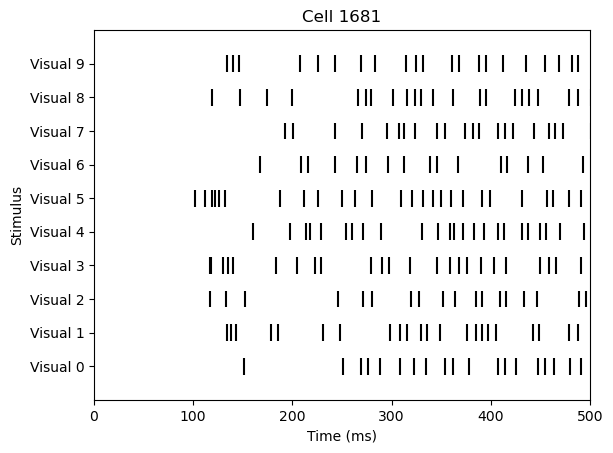

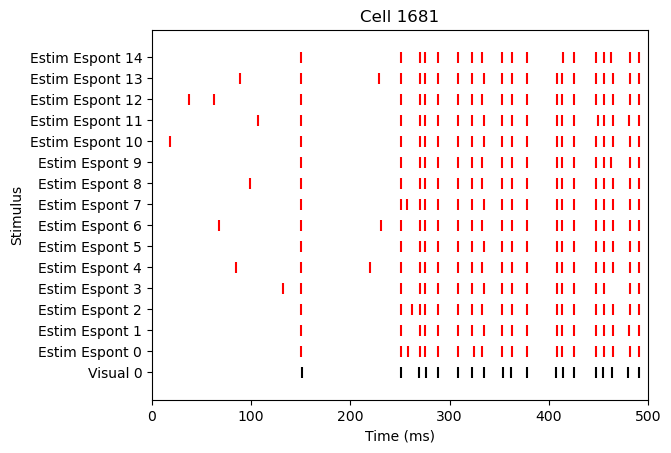

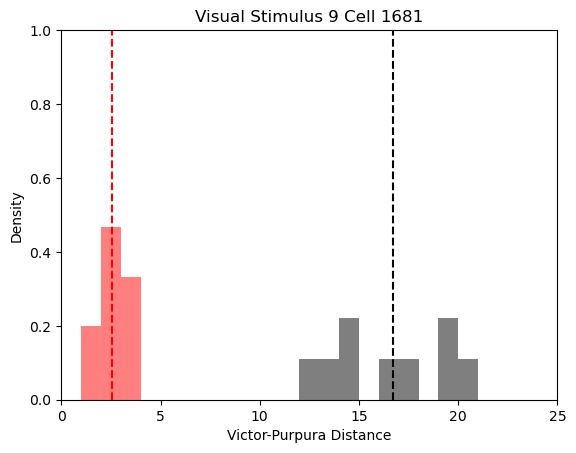

MannwhitneyuResult(statistic=0.0, pvalue=0.9999749990768718)


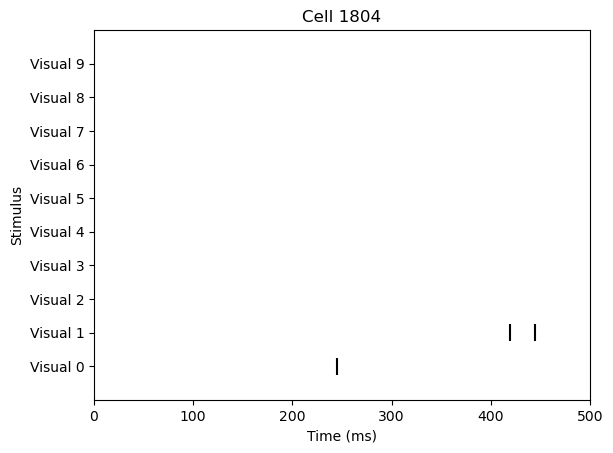

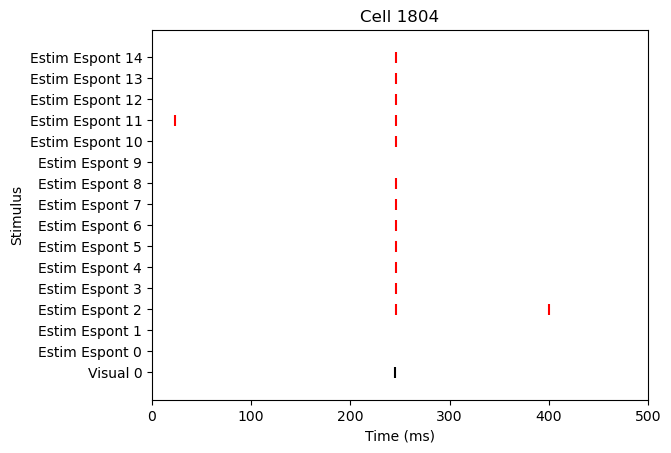

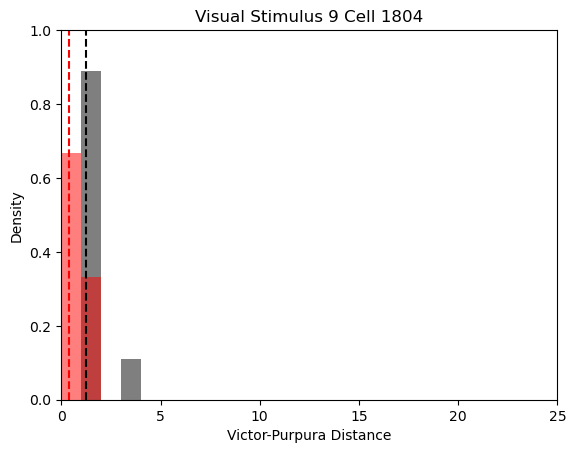

MannwhitneyuResult(statistic=28.0, pvalue=0.9955335115057431)


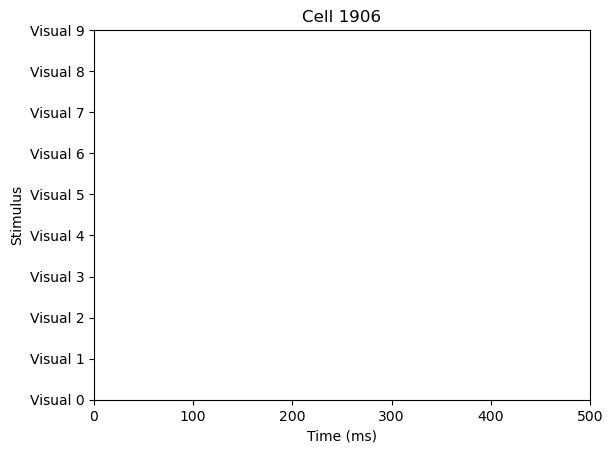

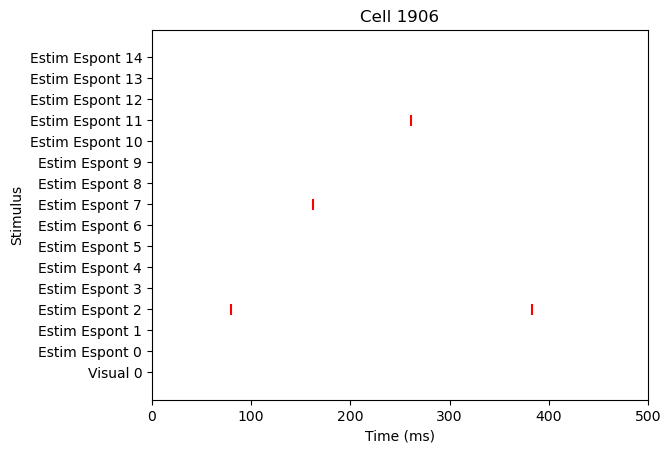

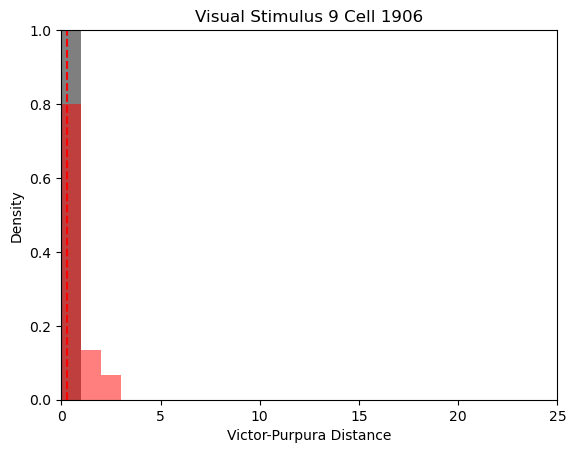

MannwhitneyuResult(statistic=81.0, pvalue=0.08860455417060059)


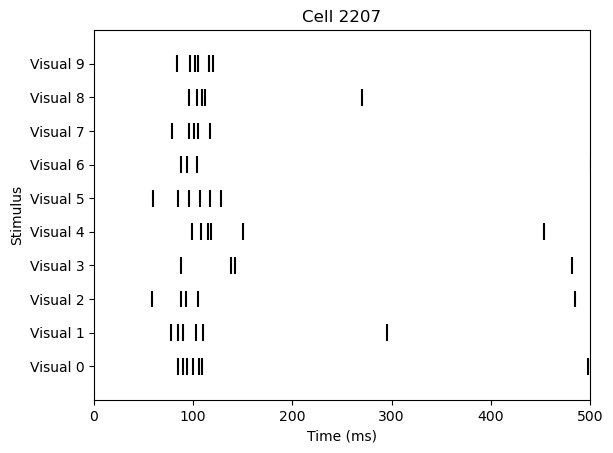

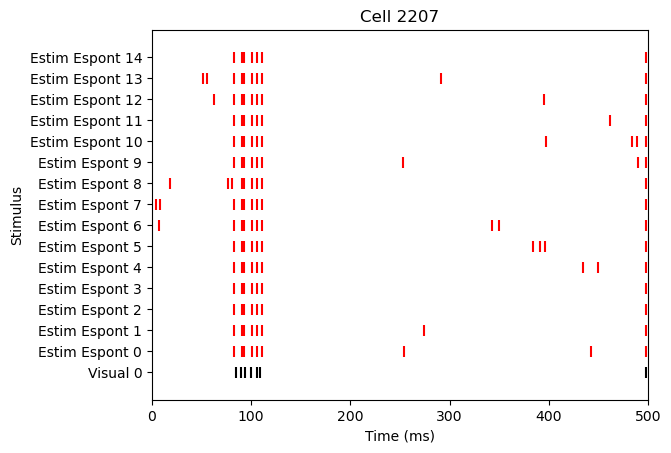

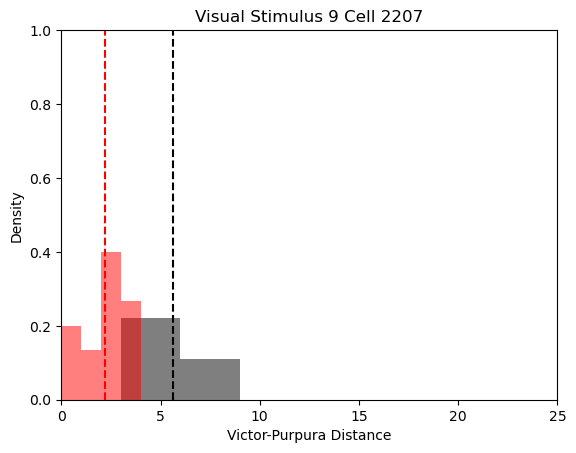

MannwhitneyuResult(statistic=0.0, pvalue=0.9999780510630766)


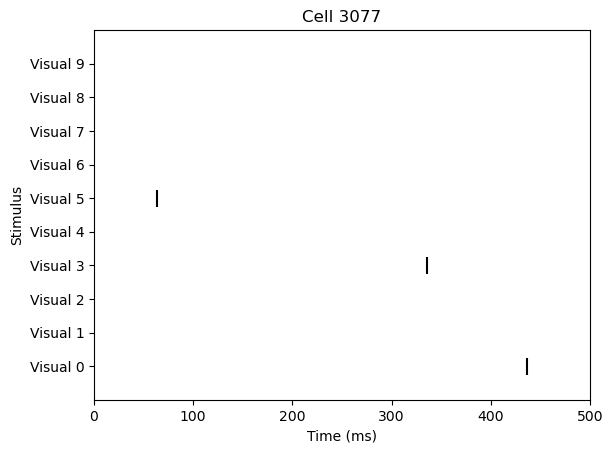

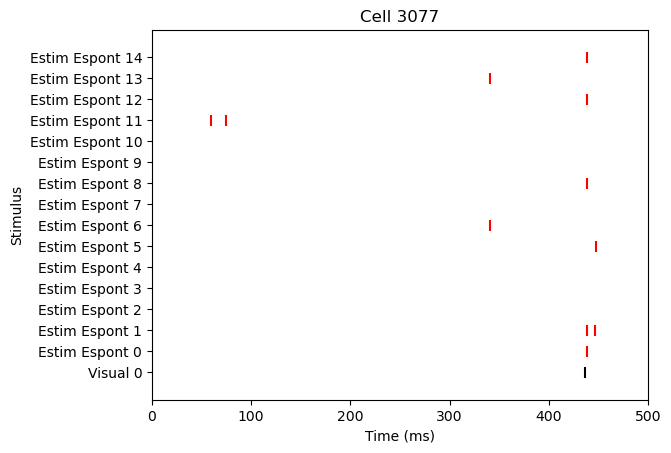

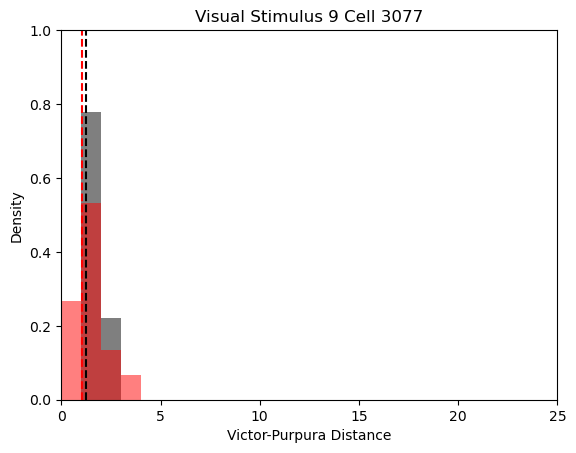

MannwhitneyuResult(statistic=60.0, pvalue=0.6993906333788673)


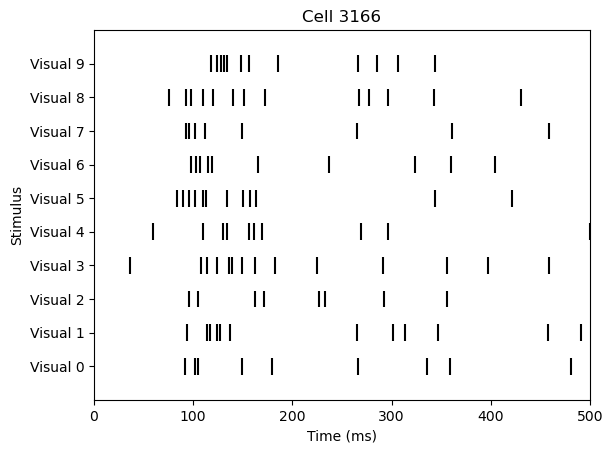

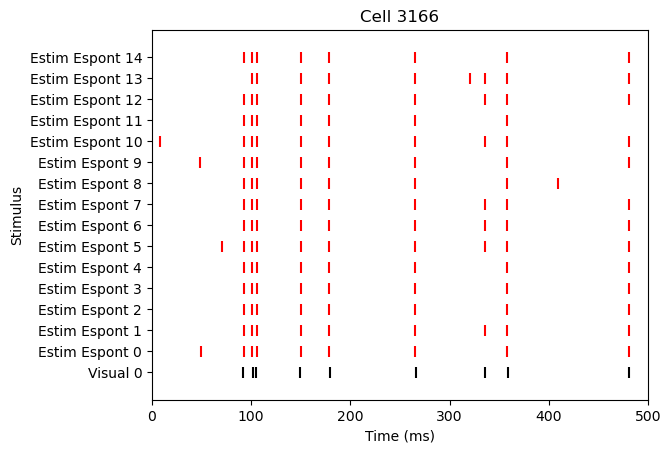

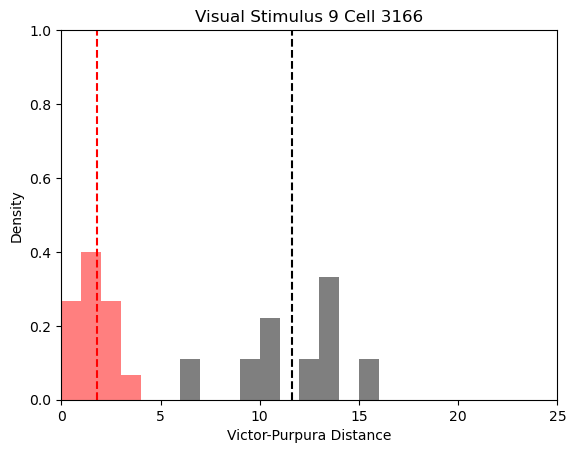

MannwhitneyuResult(statistic=0.0, pvalue=0.9999769204534713)


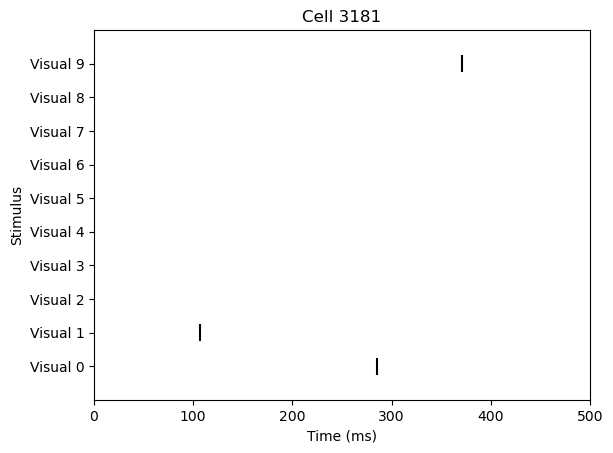

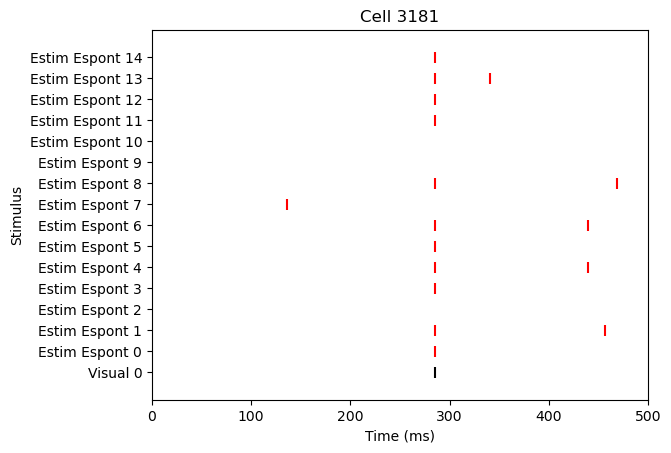

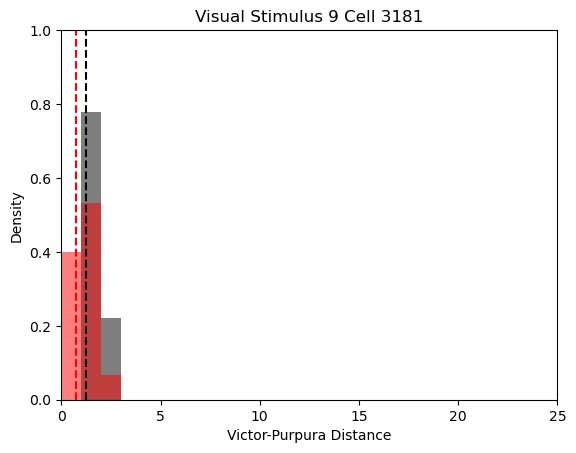

MannwhitneyuResult(statistic=53.5, pvalue=0.8186056455488633)


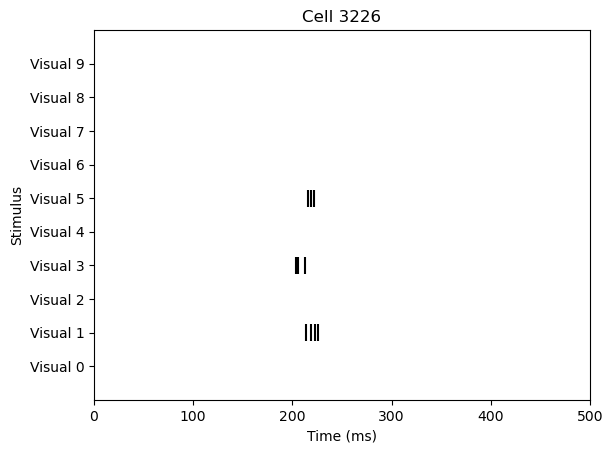

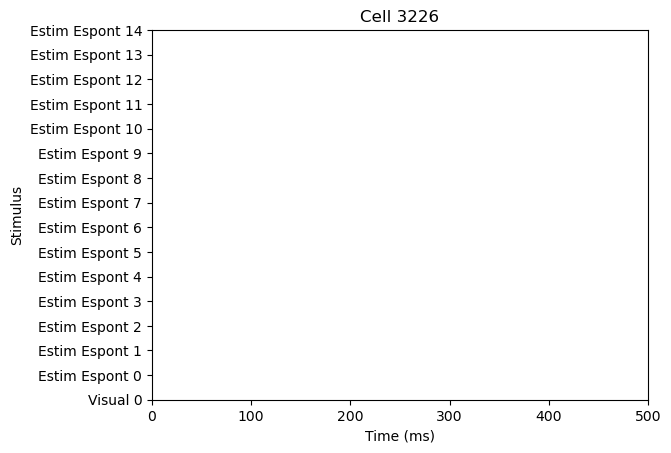

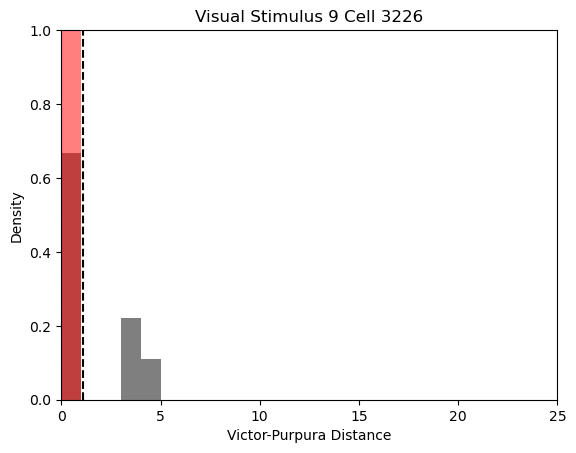

MannwhitneyuResult(statistic=45.0, pvalue=0.9915159161397729)


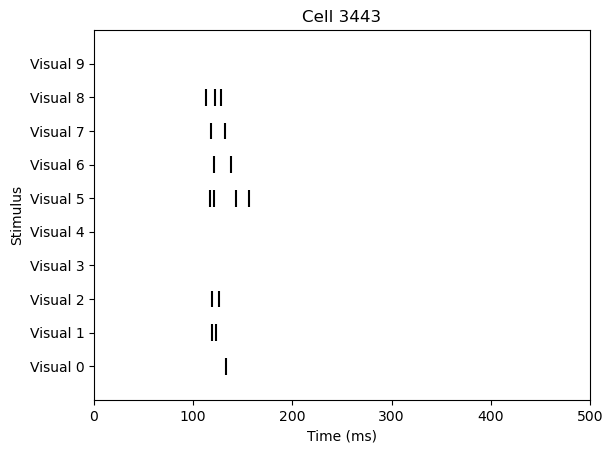

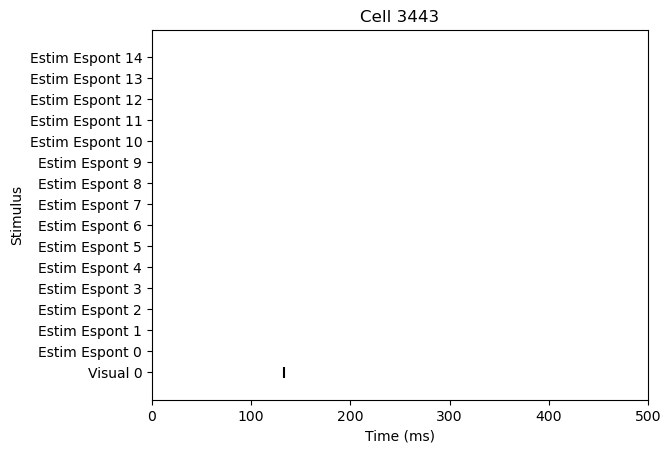

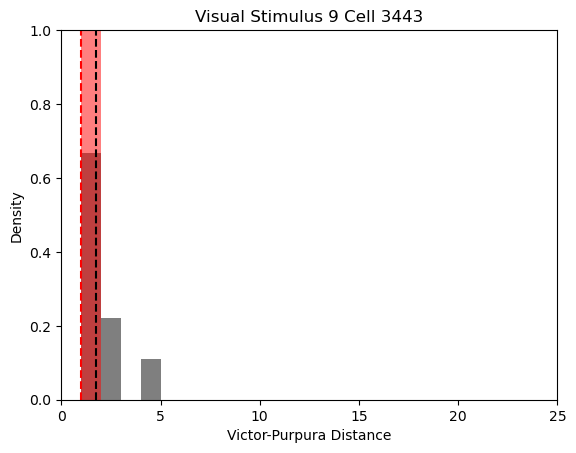

MannwhitneyuResult(statistic=22.5, pvalue=0.9998190970900115)


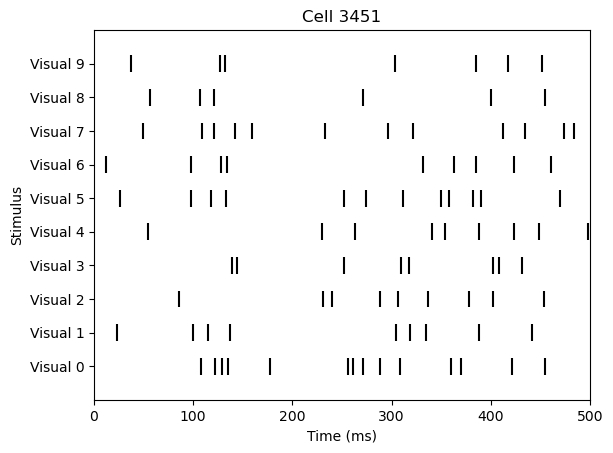

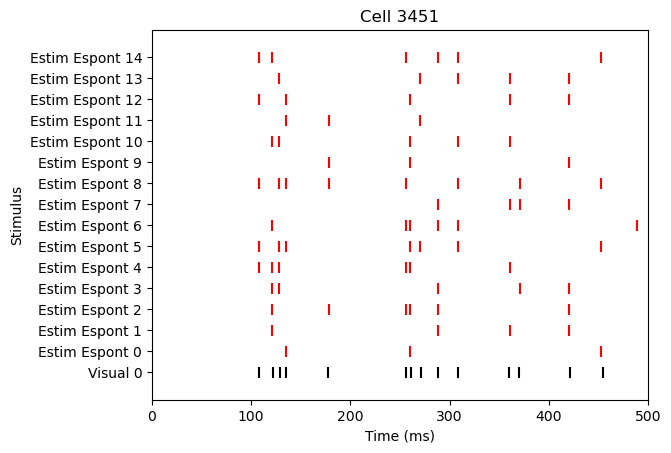

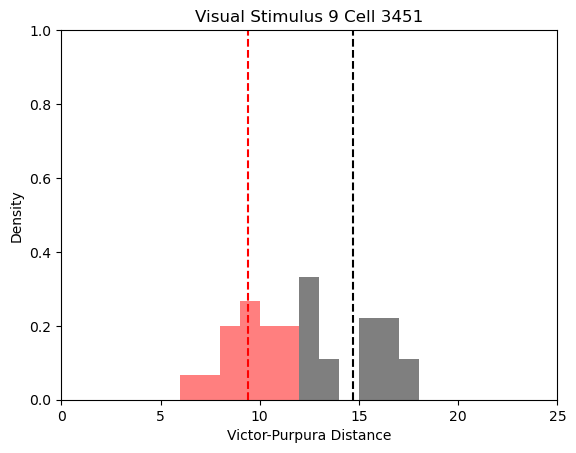

MannwhitneyuResult(statistic=0.0, pvalue=0.9999750932910957)


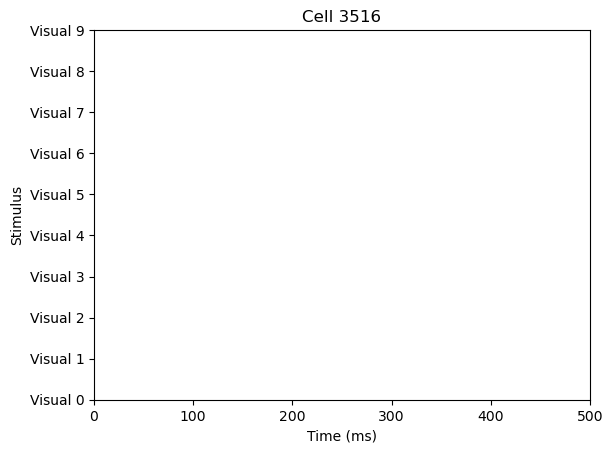

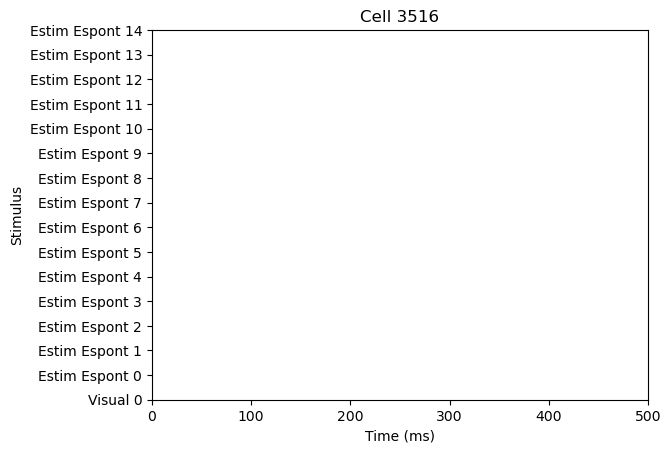

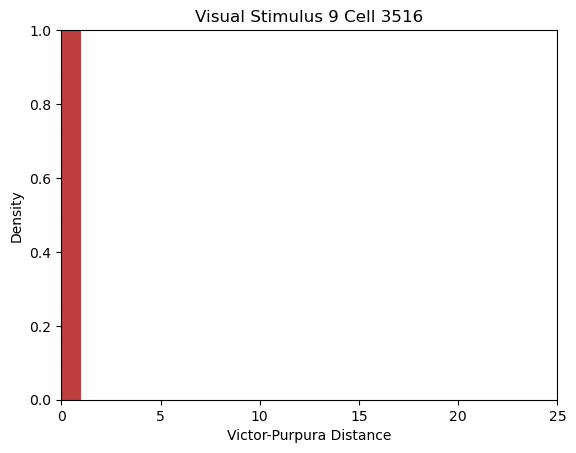

MannwhitneyuResult(statistic=67.5, pvalue=1.0)


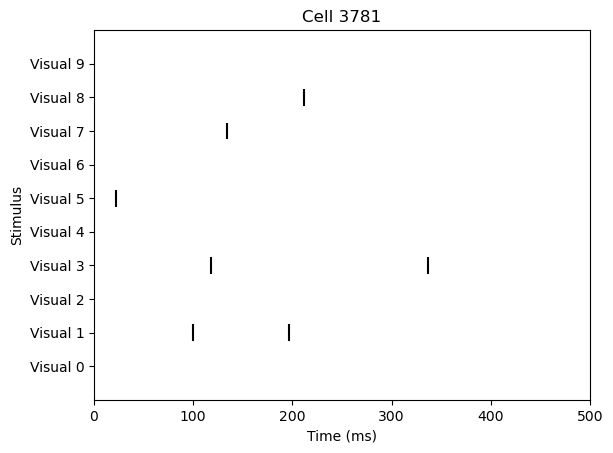

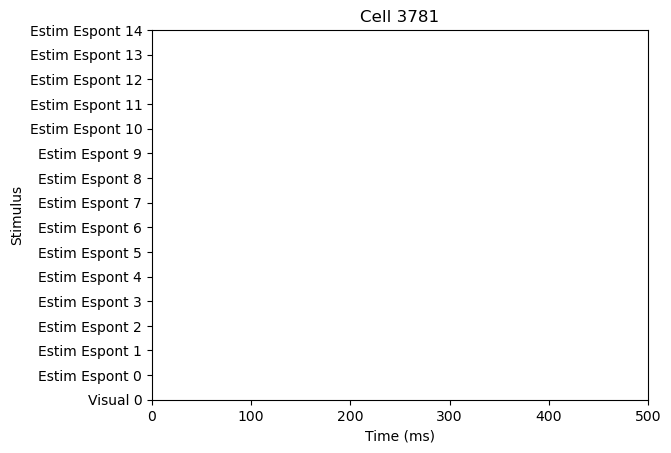

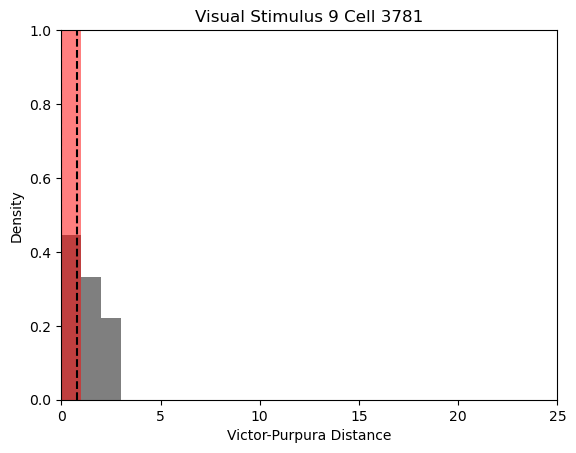

MannwhitneyuResult(statistic=30.0, pvalue=0.9993068727023359)


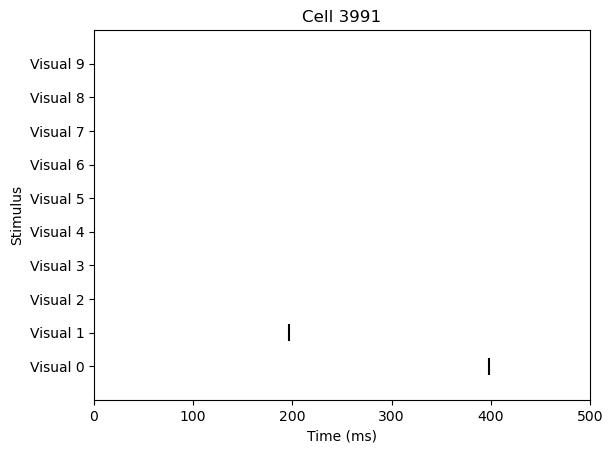

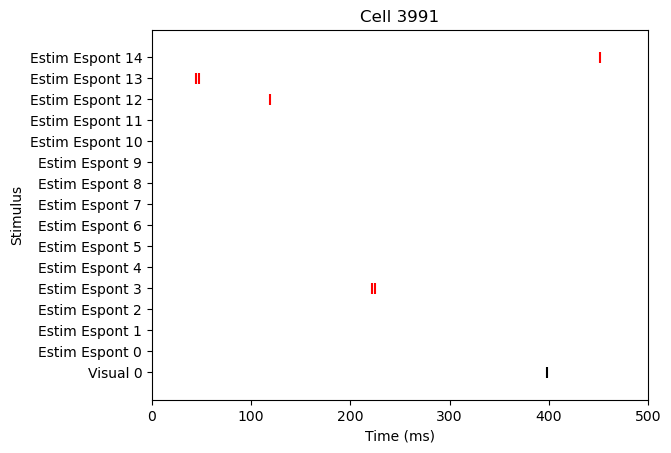

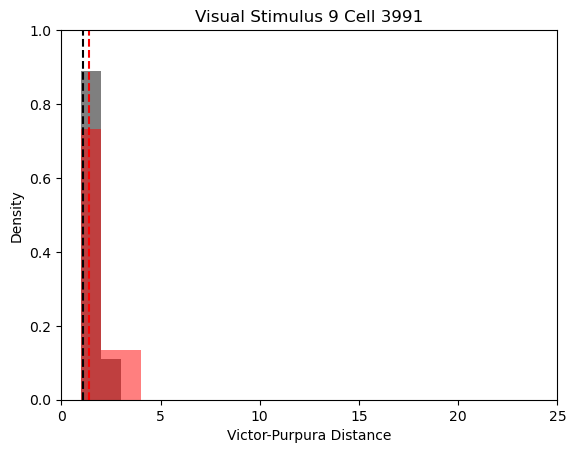

MannwhitneyuResult(statistic=79.0, pvalue=0.17732916294886852)


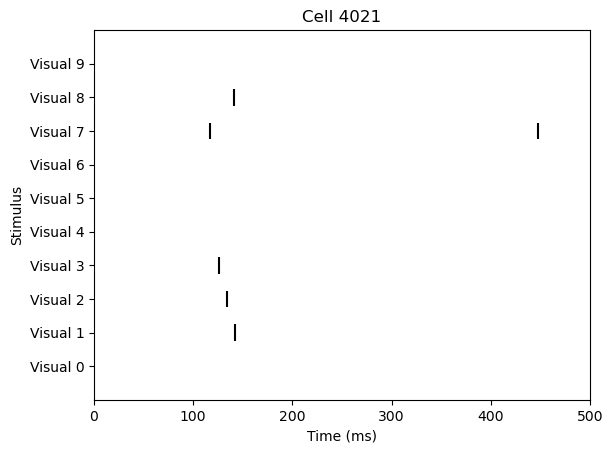

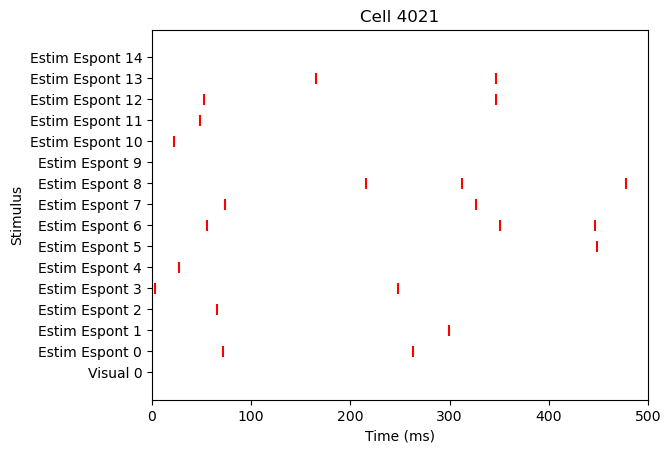

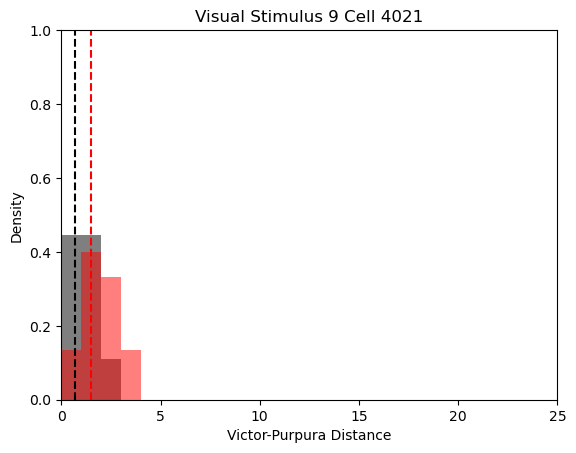

MannwhitneyuResult(statistic=100.5, pvalue=0.020391969017256033)


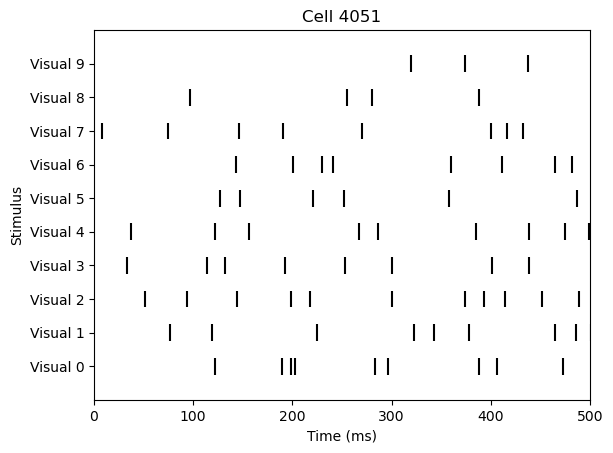

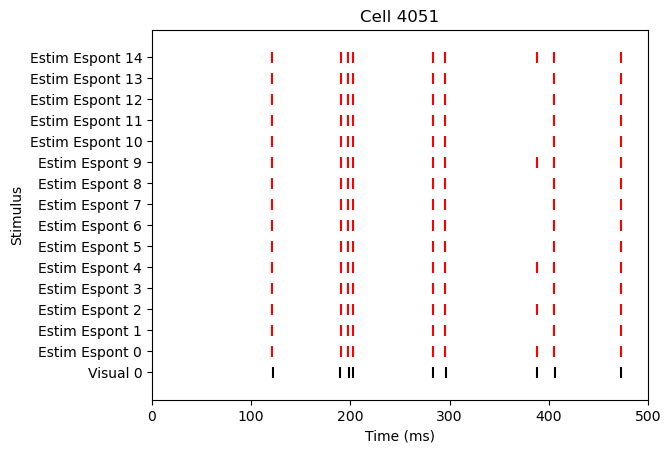

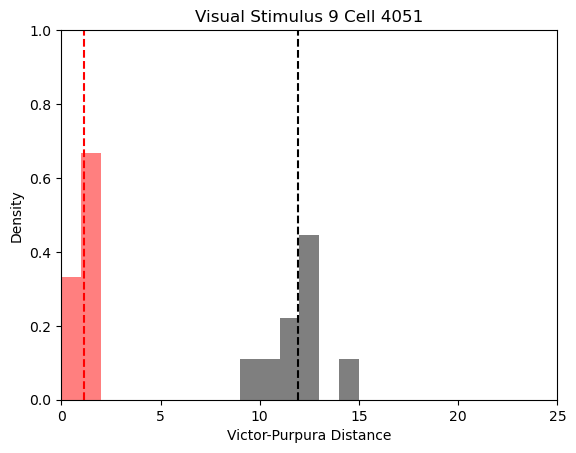

MannwhitneyuResult(statistic=0.0, pvalue=0.9999882296603285)


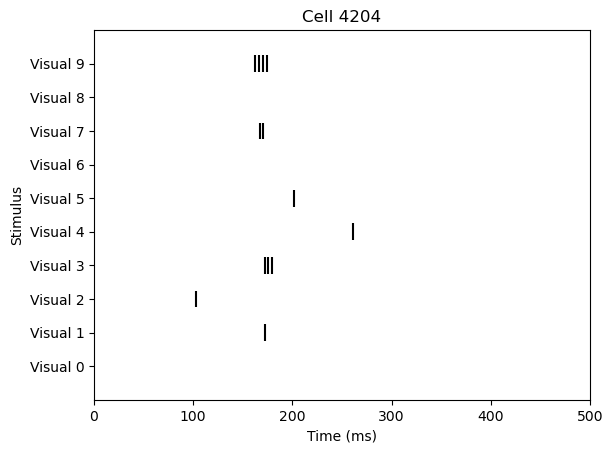

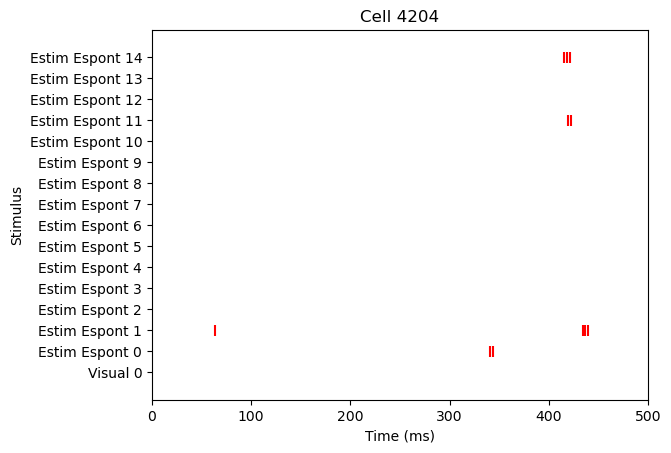

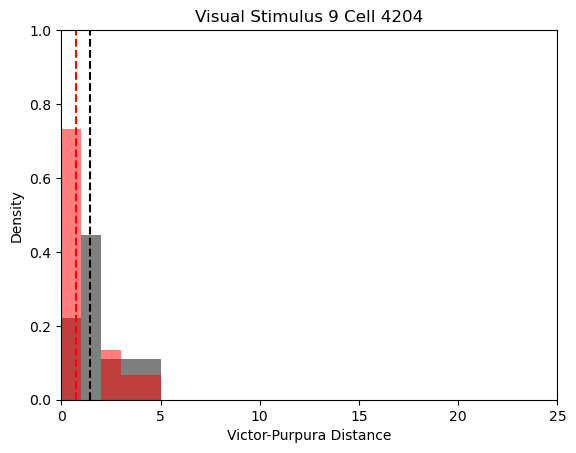

MannwhitneyuResult(statistic=40.0, pvalue=0.9661774722766465)


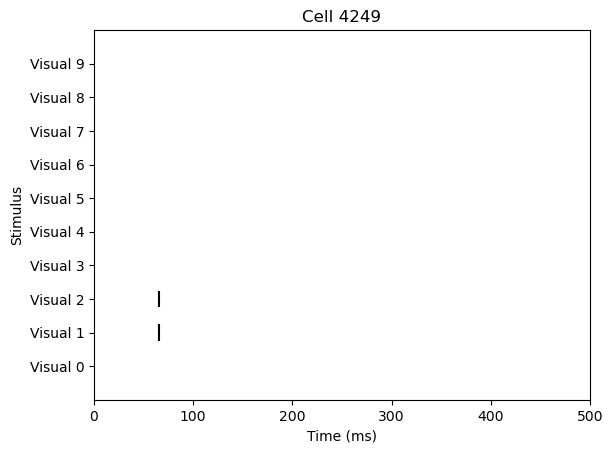

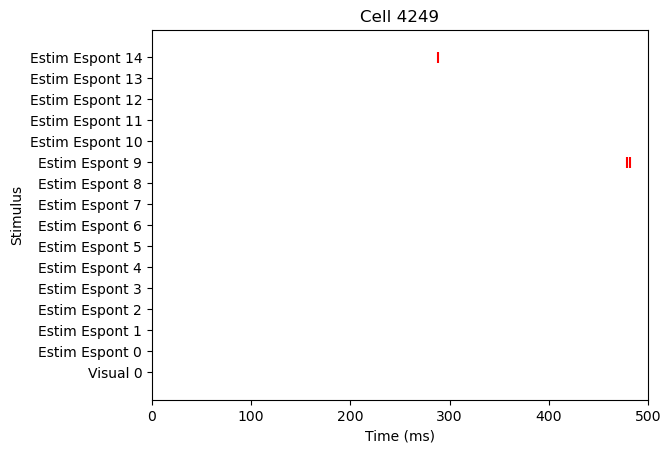

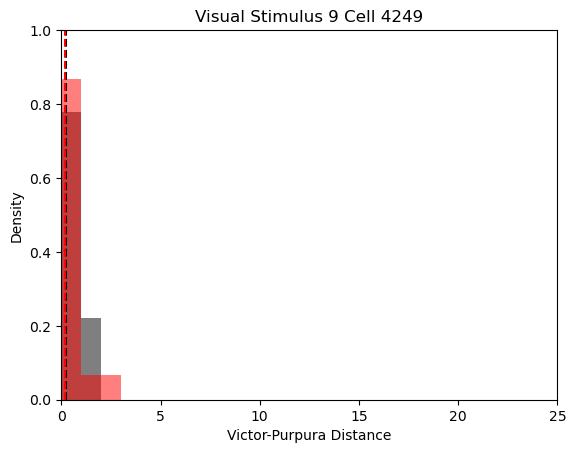

MannwhitneyuResult(statistic=62.5, pvalue=0.6935885501478424)


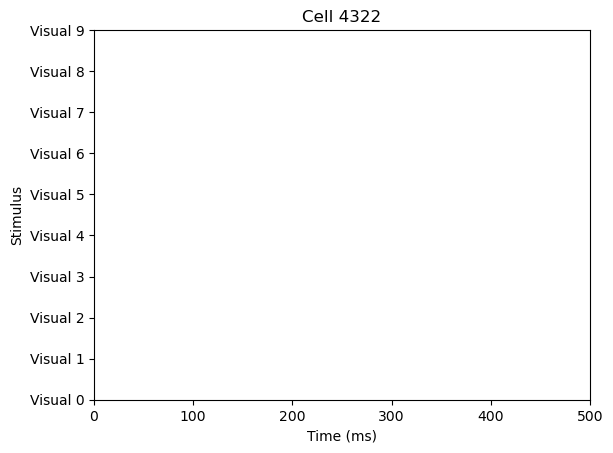

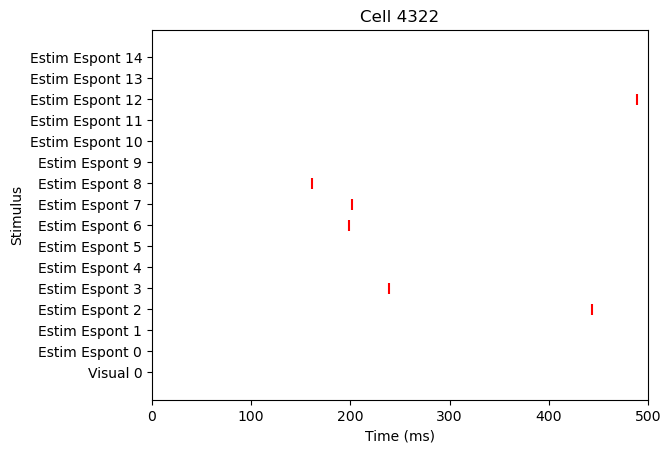

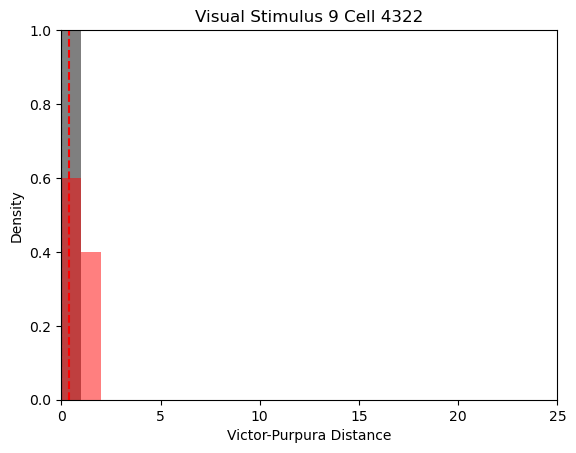

MannwhitneyuResult(statistic=94.5, pvalue=0.01764377121598736)


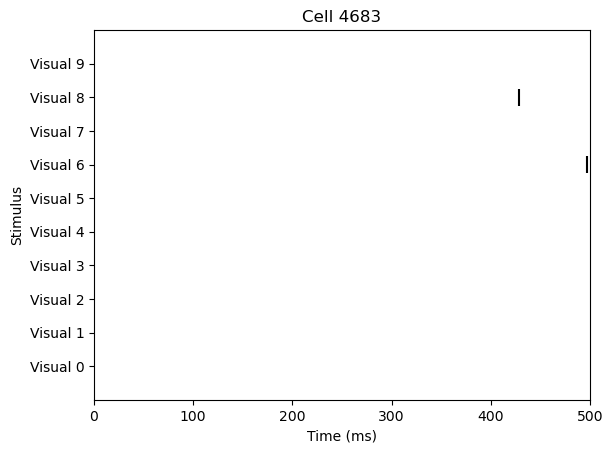

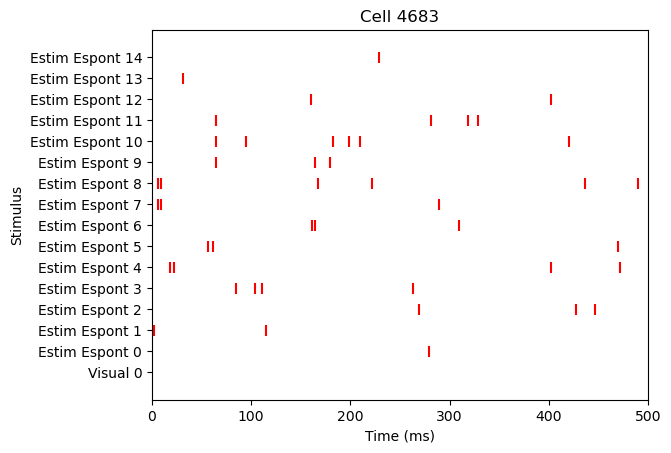

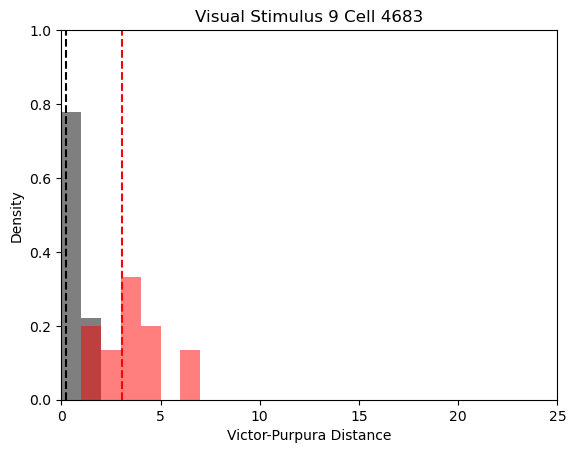

MannwhitneyuResult(statistic=132.0, pvalue=4.735366749833971e-05)


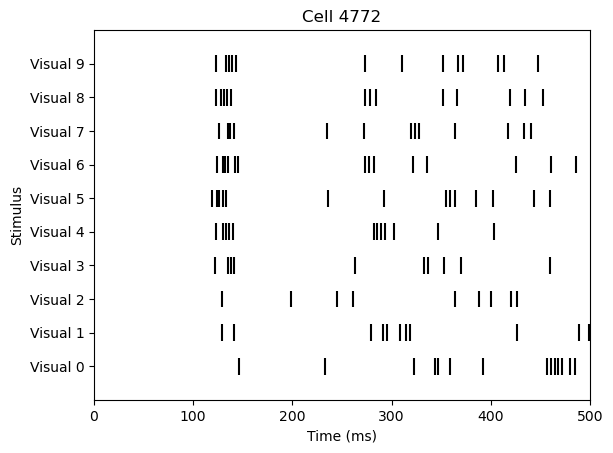

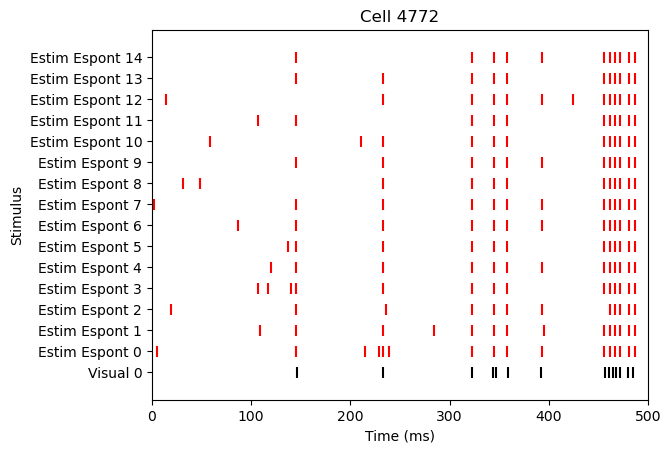

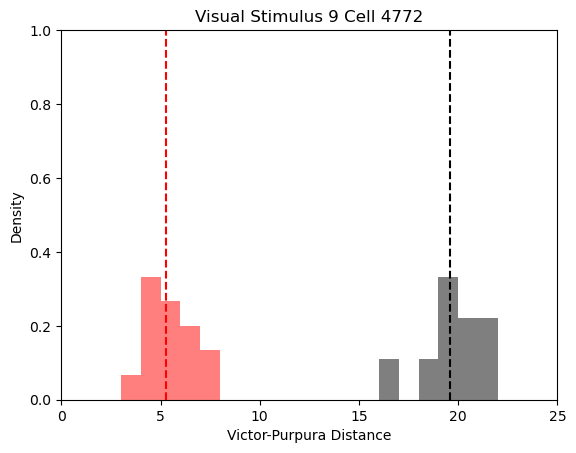

MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


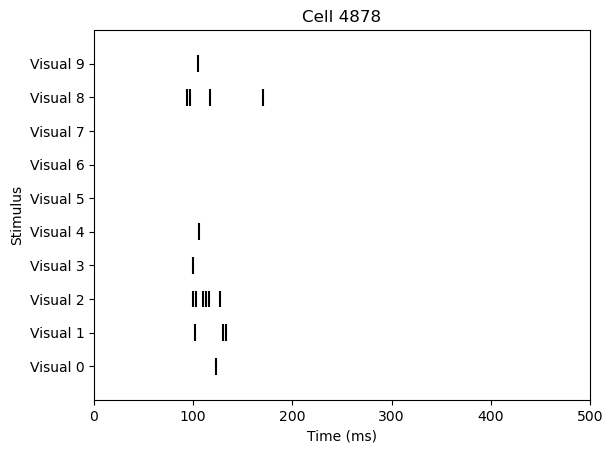

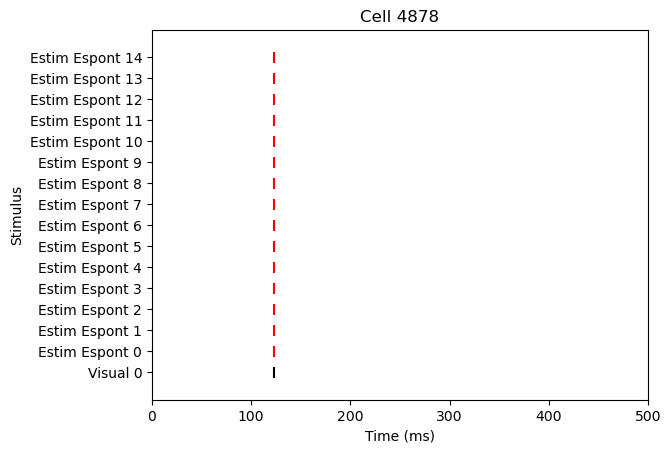

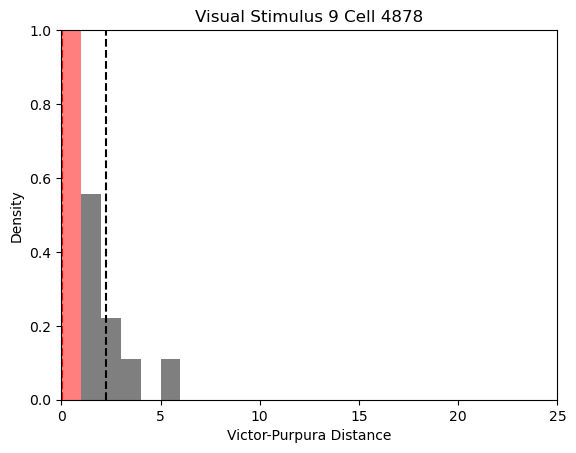

MannwhitneyuResult(statistic=0.0, pvalue=0.999998472963787)


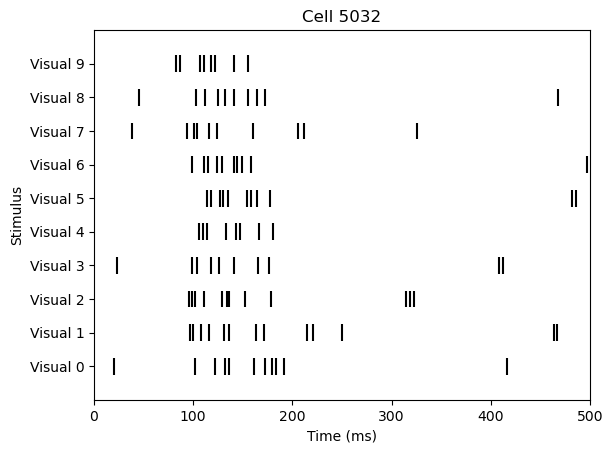

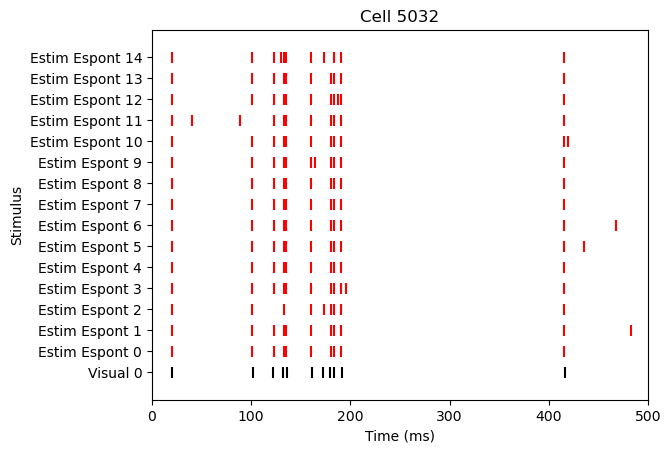

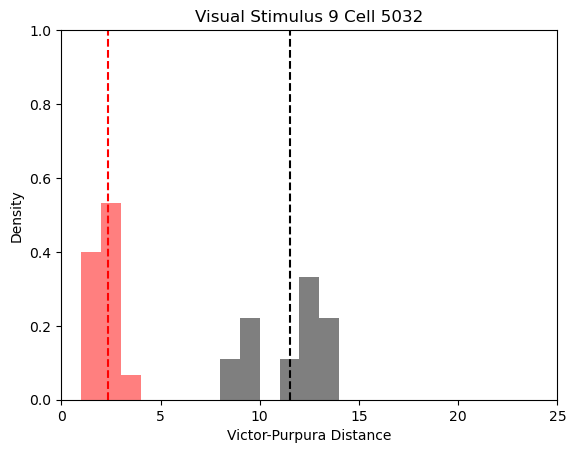

MannwhitneyuResult(statistic=0.0, pvalue=0.9999784742478998)


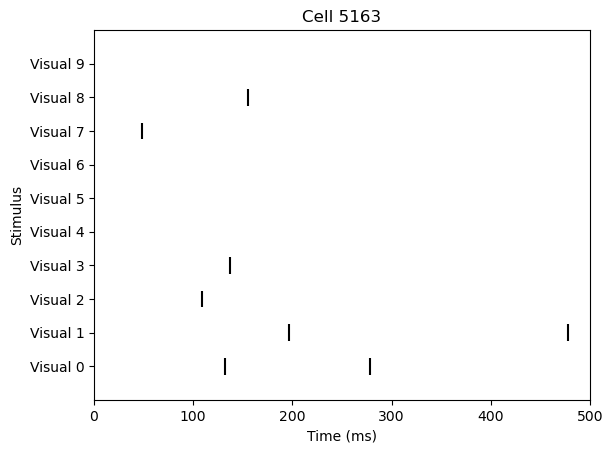

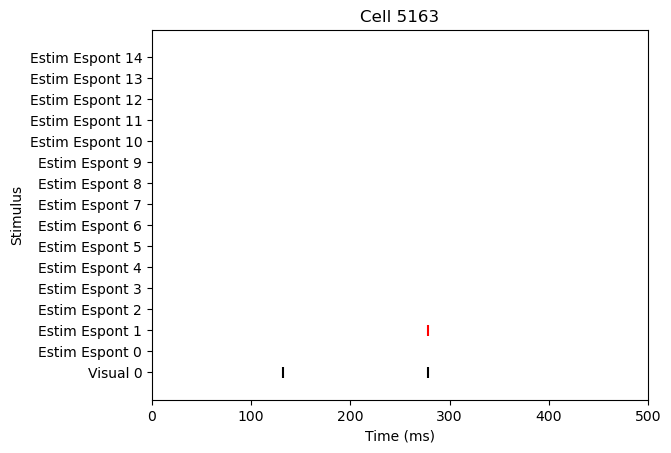

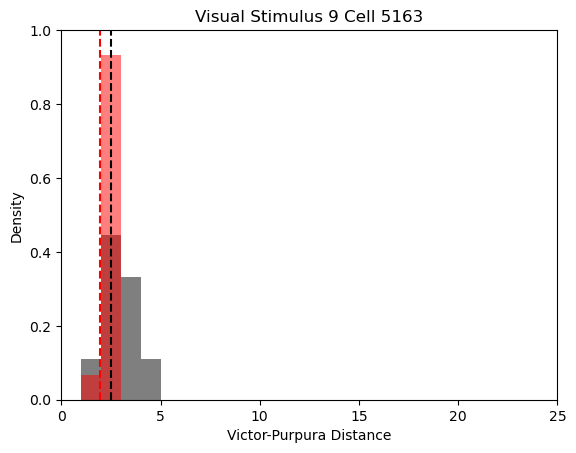

MannwhitneyuResult(statistic=42.0, pvalue=0.9793775138505744)


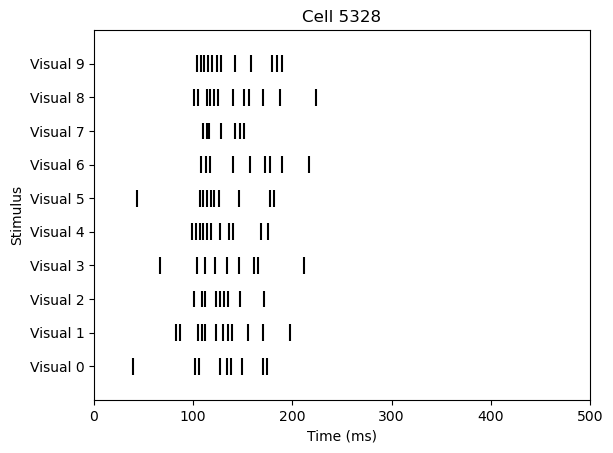

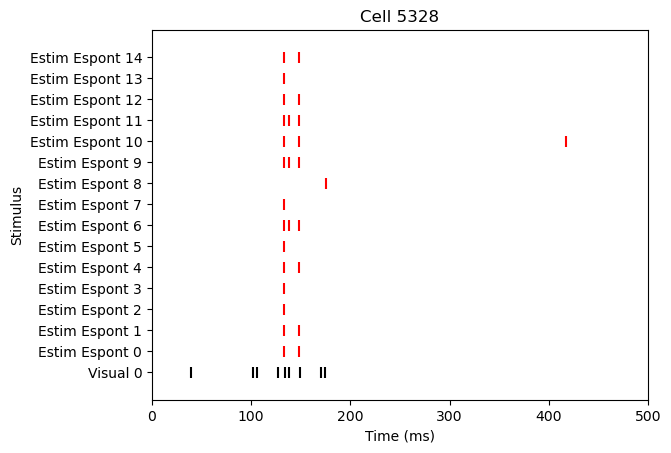

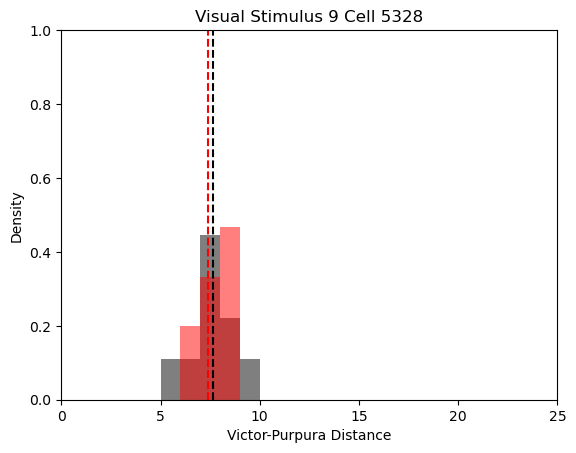

MannwhitneyuResult(statistic=55.0, pvalue=0.7830962969794459)


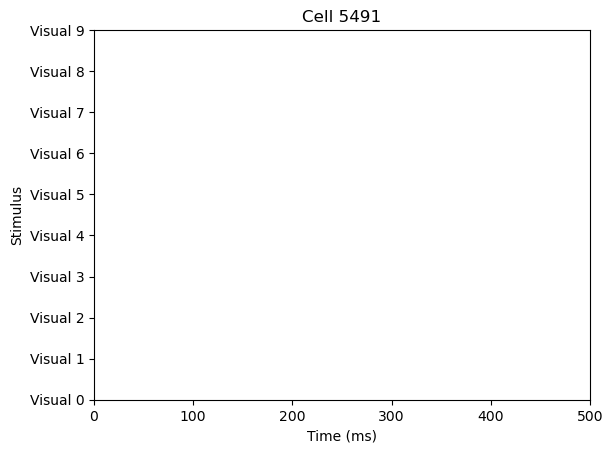

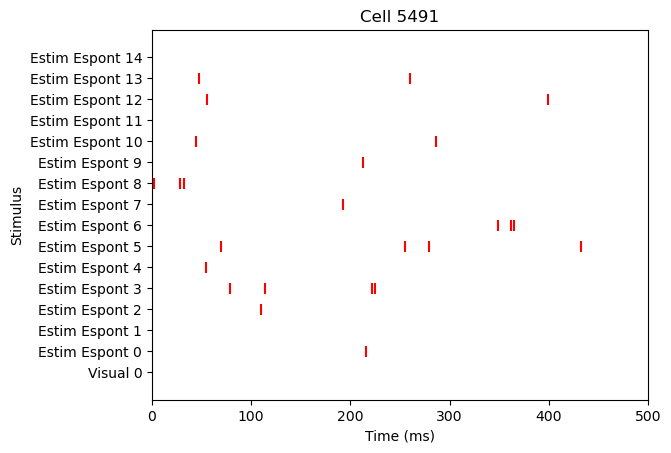

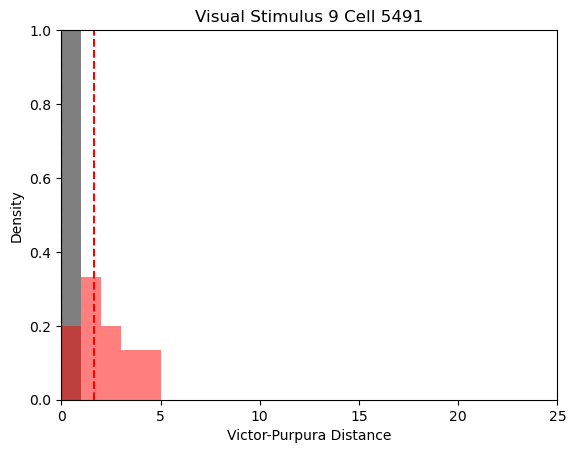

MannwhitneyuResult(statistic=121.5, pvalue=0.00030030810544229893)


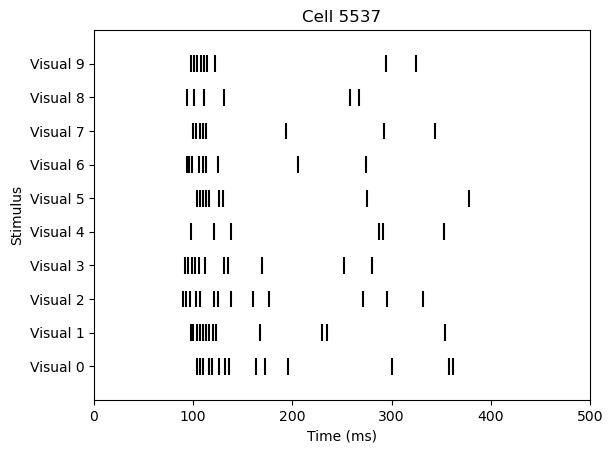

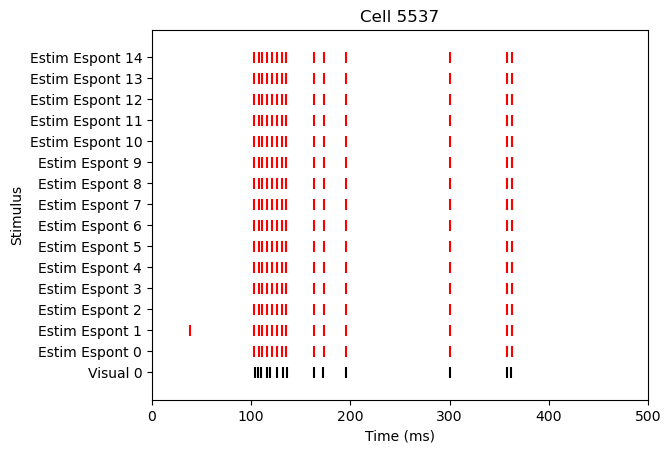

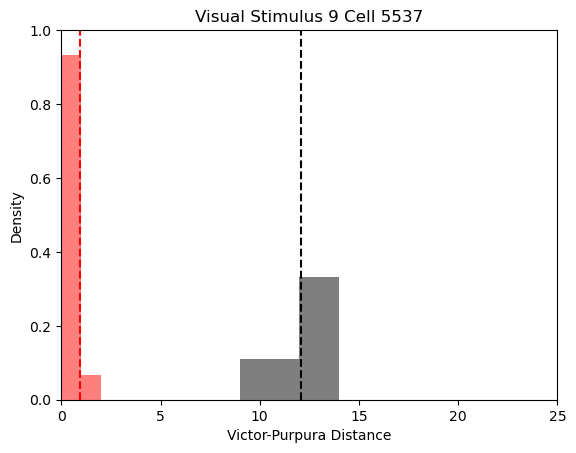

MannwhitneyuResult(statistic=0.0, pvalue=0.9999970112899595)


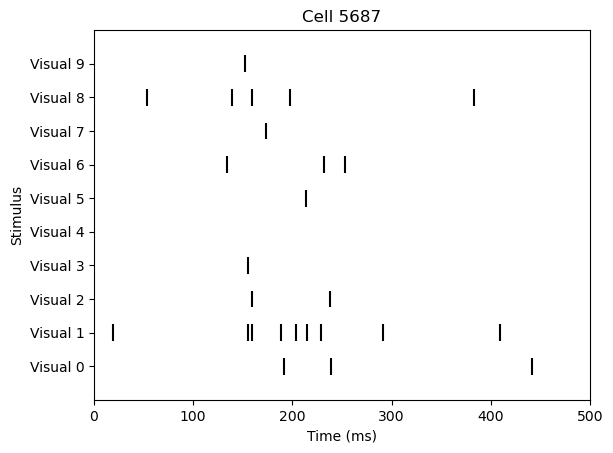

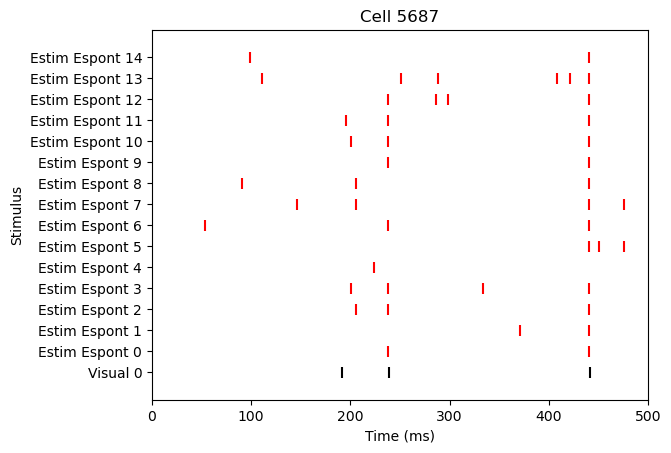

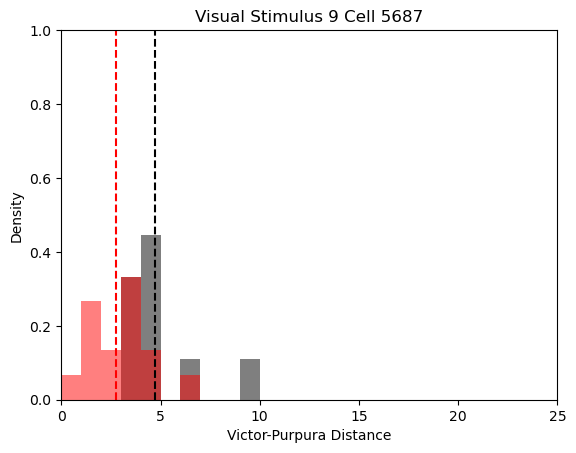

MannwhitneyuResult(statistic=27.0, pvalue=0.9928166743255123)


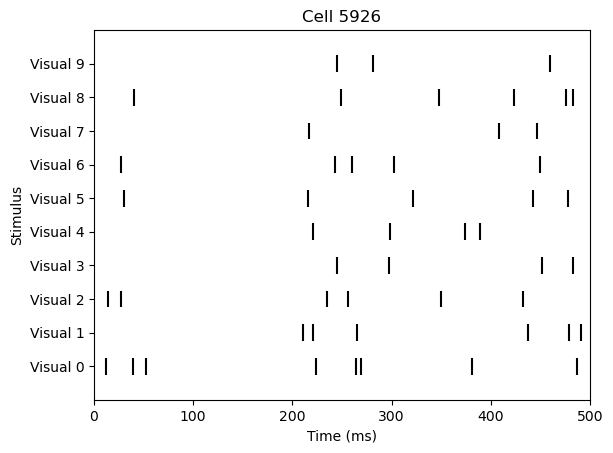

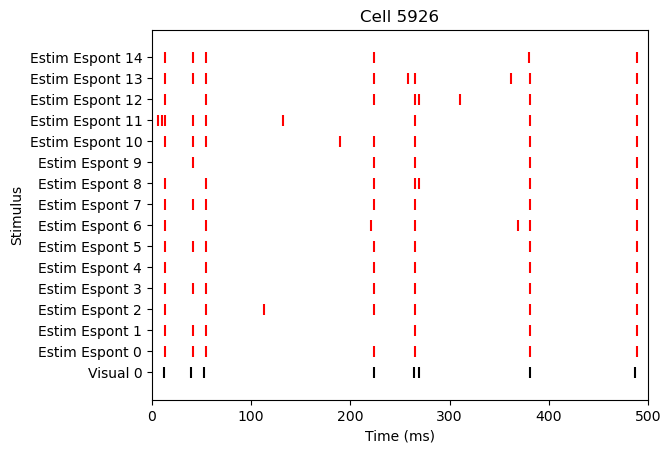

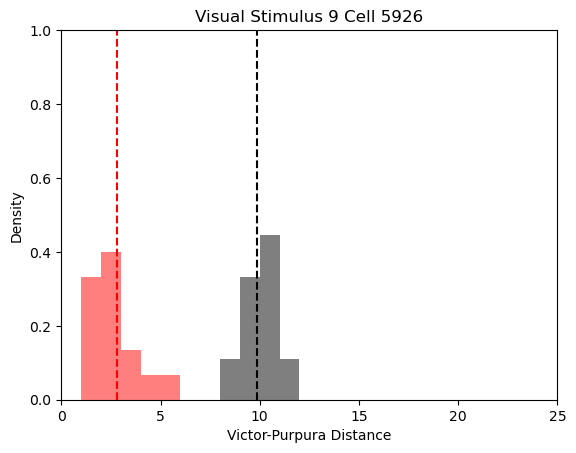

MannwhitneyuResult(statistic=0.0, pvalue=0.9999749990768718)


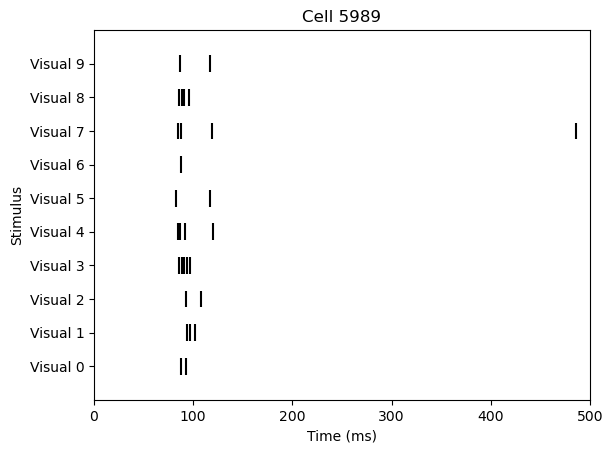

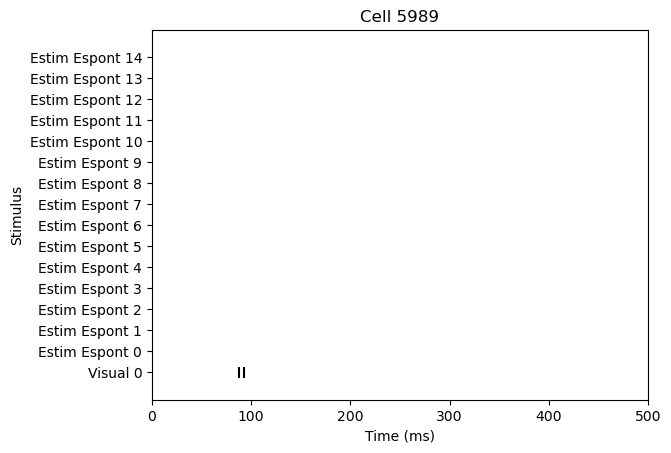

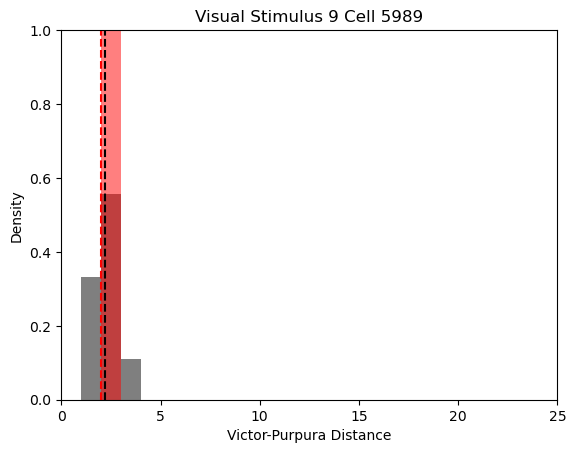

MannwhitneyuResult(statistic=45.0, pvalue=0.9425768228429664)


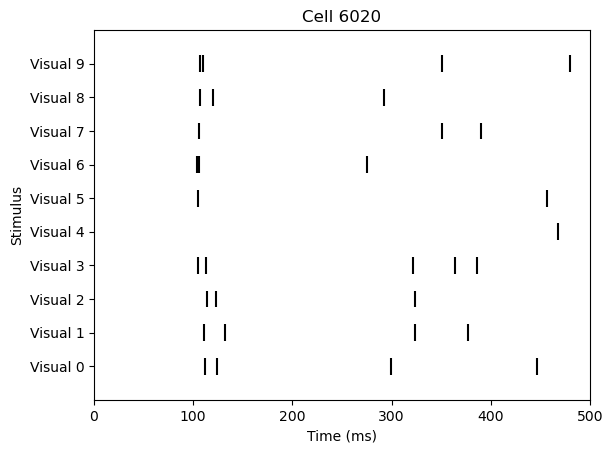

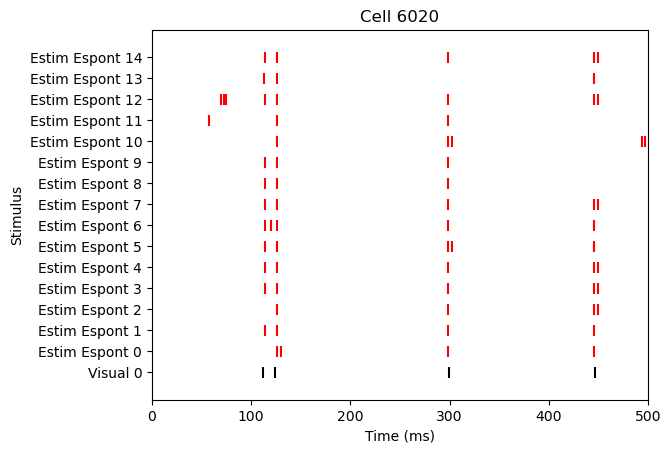

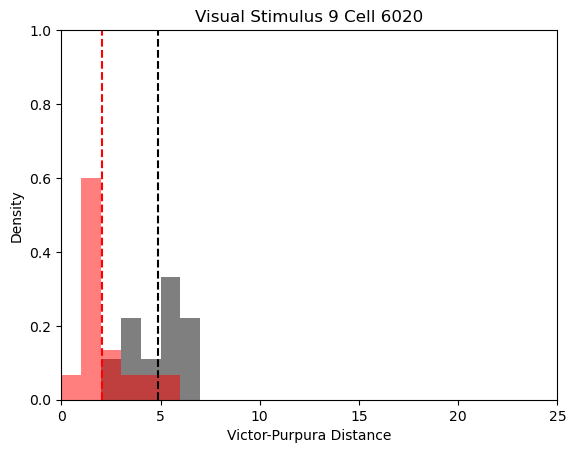

MannwhitneyuResult(statistic=9.0, pvalue=0.9997900848095738)


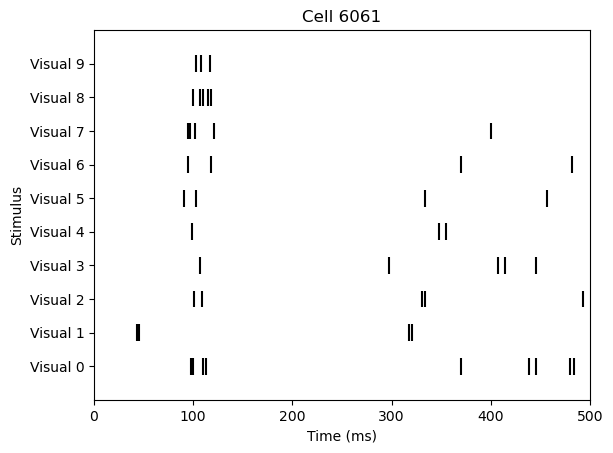

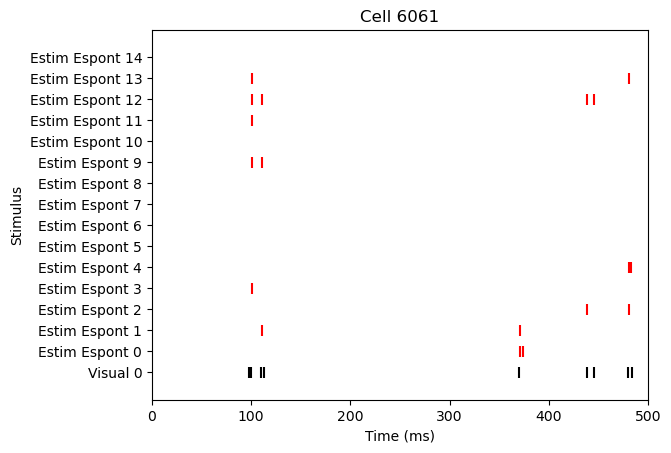

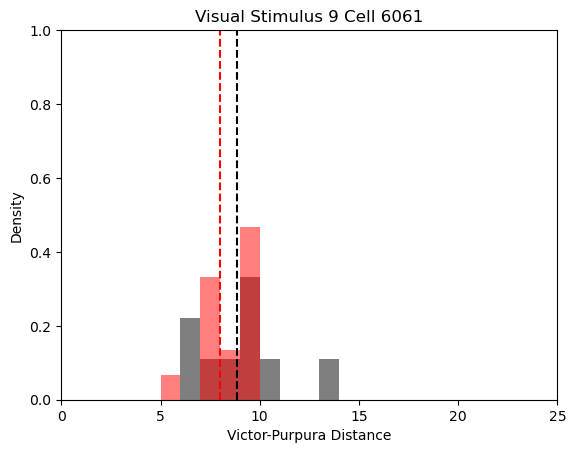

MannwhitneyuResult(statistic=44.0, pvalue=0.9254075446364904)


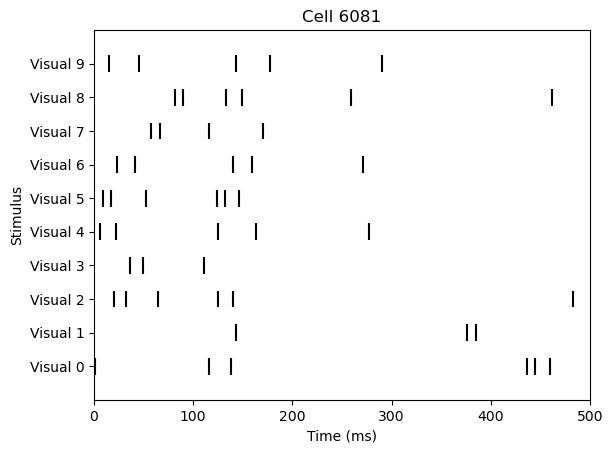

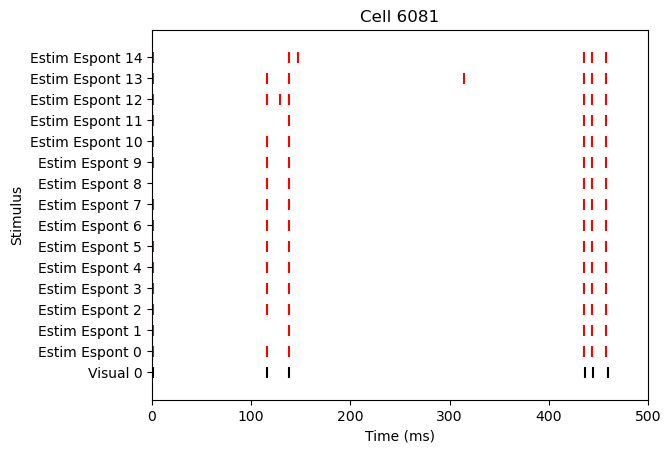

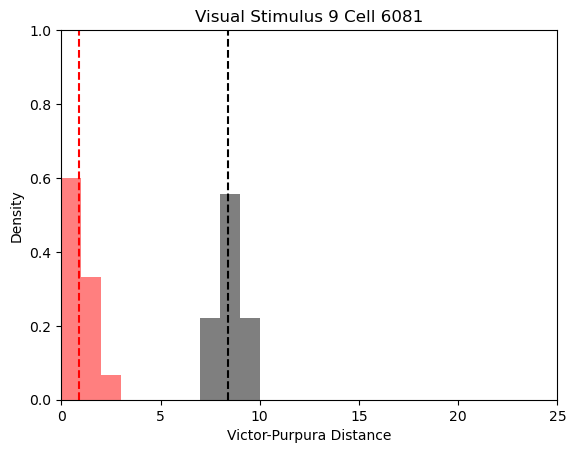

MannwhitneyuResult(statistic=0.0, pvalue=0.9999845514682187)


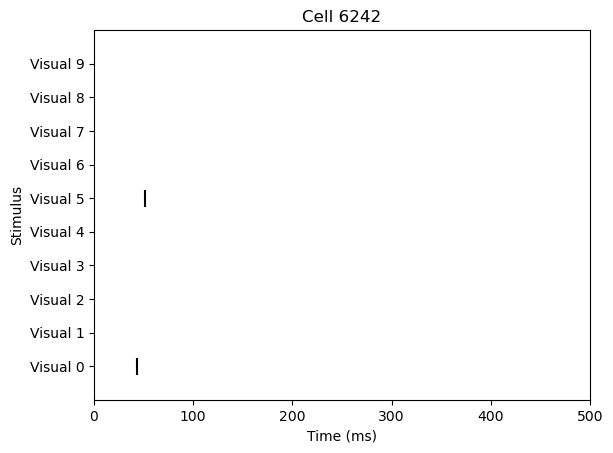

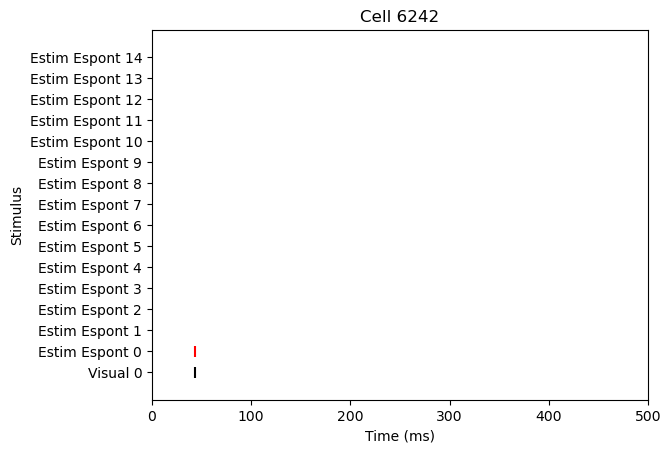

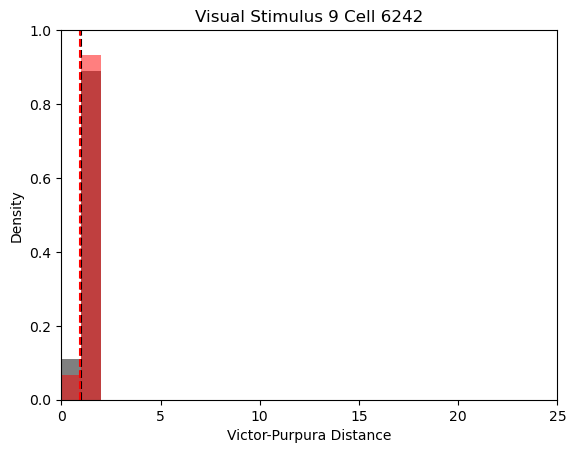

MannwhitneyuResult(statistic=70.0, pvalue=0.40180882163951726)


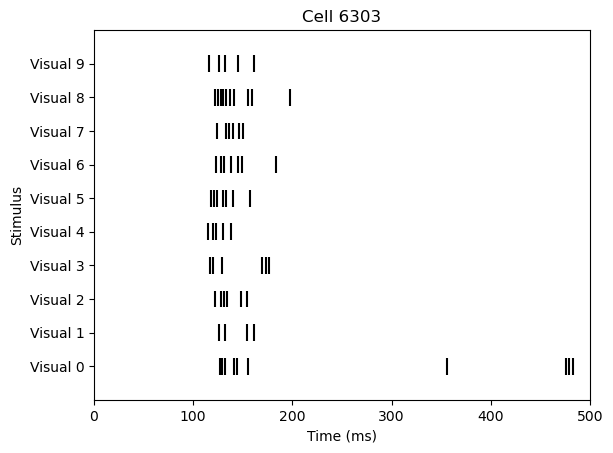

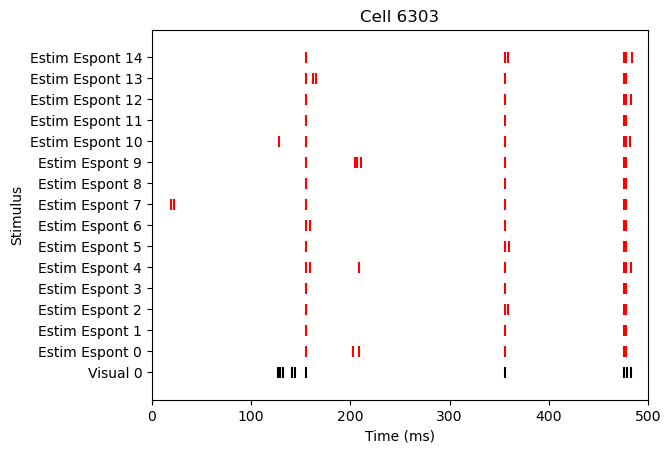

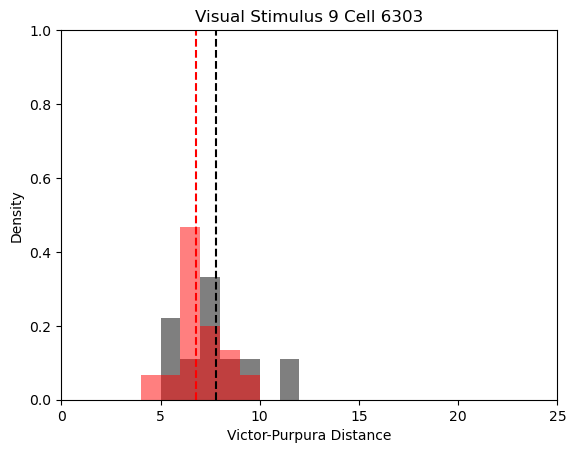

MannwhitneyuResult(statistic=50.0, pvalue=0.8590640042402755)


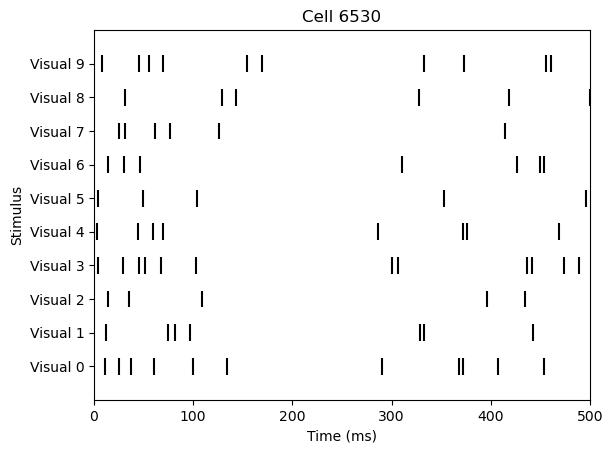

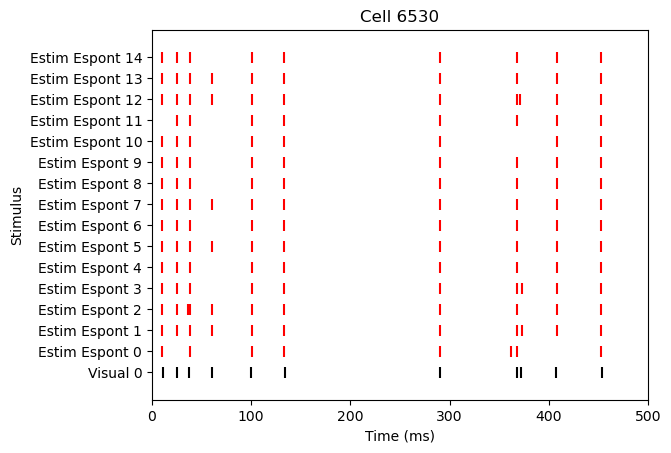

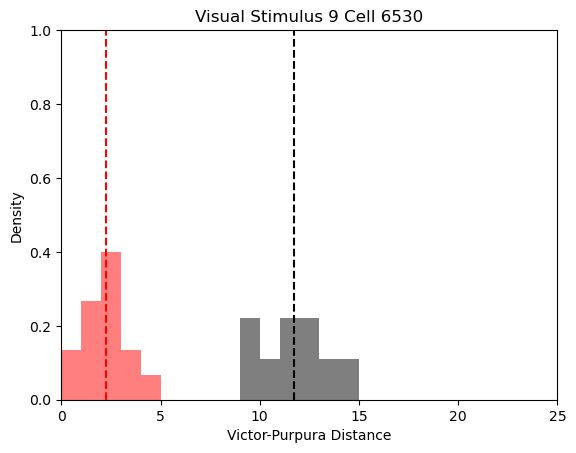

MannwhitneyuResult(statistic=0.0, pvalue=0.999977097275882)


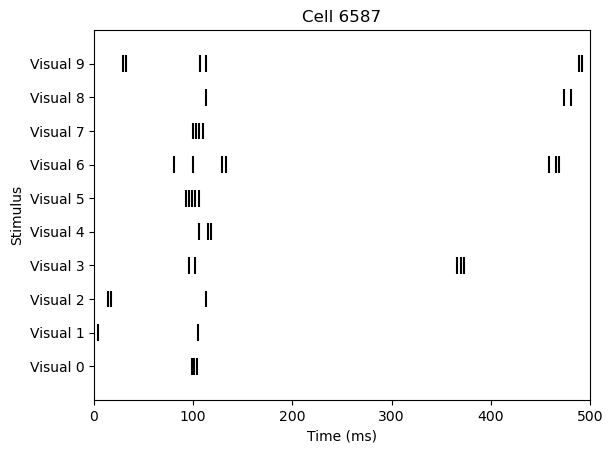

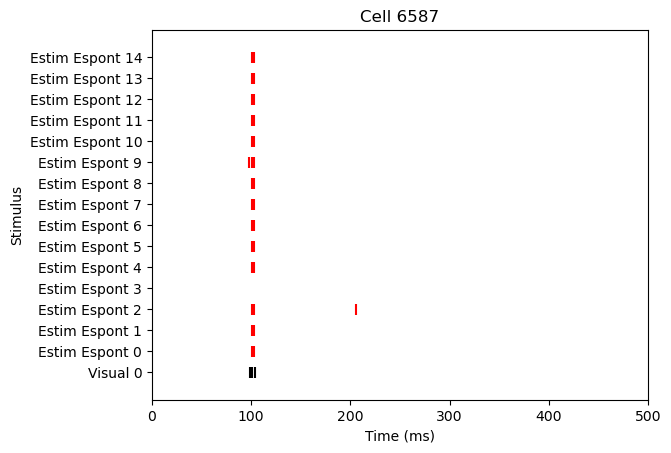

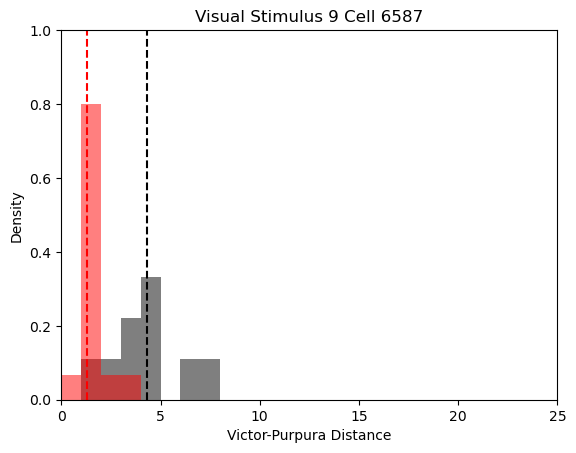

MannwhitneyuResult(statistic=3.0, pvalue=0.9999827791675633)


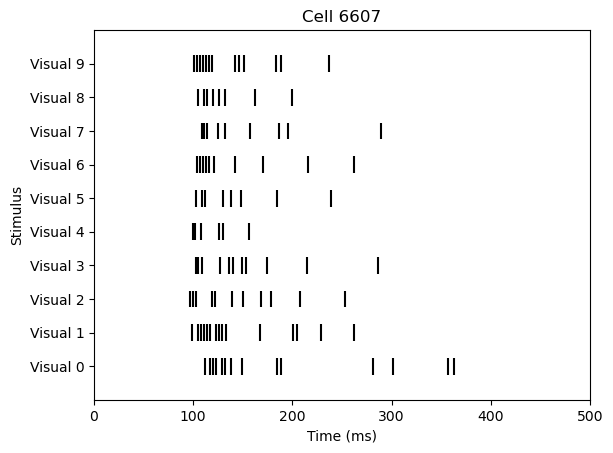

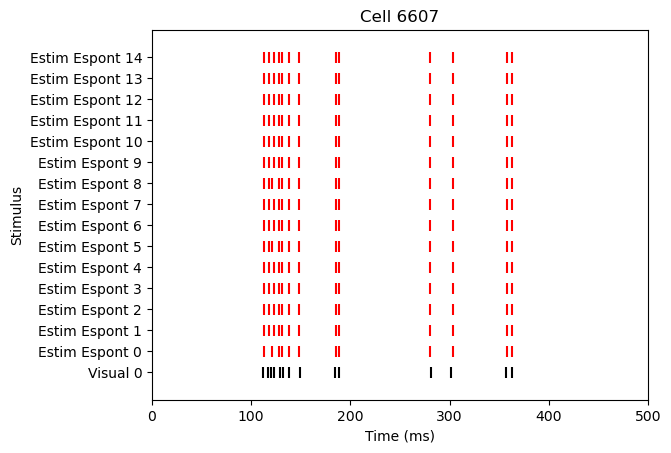

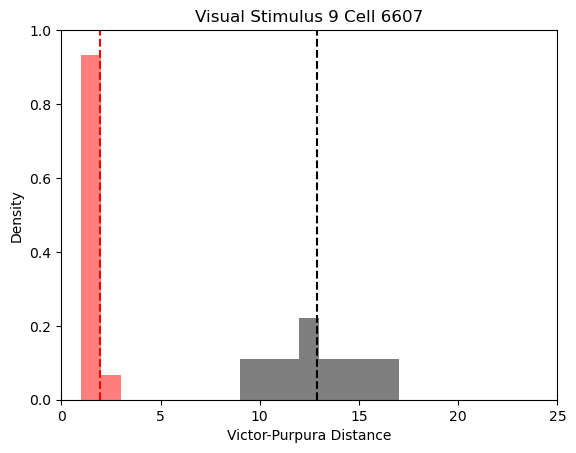

MannwhitneyuResult(statistic=0.0, pvalue=0.999992684026445)


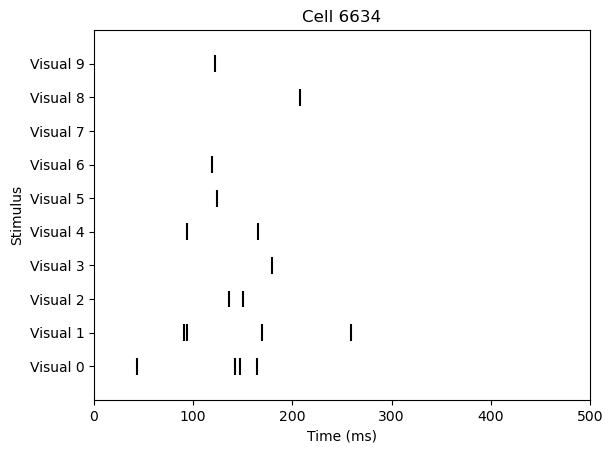

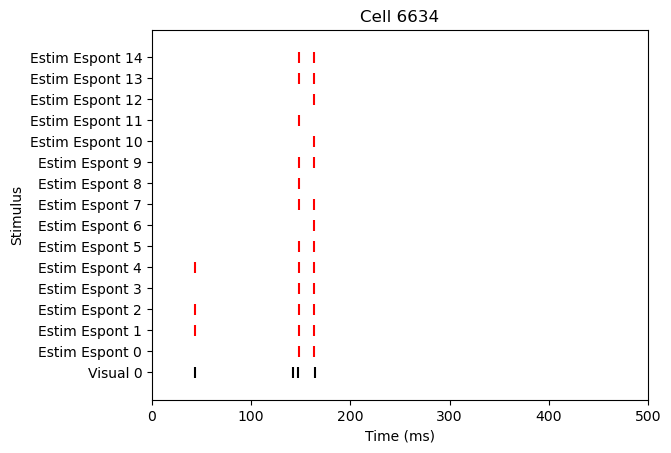

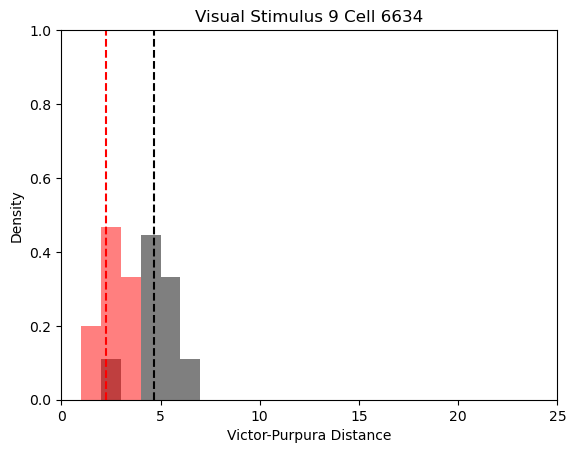

MannwhitneyuResult(statistic=5.0, pvalue=0.9999316996391479)


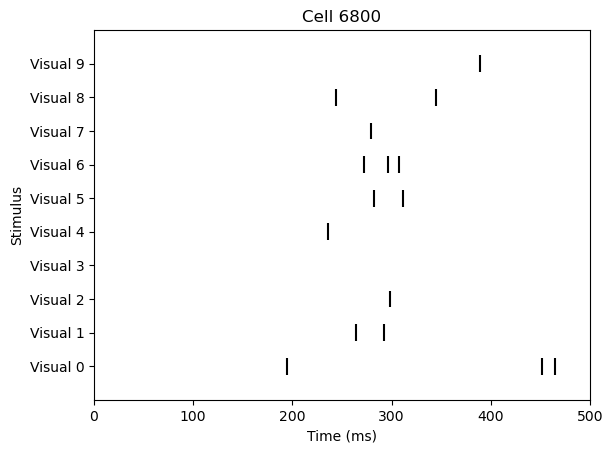

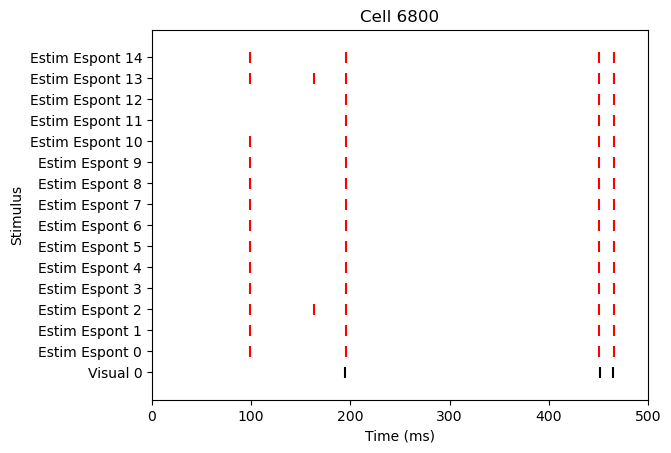

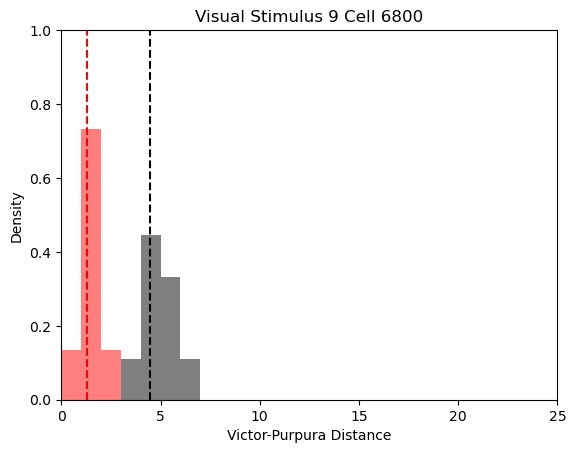

MannwhitneyuResult(statistic=0.0, pvalue=0.9999906668931656)


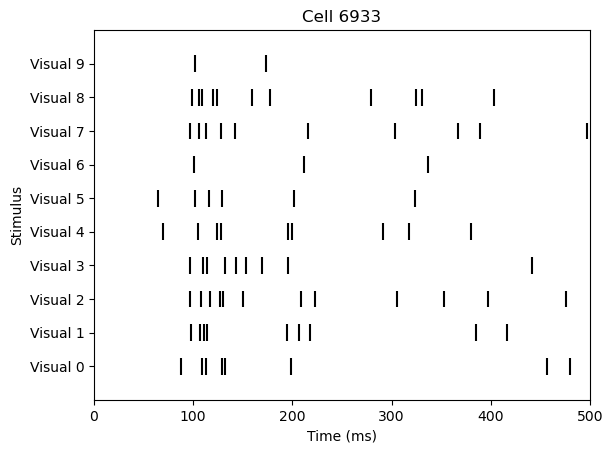

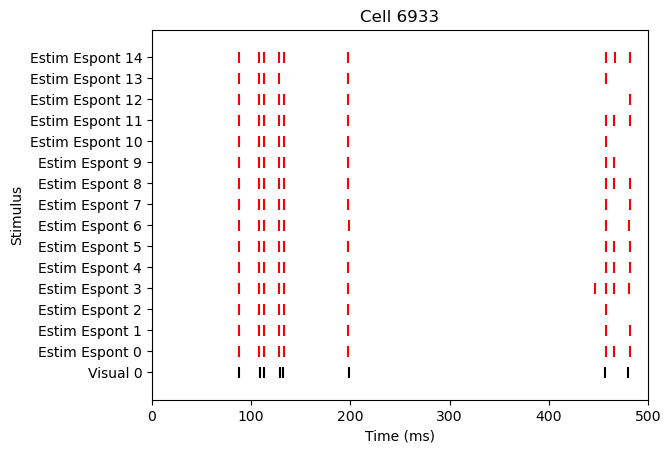

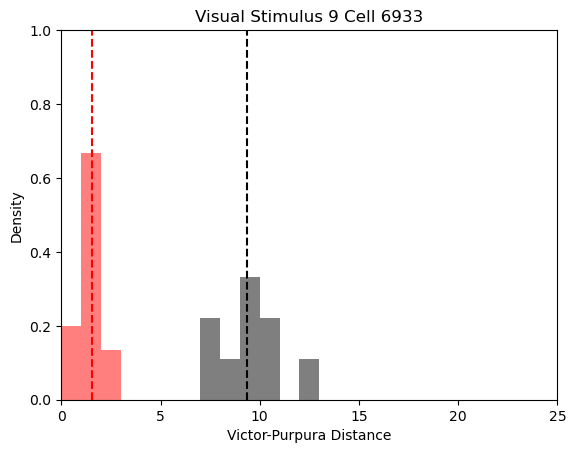

MannwhitneyuResult(statistic=0.0, pvalue=0.9999755602417462)


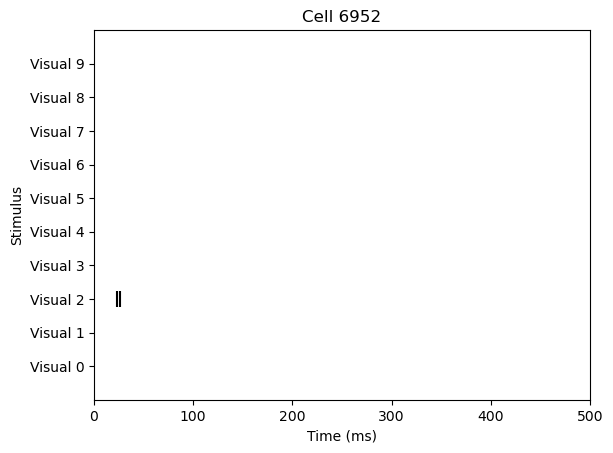

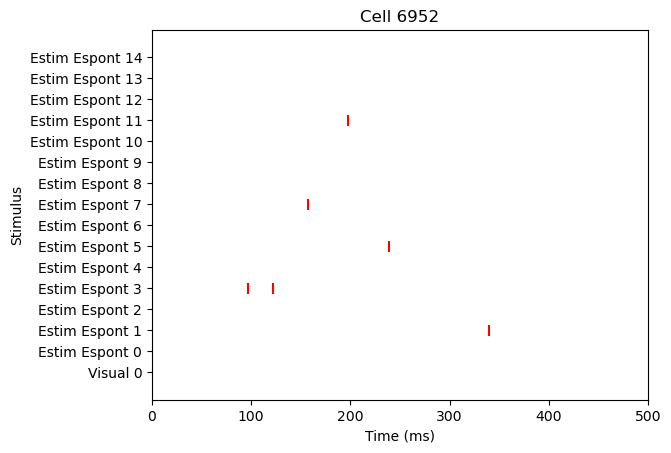

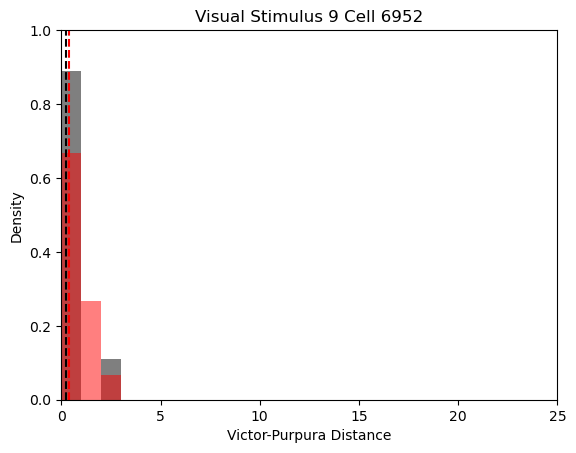

MannwhitneyuResult(statistic=80.5, pvalue=0.16258805720294467)


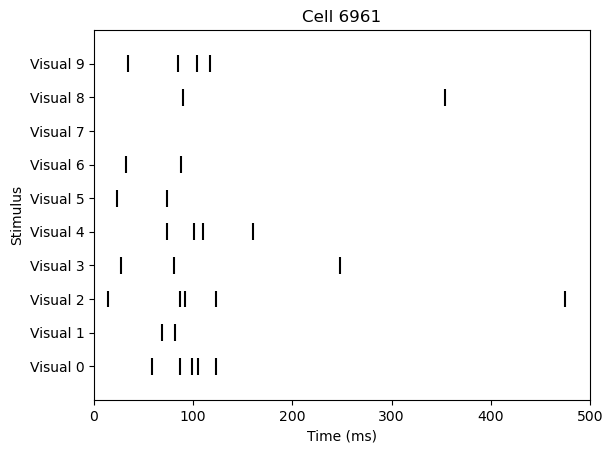

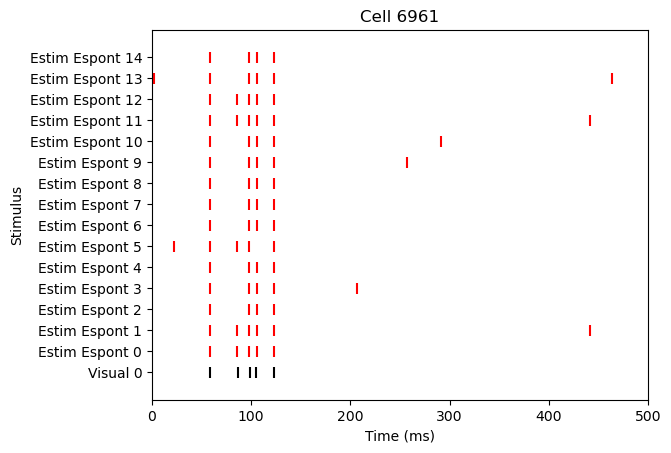

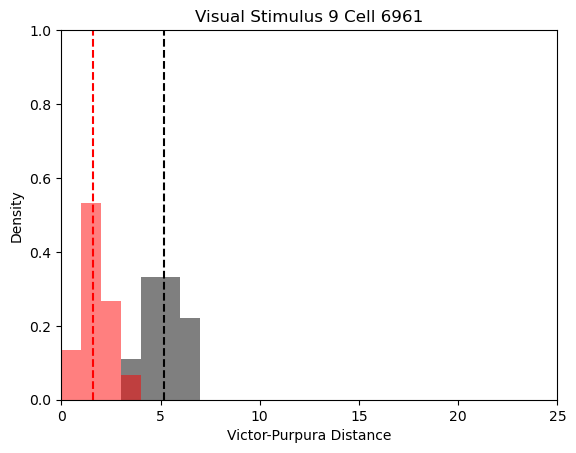

MannwhitneyuResult(statistic=0.0, pvalue=0.9999785581172097)


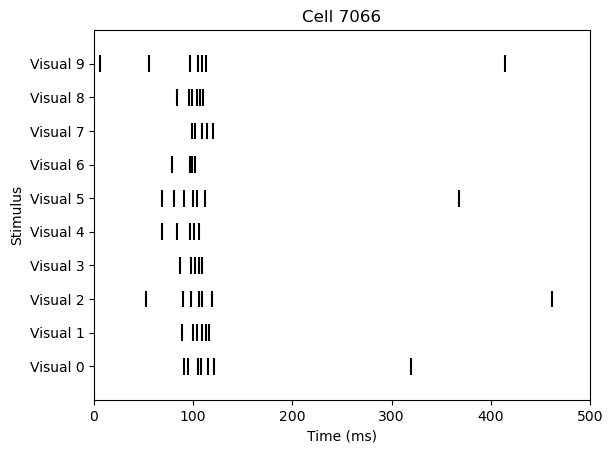

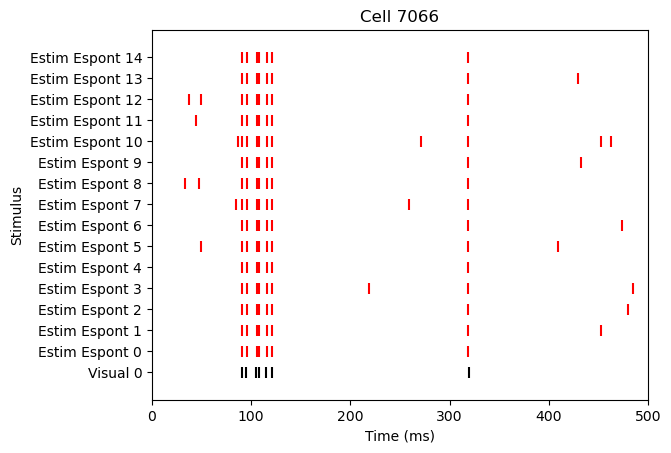

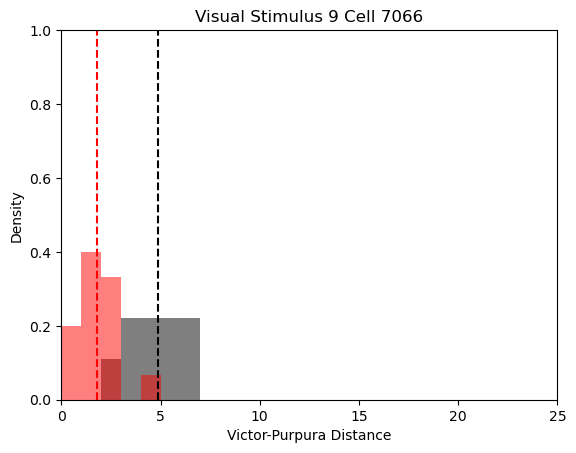

MannwhitneyuResult(statistic=3.0, pvalue=0.9999569118054928)


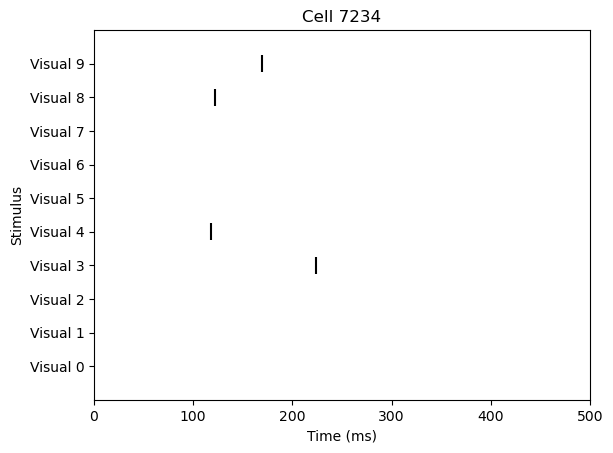

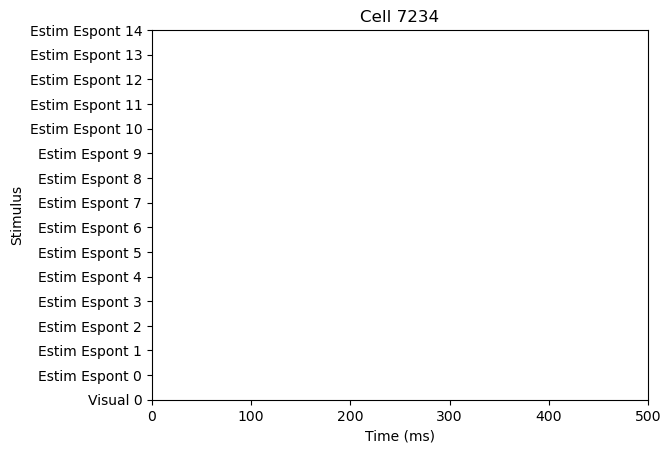

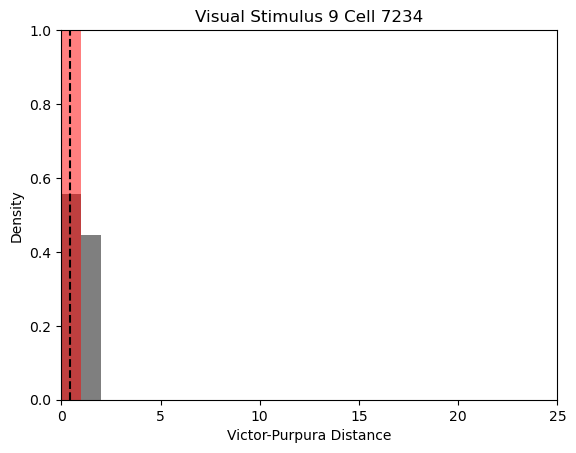

MannwhitneyuResult(statistic=37.5, pvalue=0.9975613092909055)


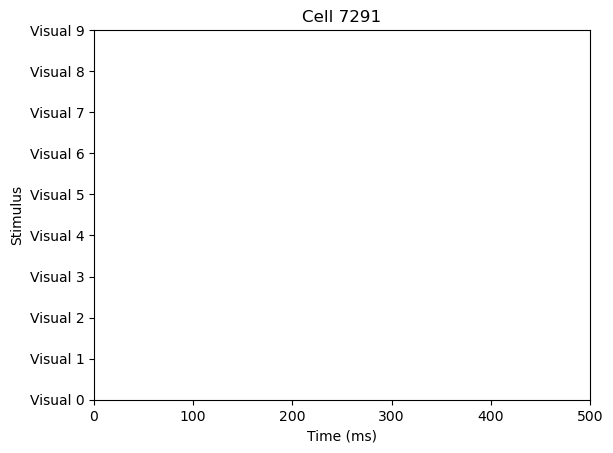

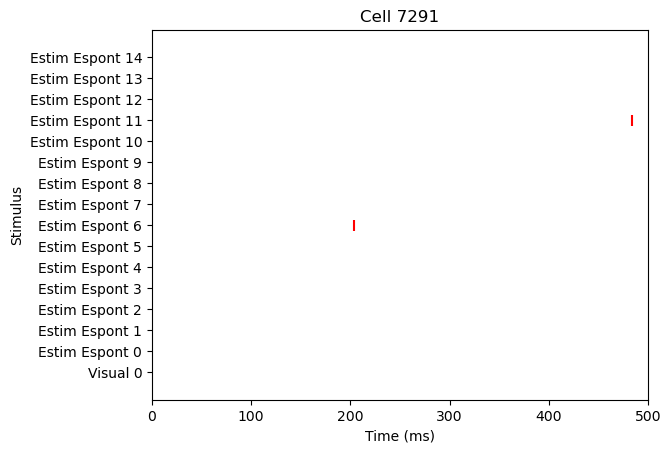

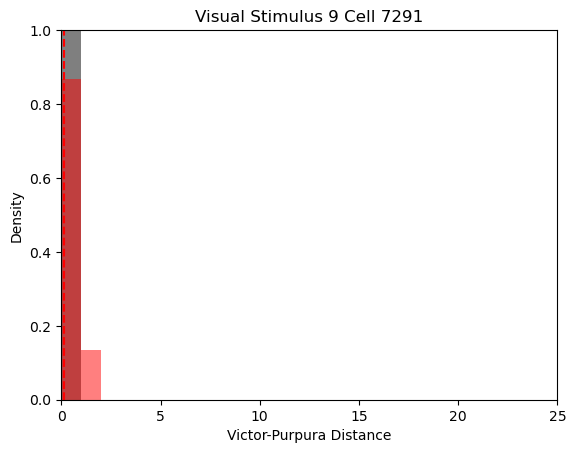

MannwhitneyuResult(statistic=76.5, pvalue=0.1450644009760519)


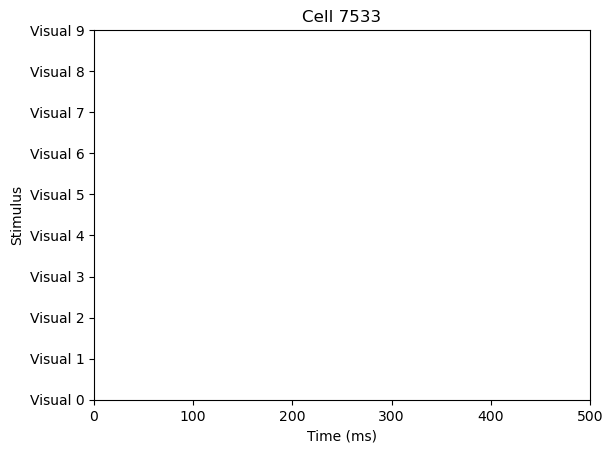

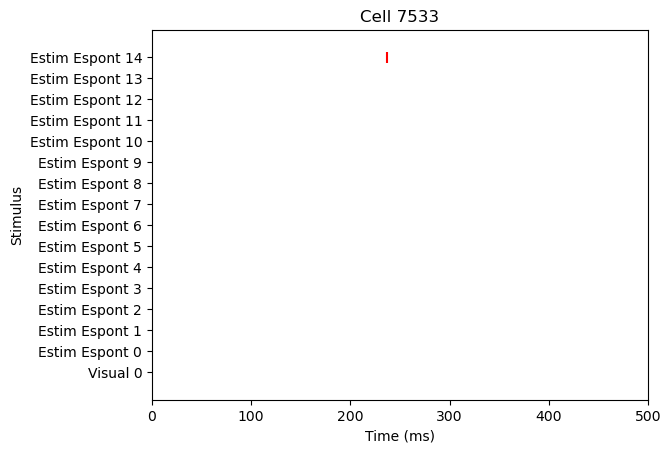

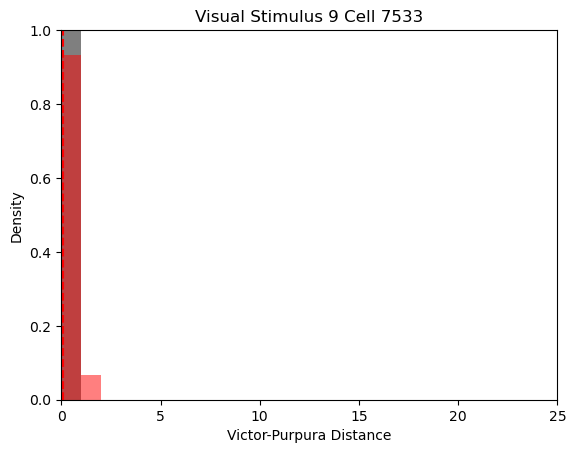

MannwhitneyuResult(statistic=72.0, pvalue=0.24555942524033636)


In [275]:
normalized_scores = []
alph = 0.05

for c in range(len(selective_cells_of_interest)):
    # Plot the visually evoked spike train and all of the electrically evoked spike trains on the same plot for cell c
    plt.figure()

    # Create a spike raster plot
    cell_responses = []
    for i in range(vstim_responses.shape[0]):
        cell_responses.append(vstim_responses[i,c])
    plt.eventplot(cell_responses, linelengths=0.5, colors='k')

    # Set the y-axis ticks and labels
    plt.yticks(range(vstim_responses.shape[0]), [f'Visual {i}' for i in range(vstim_responses.shape[0])])
    plt.ylabel('Stimulus')

    # Set the x-axis label
    plt.xlabel('Time (ms)')
    plt.xlim(0, 500)

    # Set the plot title
    plt.title(f"Cell {selective_cells_of_interest[c]}")

    # Show the plot
    plt.show()


    # Plot the visually evoked spike train and all of the electrically evoked spike trains on the same plot for cell c
    plt.figure()

    # Create a spike raster plot
    cell_responses = []
    cell_responses.append(vstim_responses[0,c])
    for i in range(estim_espont_responses.shape[0]):
        cell_responses.append(estim_espont_responses[i,c])
    plt.eventplot(cell_responses, linelengths=0.5, colors=['k'] + ['red']*estim_espont_responses.shape[0])

    # Set the y-axis ticks and labels
    plt.yticks(range(estim_espont_responses.shape[0]+1), ['Visual 0'] + [f'Estim Espont {i}' for i in range(estim_espont_responses.shape[0])])
    plt.ylabel('Stimulus')

    # Set the x-axis label
    plt.xlabel('Time (ms)')
    plt.xlim(0, 500)

    # Set the plot title
    plt.title(f"Cell {selective_cells_of_interest[c]}")

    # Show the plot
    plt.show()


    # vstim_vp = vstim_vp_distance[c][np.triu_indices(vstim_vp_distance.shape[1],1)].flatten()
    vstim_vp = vstim_vp_distance[c,0,1:]
    estim_espont_vp = estim_espont_vp_distance[c,0,1:]

    # if np.all(vstim_vp == 0):
    #     warnings.warn(f"Cell {selective_cells_of_interest[c]} has all 0 Victor-Purpura distances for visual trials")
    #     normalized_scores.append(None)
    # else:
    plt.figure()

    # plot Victor-Purpura pairwise distance for visual trials
    plt.hist(vstim_vp, bins=np.arange(100), density=True, color='k', alpha=0.5)
    x = np.arange(0,100,0.01)

    # plot average Victor-Purpura pairwise distance for target visual trial
    vstim_vp_target = vstim_vp_distance[c,0,1:]
    plt.axvline(np.mean(vstim_vp_target), color='k', linestyle='--')

    # # Normal distribution fitting
    # plt.plot(x, norm.pdf(x, np.mean(vstim_vp), np.std(vstim_vp)), color='r')

    # # plot 2 std dev lines
    # plt.axvline(np.mean(vstim_vp) - 2*np.std(vstim_vp), color='r', linestyle='--')
    # plt.axvline(np.mean(vstim_vp) + 2*np.std(vstim_vp), color='r', linestyle='--')

    # normalized_scores.append((np.mean(estim_espont_vp) - np.mean(vstim_vp)) / np.std(vstim_vp)) # z-score


    # Chi-square distribution fitting
    # fit_params = chi2.fit(vstim_vp, floc=0, fscale=1)
    # df_fit, loc_fit, scale_fit = fit_params
    # print("Degrees of Freedom (df):", df_fit)
    # print("Location (loc):", loc_fit)
    # print("Scale (scale):", scale_fit)

    # # plot the chi-square fit
    # y = chi2.pdf(x, df_fit, loc_fit, scale_fit)
    # plt.plot(x, y, 'pink', label='Chi-square Fit')

    # # Plot the chi-square critical value for significance level 0.05
    # chi2_critical = chi2.ppf(1-alph, df_fit, loc_fit, scale_fit)
    # plt.axvline(chi2_critical, color='pink', linestyle='--', label='Chi-square Critical Value')

    # normalized_scores.append(chi2.cdf(np.mean(estim_espont_vp), df_fit, loc_fit, scale_fit)) # p-value

    # plot Victor-Purpura distance for selected visual trial to estim espont trials
    plt.hist(estim_espont_vp, bins=np.arange(25), density=True, color='red', alpha=0.5)

    # plot average
    plt.axvline(np.mean(estim_espont_vp), color='red', linestyle='--')

    plt.title(f"Visual Stimulus {frame_no} Cell {selective_cells_of_interest[c]}")
    plt.xlabel("Victor-Purpura Distance")
    plt.ylabel("Density")
    plt.xlim(0,25)
    plt.ylim(0,1)
    plt.show()

    # ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
    # print(ttest)
    # normalized_scores.append(ttest[1]) # p-value

    mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
    print(mannwhitney)
    normalized_scores.append(mannwhitney[1]) # p-value
    

normalized_scores = np.array(normalized_scores)

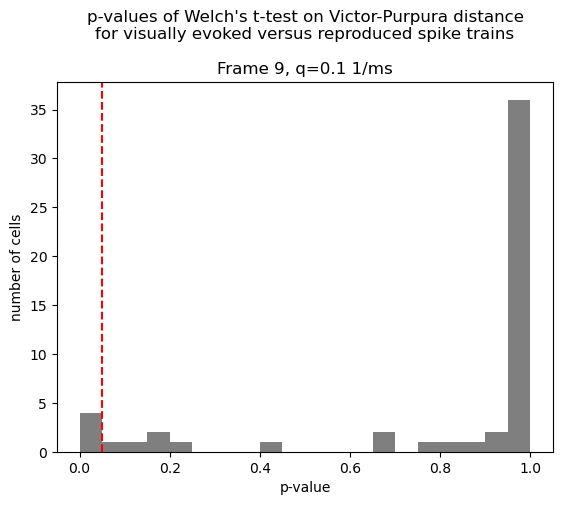

In [276]:
plt.figure()
plt.hist(normalized_scores, bins=np.arange(0,1.05,0.05), density=False, color='k', alpha=0.5)
plt.axvline(alph, color='r', linestyle='--')
plt.xlabel("p-value")
plt.ylabel("number of cells")
plt.title(f"p-values of Welch's t-test on Victor-Purpura distance\nfor visually evoked versus reproduced spike trains\n\nFrame {frame_no}, q={q}")
plt.show()

In [277]:
print(vstim_responses.shape)
print(estim_espont_responses.shape)

(10, 53)
(15, 53)


[319.33  285.205 306.275 288.905 289.985 287.49  272.145 295.77  281.505]
[ 95.295  90.82   97.6   105.14   86.425  97.45   99.895  97.585 103.785
  91.055 109.705 108.25   91.315 105.755  88.185]


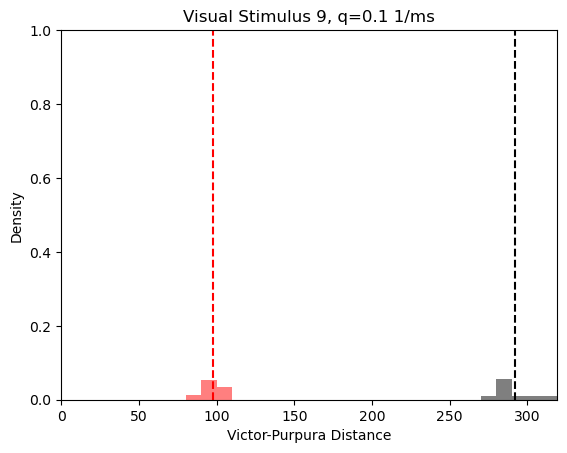

MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


In [278]:
alph = 0.05

if False:
    for i in range(vstim_responses.shape[0]):

        plt.figure()

        # Create a spike raster plot
        plt.eventplot(vstim_responses[i], linelengths=0.5, colors='black')

        # Set the y-axis ticks and labels
        plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
        plt.ylabel('Cell ID')

        # Set the x-axis label
        plt.xlabel('Time (ms)')

        # Set the plot title
        plt.title(f"Visual {i}")

        # Restrict the x axis
        plt.xlim(0, 500)

        # Close the plot
        plt.show()

    for i in range(estim_espont_responses.shape[0]):

        plt.figure()

        # Make two lineoffsets vectors offset by a constant value
        lineoffsets1 = np.arange(len(selective_cells_of_interest))
        lineoffsets2 = np.arange(len(selective_cells_of_interest)) - 0.5

        # Create a spike raster plot
        plt.eventplot(vstim_responses[0], linelengths=0.5, lineoffsets=lineoffsets1, colors='black')
        plt.eventplot(estim_espont_responses[i], linelengths=0.5, lineoffsets=lineoffsets2, colors='red')

        # Set the y-axis ticks and labels
        plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
        plt.ylabel('Cell ID')

        # Set the x-axis label
        plt.xlabel('Time (ms)')

        # Set the plot title
        plt.title(f"Electrical {i}")

        # Restrict the x axis
        plt.xlim(0, 500)

        # Close the plot
        plt.show()


vstim_vp = np.sum(vstim_vp_distance[:,0,1:], axis=0)
estim_espont_vp = np.sum(estim_espont_vp_distance[:,0,1:], axis=0)

print(vstim_vp)
print(estim_espont_vp)

plt.figure()

# plot Victor-Purpura pairwise distance for visual trials
max_dist = np.max(np.concatenate((vstim_vp,estim_espont_vp)))
x = np.arange(0,max_dist+10,10)
plt.hist(vstim_vp, bins=x, density=True, color='k', alpha=0.5)

# plot average Victor-Purpura pairwise distance for target visual trial
vstim_vp_target = np.sum(vstim_vp_distance[:,0,1:], axis=0)
plt.axvline(np.mean(vstim_vp_target), color='k', linestyle='--')

# plot Victor-Purpura distance for selected visual trial to estim espont trials
plt.hist(estim_espont_vp, bins=x, density=True, color='red', alpha=0.5)

# plot average
plt.axvline(np.mean(estim_espont_vp), color='red', linestyle='--')

plt.title(f"Visual Stimulus {frame_no}, q={q}")
plt.xlabel("Victor-Purpura Distance")
plt.ylabel("Density")
plt.xlim(0,max_dist)
plt.ylim(0,1)
plt.show()

# ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
# print(ttest)

mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
print(mannwhitney)


In [279]:
frame_nos = np.arange(5,24)
q_list = [np.inf / (1. * ms), 1. / (1. * ms), 1. / (10. * ms), 1. / (100. * ms), 0. / (1. * ms)]

mannwhitney_p_values = np.empty((len(frame_nos), len(q_list), len(selective_cells_of_interest)))

for frame_no in tqdm(frame_nos):

    vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
    estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

    vstim_spike_trains = np.empty((vstim_responses.shape[0], vstim_responses.shape[1]), dtype=object)
    for i in range(vstim_responses.shape[0]):
        for j in range(vstim_responses.shape[1]):
            vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i,j]*ms, t_start=-5.0*ms, t_stop=505.0*ms)

    estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], estim_espont_responses.shape[1]), dtype=object)
    for i in range(estim_espont_responses.shape[0]):
        for j in range(estim_espont_responses.shape[1]):
            estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i,j]*ms, t_start=-5.0*ms, t_stop=505.0*ms)

    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0, 1, len(q_list)))

    for k,q in enumerate(q_list):

        vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
        for i in range(vstim_spike_trains.shape[1]):

            spike_train_list = []
            for j in range(vstim_spike_trains.shape[0]):
                spike_train_list.append(vstim_spike_trains[j,i])

            vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

        estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
        for i in range(estim_espont_spike_trains.shape[1]):

            spike_train_list = []
            spike_train_list.append(vstim_spike_trains[vstim_trial,i])
            for j in range(estim_espont_spike_trains.shape[0]):
                spike_train_list.append(estim_espont_spike_trains[j,i])

            estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)


        for c in range(len(selective_cells_of_interest)):
            vstim_vp = vstim_vp_distance[c,0,1:]
            estim_espont_vp = estim_espont_vp_distance[c,0,1:]

            # ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
            # ttest_p_values[frame_no-5,k,c] = ttest[1]

            mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
            mannwhitney_p_values[frame_no-5,k,c] = mannwhitney[1]

100%|██████████| 19/19 [20:23<00:00, 64.38s/it]


In [280]:
print(mannwhitney_p_values.shape)

(19, 5, 53)


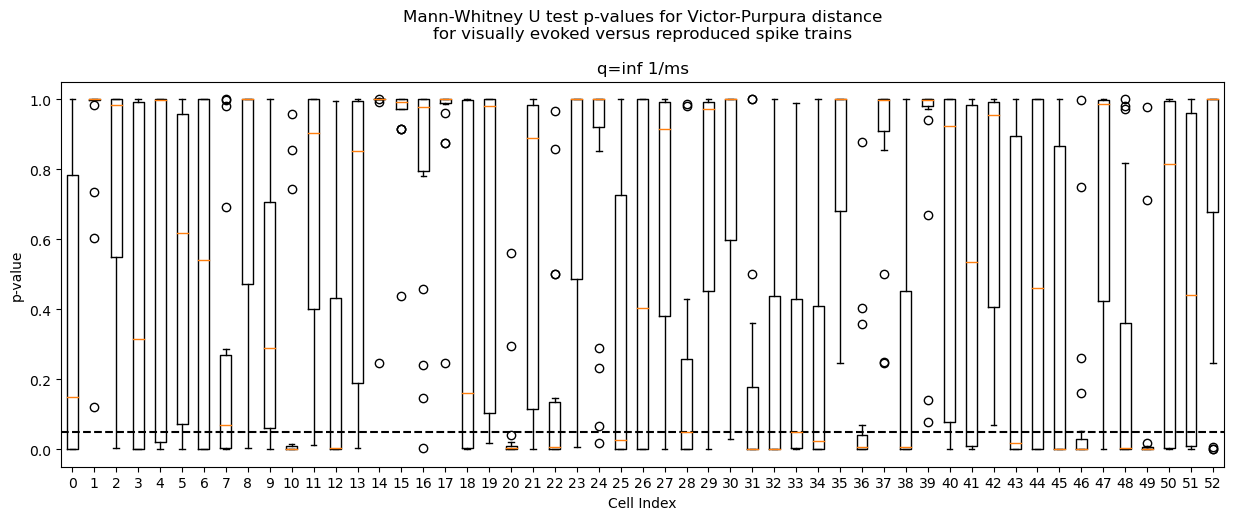

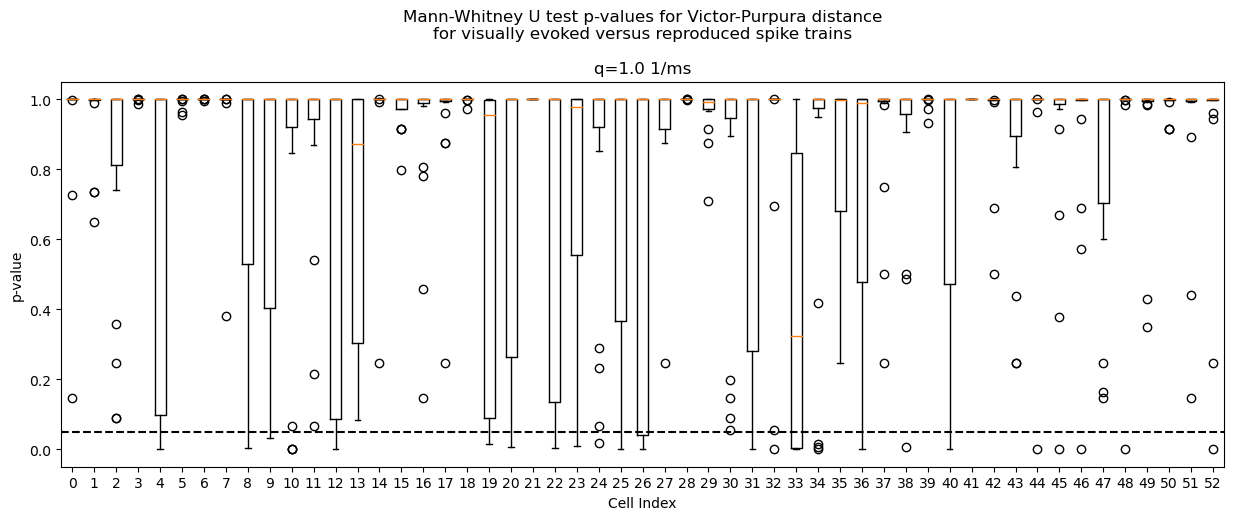

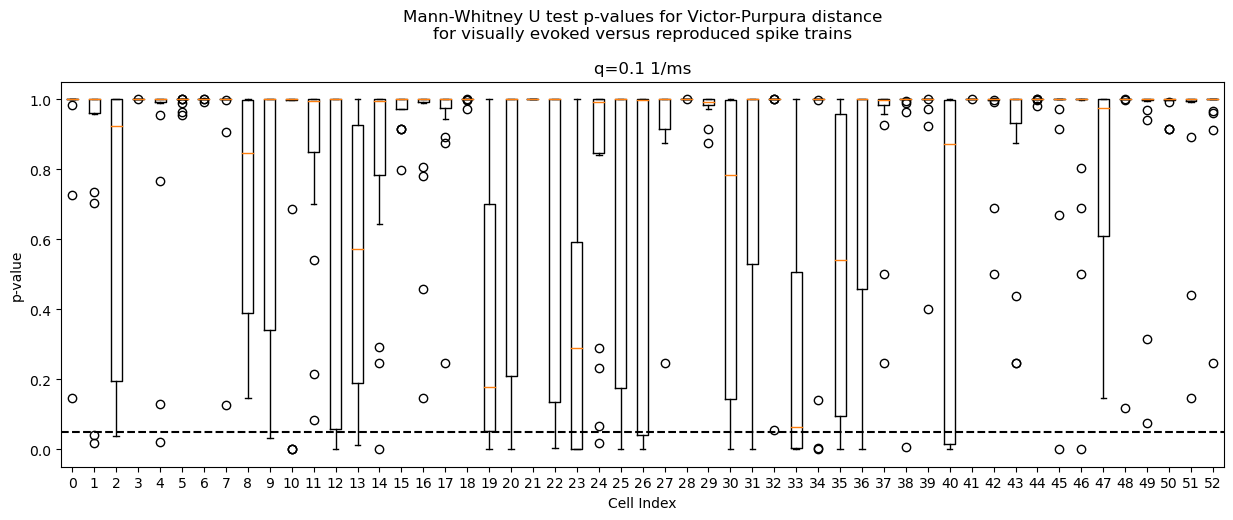

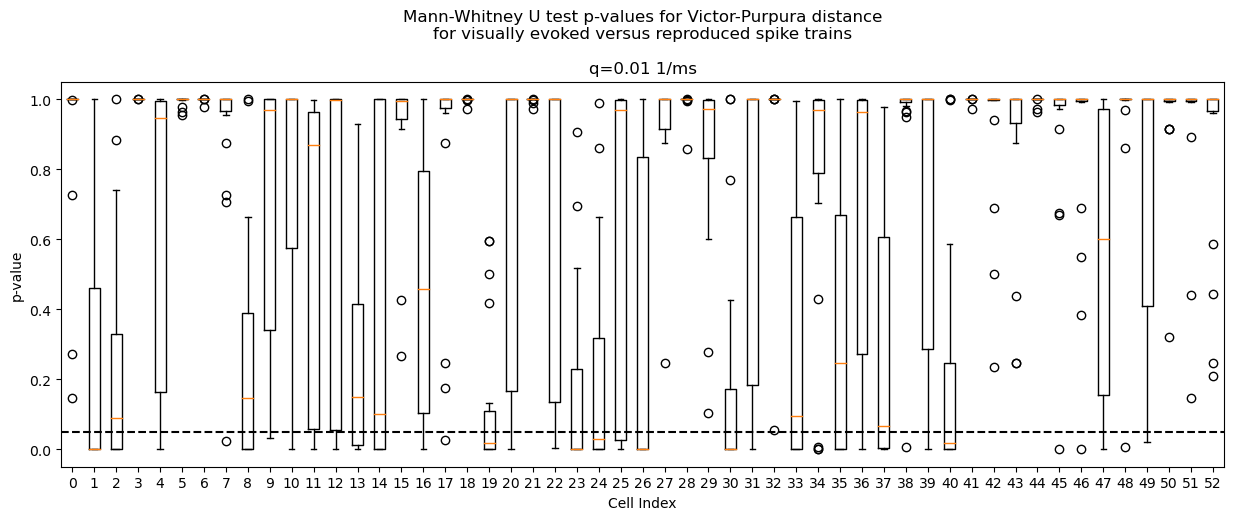

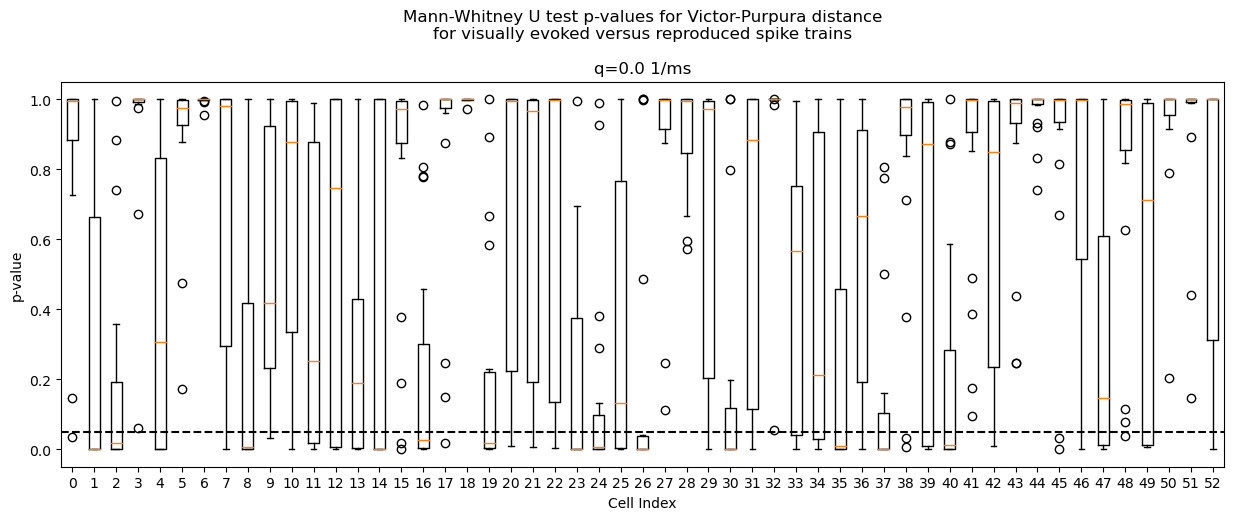

In [281]:
for k,q in enumerate(q_list):
    plt.figure(figsize=(15,5))

    boxplot_data = []
    for c in range(len(selective_cells_of_interest)):
        temp = mannwhitney_p_values[:,k,c]
        # temp = temp[~np.isnan(temp)] # ignore nan (t-test could not be calculated for VP distances for some frames)
        boxplot_data.append(temp)

    plt.boxplot(boxplot_data, labels=np.arange(len(selective_cells_of_interest)))

    plt.axhline(alph, color='k', linestyle='--')
    plt.xlabel("Cell Index")
    plt.ylabel("p-value")
    plt.title(f"Mann-Whitney U test p-values for Victor-Purpura distance\nfor visually evoked versus reproduced spike trains\n\nq={q}")
    plt.show()

100%|██████████| 53/53 [00:01<00:00, 51.27it/s]


MannwhitneyuResult(statistic=116.0, pvalue=0.0020545482018032427)


100%|██████████| 53/53 [00:15<00:00,  3.32it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.37it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.33it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 51.17it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999760203743158)


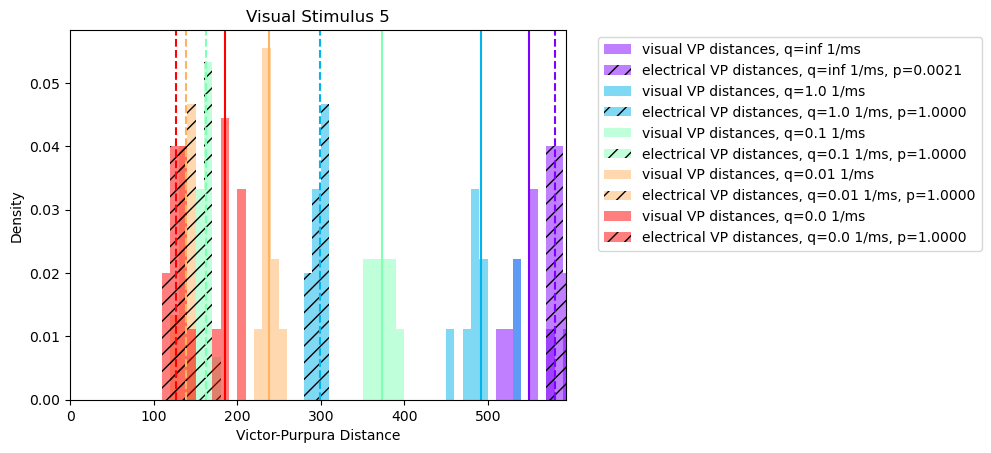

100%|██████████| 53/53 [00:01<00:00, 52.31it/s]


MannwhitneyuResult(statistic=47.5, pvalue=0.8895203717880447)


100%|██████████| 53/53 [00:15<00:00,  3.32it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:16<00:00,  3.28it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:16<00:00,  3.25it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 51.68it/s]


MannwhitneyuResult(statistic=27.0, pvalue=0.9928273081686317)


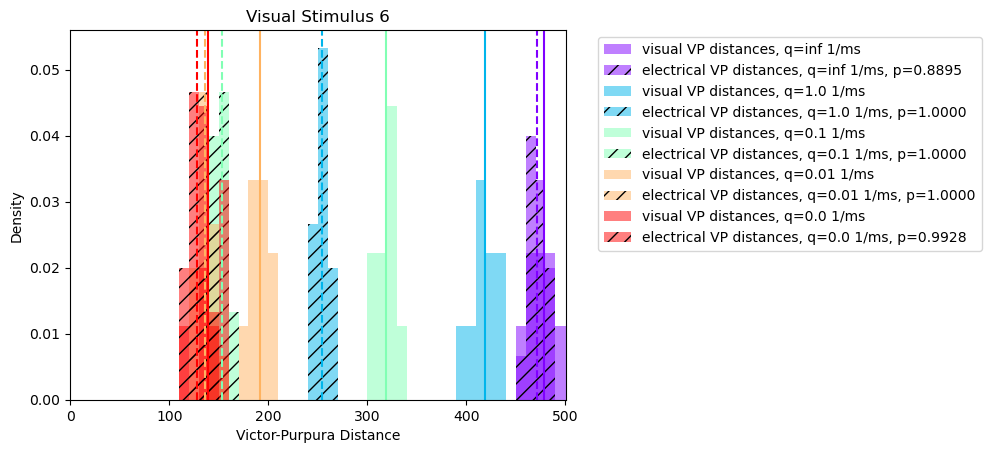

100%|██████████| 53/53 [00:01<00:00, 50.54it/s]


MannwhitneyuResult(statistic=31.0, pvalue=0.9865010635351895)


100%|██████████| 53/53 [00:11<00:00,  4.76it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:11<00:00,  4.79it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:11<00:00,  4.79it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 52.78it/s]


MannwhitneyuResult(statistic=8.0, pvalue=0.999829763911173)


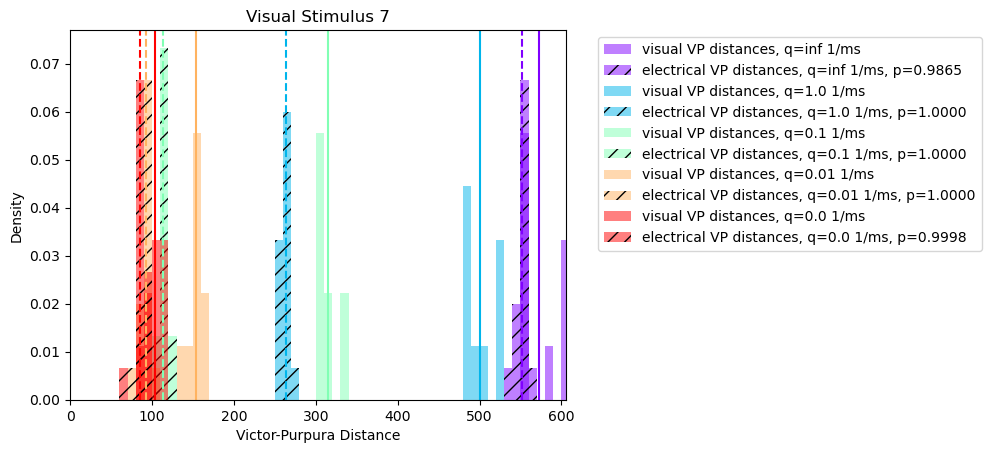

100%|██████████| 53/53 [00:01<00:00, 51.56it/s]


MannwhitneyuResult(statistic=111.0, pvalue=0.005140129729204151)


100%|██████████| 53/53 [00:18<00:00,  2.90it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:18<00:00,  2.92it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:19<00:00,  2.79it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 50.58it/s]


MannwhitneyuResult(statistic=19.0, pvalue=0.998288151181091)


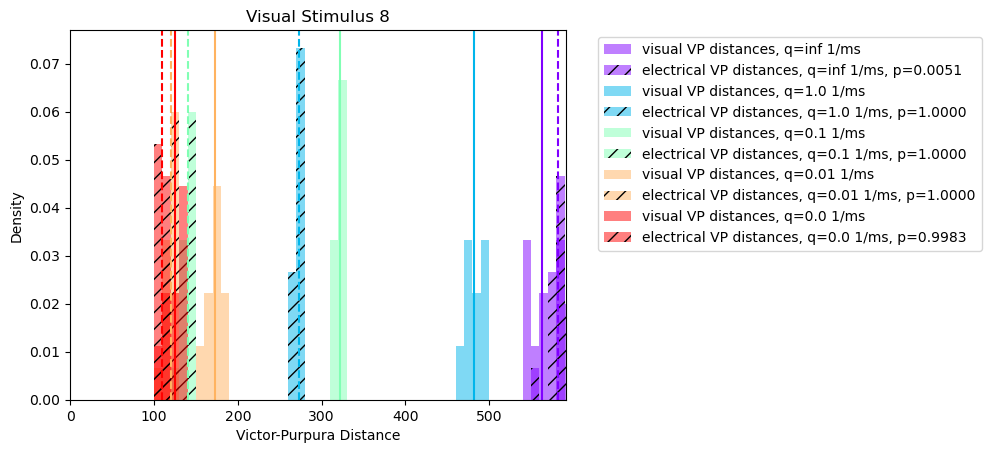

100%|██████████| 53/53 [00:01<00:00, 51.46it/s]


MannwhitneyuResult(statistic=52.5, pvalue=0.8228438405840715)


100%|██████████| 53/53 [00:13<00:00,  3.81it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:14<00:00,  3.76it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:14<00:00,  3.67it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:00<00:00, 53.56it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999758371351561)


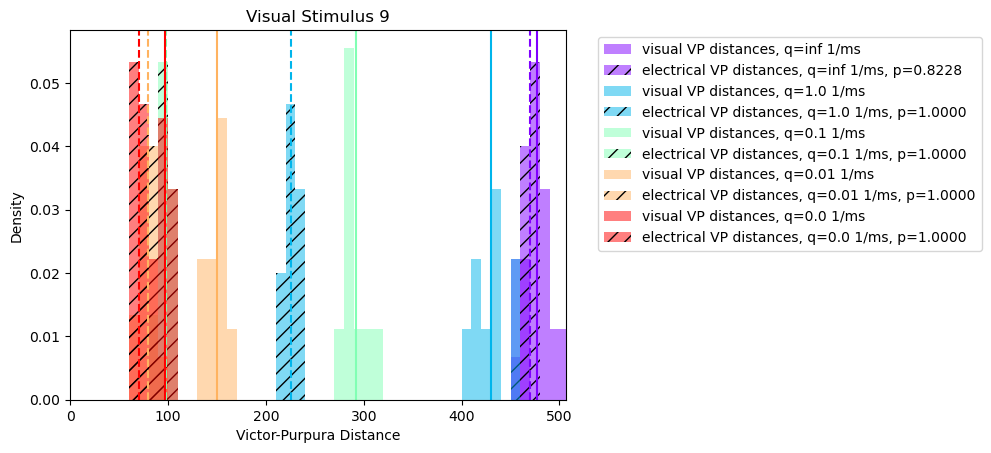

100%|██████████| 53/53 [00:01<00:00, 51.70it/s]


MannwhitneyuResult(statistic=12.5, pvalue=0.9995408461071918)


100%|██████████| 53/53 [00:15<00:00,  3.52it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.47it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.47it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 51.25it/s]


MannwhitneyuResult(statistic=35.5, pvalue=0.9738123098396184)


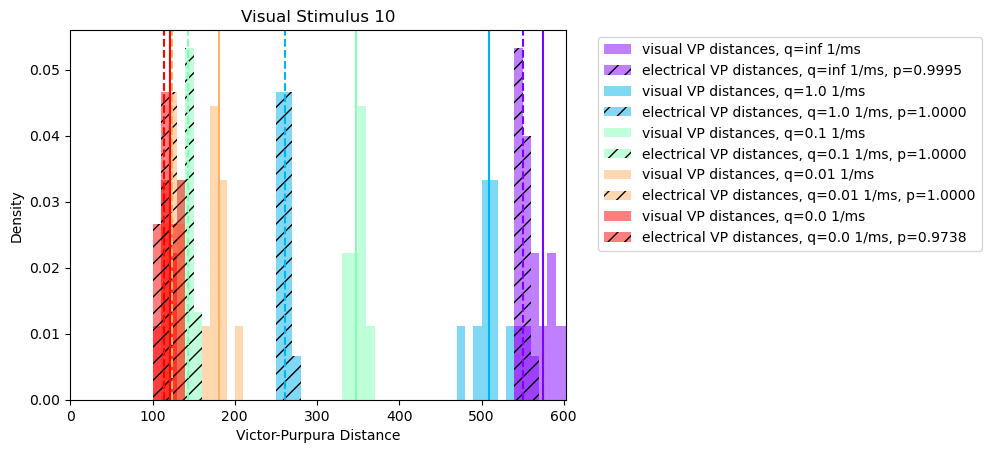

100%|██████████| 53/53 [00:01<00:00, 52.04it/s]


MannwhitneyuResult(statistic=90.5, pvalue=0.08933512604486565)


100%|██████████| 53/53 [00:16<00:00,  3.13it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:16<00:00,  3.15it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:17<00:00,  3.11it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 51.36it/s]


MannwhitneyuResult(statistic=43.0, pvalue=0.9324926667642023)


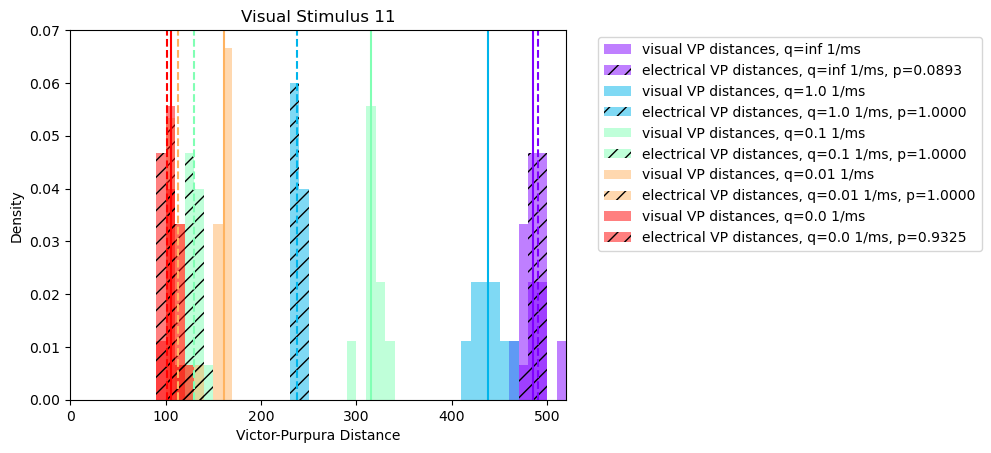

100%|██████████| 53/53 [00:01<00:00, 51.49it/s]


MannwhitneyuResult(statistic=25.0, pvalue=0.9950648973172592)


100%|██████████| 53/53 [00:15<00:00,  3.40it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.42it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.46it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 48.85it/s]


MannwhitneyuResult(statistic=67.0, pvalue=0.5238364217143915)


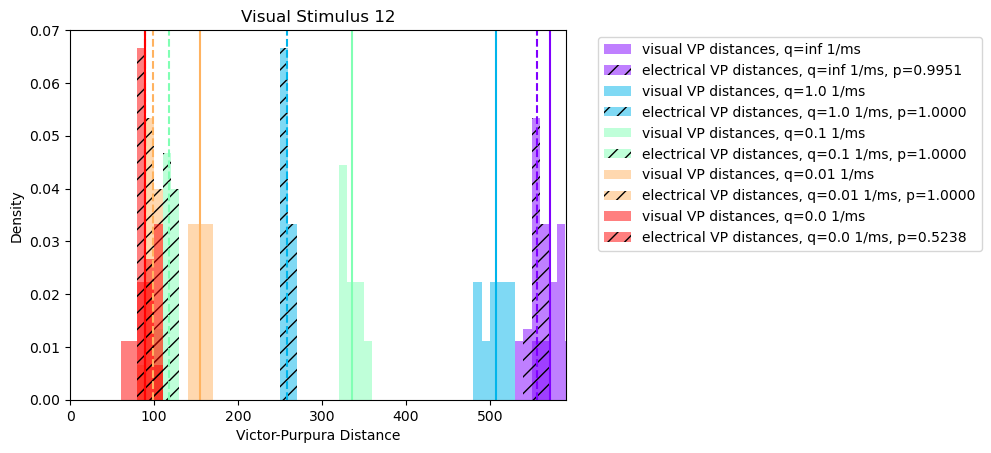

100%|██████████| 53/53 [00:01<00:00, 50.47it/s]


MannwhitneyuResult(statistic=17.0, pvalue=0.9988545861594464)


100%|██████████| 53/53 [00:14<00:00,  3.62it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:14<00:00,  3.58it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:14<00:00,  3.61it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 52.07it/s]


MannwhitneyuResult(statistic=15.0, pvalue=0.9992304335143393)


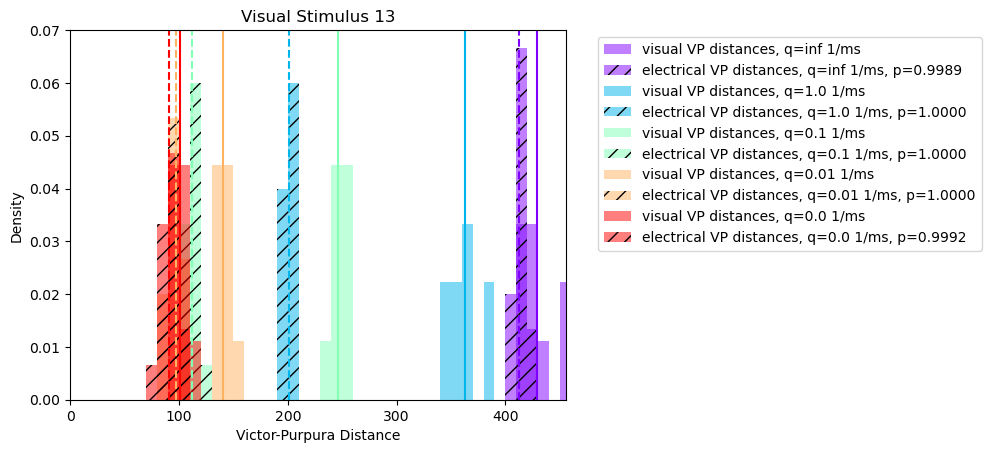

100%|██████████| 53/53 [00:01<00:00, 50.14it/s]


MannwhitneyuResult(statistic=1.0, pvalue=0.9999718297208089)


100%|██████████| 53/53 [00:13<00:00,  3.87it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:13<00:00,  3.89it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:13<00:00,  3.83it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 45.05it/s]


MannwhitneyuResult(statistic=86.5, pvalue=0.13425516491474143)


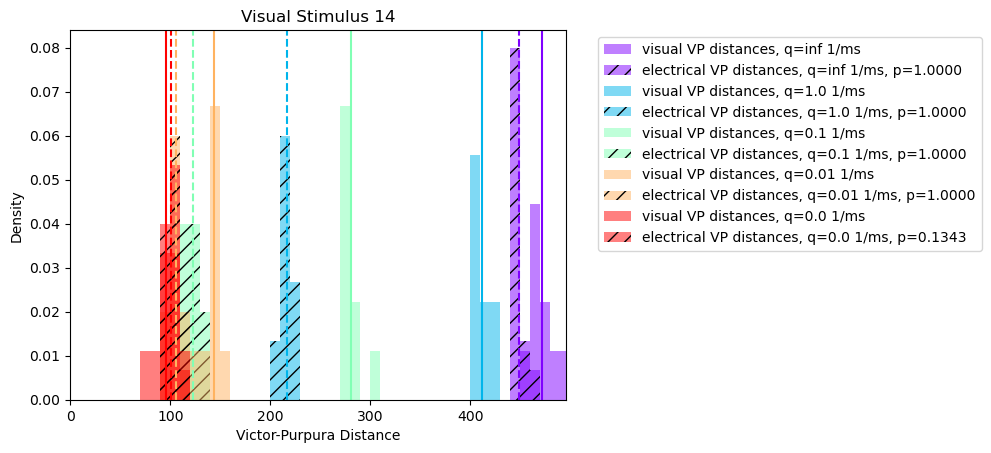

100%|██████████| 53/53 [00:01<00:00, 51.62it/s]


MannwhitneyuResult(statistic=10.0, pvalue=0.9997336262710034)


100%|██████████| 53/53 [00:12<00:00,  4.14it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:12<00:00,  4.16it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:12<00:00,  4.20it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 51.09it/s]


MannwhitneyuResult(statistic=84.5, pvalue=0.16206269020426273)


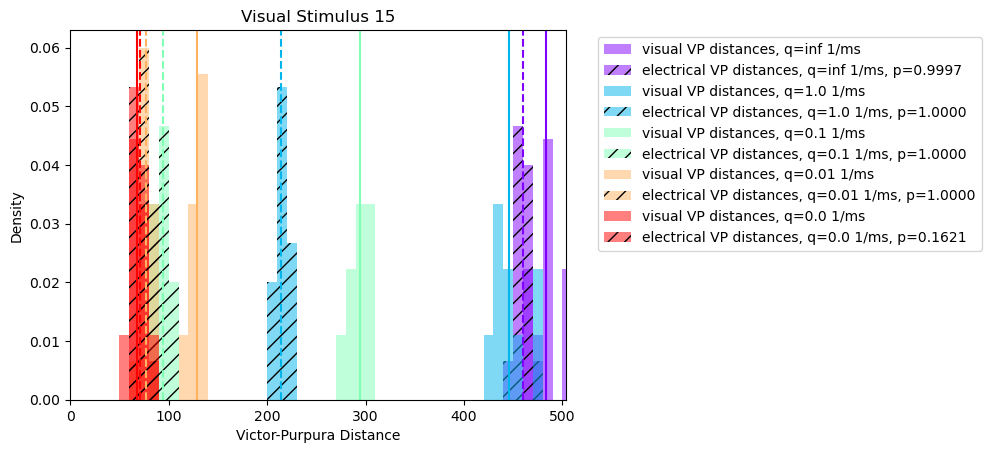

100%|██████████| 53/53 [00:01<00:00, 50.97it/s]


MannwhitneyuResult(statistic=53.5, pvalue=0.806736184895233)


100%|██████████| 53/53 [00:15<00:00,  3.32it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.33it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:16<00:00,  3.23it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 51.94it/s]


MannwhitneyuResult(statistic=115.0, pvalue=0.0025207658161023614)


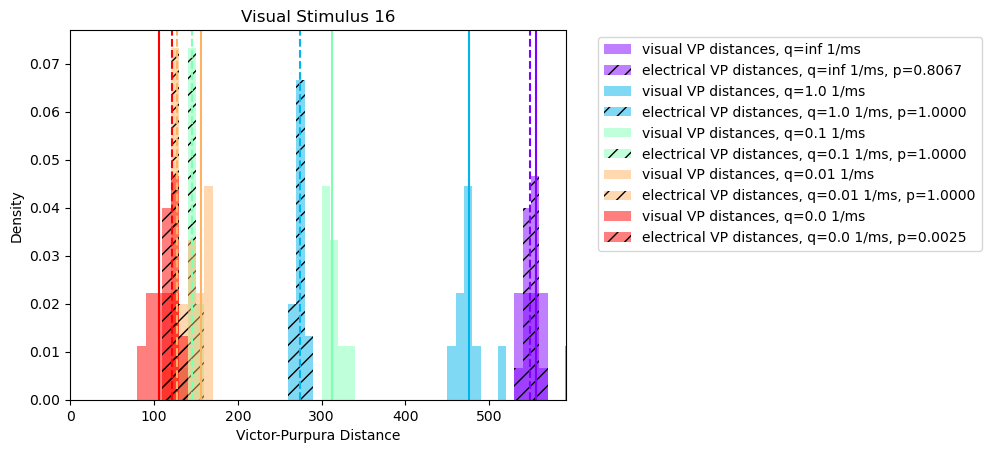

100%|██████████| 53/53 [00:01<00:00, 50.63it/s]


MannwhitneyuResult(statistic=24.5, pvalue=0.9953319628725801)


100%|██████████| 53/53 [00:15<00:00,  3.40it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.48it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.42it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 50.07it/s]


MannwhitneyuResult(statistic=100.5, pvalue=0.02534258709027267)


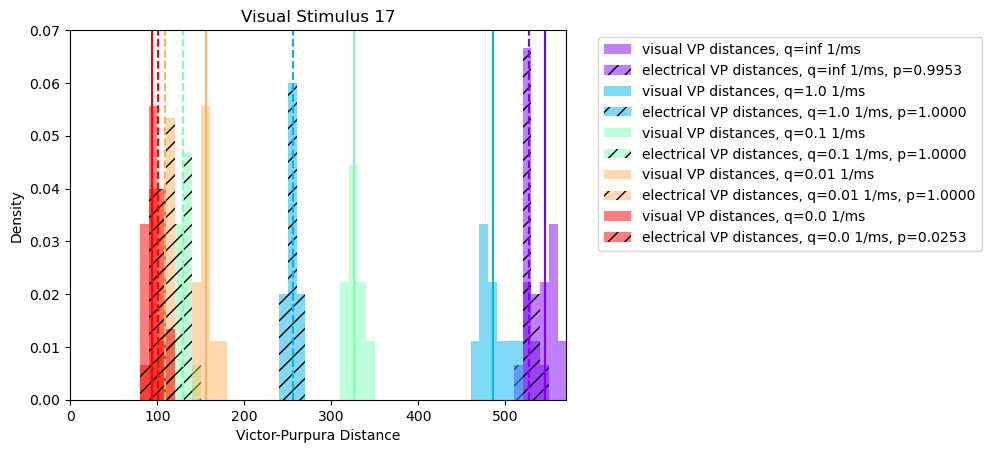

100%|██████████| 53/53 [00:01<00:00, 49.72it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999754673992147)


100%|██████████| 53/53 [00:16<00:00,  3.29it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:16<00:00,  3.28it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:16<00:00,  3.29it/s]


MannwhitneyuResult(statistic=8.0, pvalue=0.9998266903244327)


100%|██████████| 53/53 [00:01<00:00, 49.43it/s]


MannwhitneyuResult(statistic=133.0, pvalue=5.1670747220601025e-05)


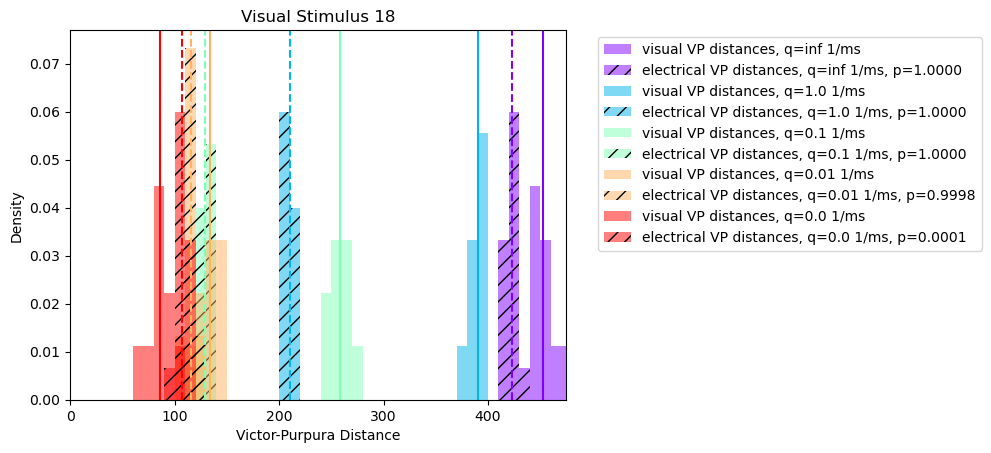

100%|██████████| 53/53 [00:01<00:00, 51.85it/s]


MannwhitneyuResult(statistic=119.5, pvalue=0.0010364558349706978)


100%|██████████| 53/53 [00:13<00:00,  4.00it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:13<00:00,  4.05it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:13<00:00,  4.07it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 52.28it/s]


MannwhitneyuResult(statistic=10.0, pvalue=0.9997358632362336)


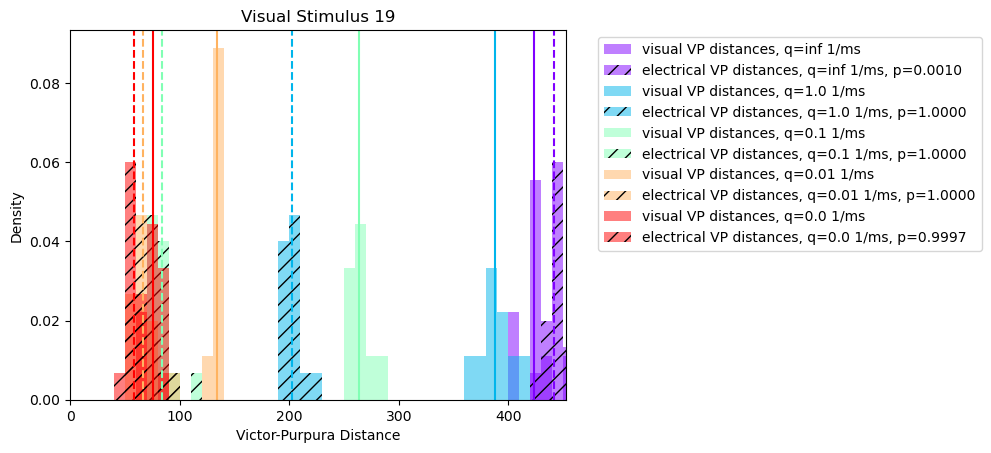

100%|██████████| 53/53 [00:01<00:00, 52.49it/s]


MannwhitneyuResult(statistic=10.0, pvalue=0.9997336262710034)


100%|██████████| 53/53 [00:13<00:00,  3.80it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:14<00:00,  3.77it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:14<00:00,  3.75it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 50.70it/s]


MannwhitneyuResult(statistic=108.0, pvalue=0.008404404767470766)


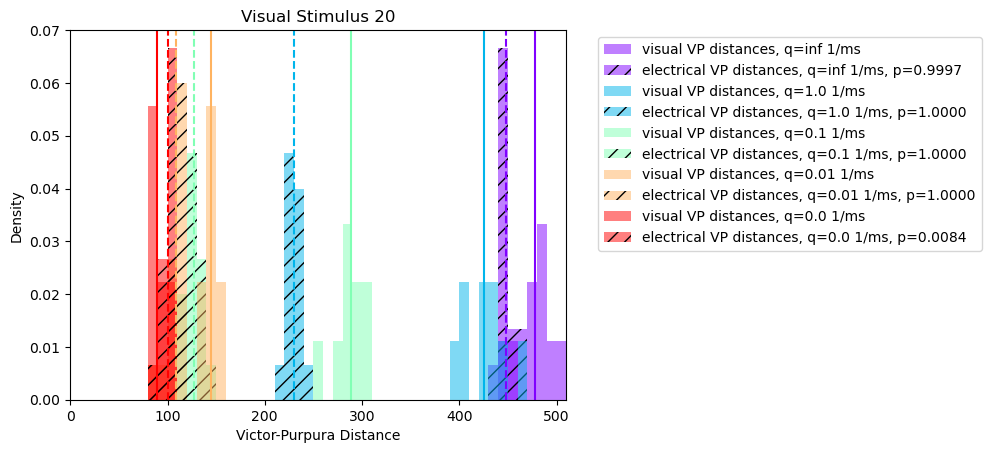

100%|██████████| 53/53 [00:01<00:00, 50.56it/s]


MannwhitneyuResult(statistic=48.5, pvalue=0.8784102526283082)


100%|██████████| 53/53 [00:14<00:00,  3.76it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:14<00:00,  3.62it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:14<00:00,  3.64it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 52.08it/s]


MannwhitneyuResult(statistic=74.5, pvalue=0.34897410431617)


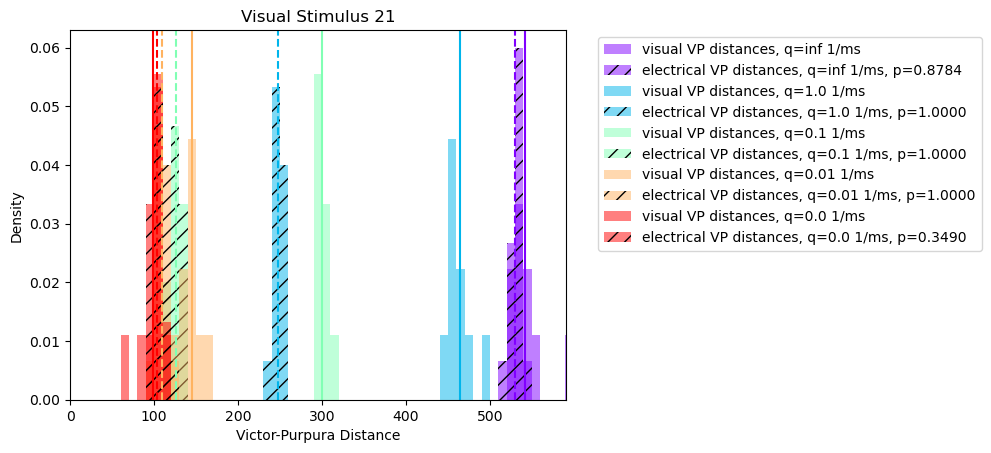

100%|██████████| 53/53 [00:01<00:00, 51.65it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999754673992147)


100%|██████████| 53/53 [00:15<00:00,  3.38it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.37it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.37it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:01<00:00, 50.30it/s]


MannwhitneyuResult(statistic=71.0, pvalue=0.4288760173845275)


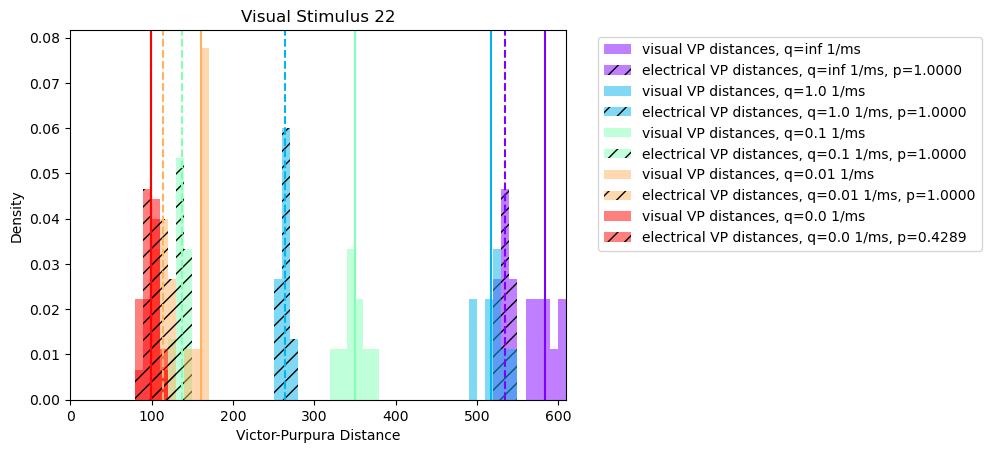

100%|██████████| 53/53 [00:01<00:00, 51.02it/s]


MannwhitneyuResult(statistic=12.0, pvalue=0.9995853570663814)


100%|██████████| 53/53 [00:15<00:00,  3.43it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.40it/s]


MannwhitneyuResult(statistic=0.0, pvalue=0.9999749045866908)


100%|██████████| 53/53 [00:15<00:00,  3.42it/s]


MannwhitneyuResult(statistic=3.0, pvalue=0.9999468736893278)


100%|██████████| 53/53 [00:01<00:00, 50.45it/s]


MannwhitneyuResult(statistic=132.5, pvalue=5.8400940053119694e-05)


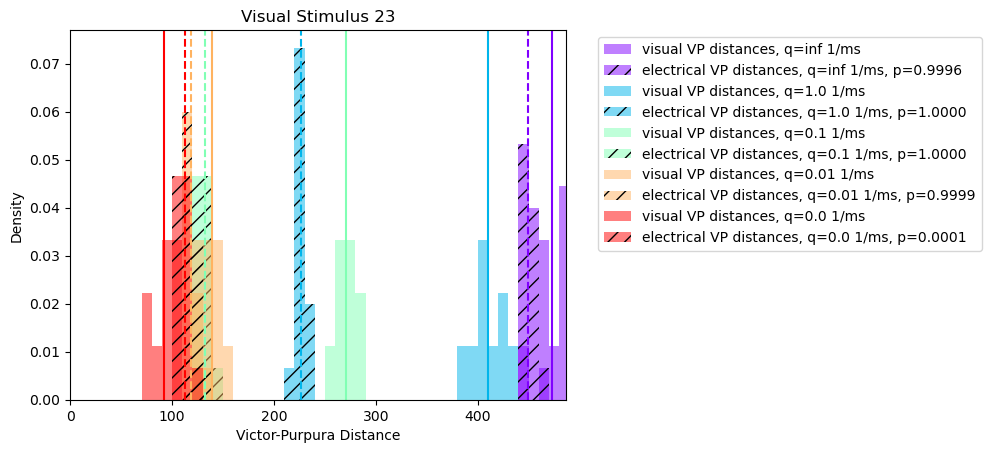

In [286]:
frame_nos = np.arange(5,24)

for frame_no in frame_nos:

    vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
    estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

    vstim_spike_trains = np.empty((vstim_responses.shape[0], vstim_responses.shape[1]), dtype=object)
    for i in range(vstim_responses.shape[0]):
        for j in range(vstim_responses.shape[1]):
            vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i,j]*ms, t_start=-5.0*ms, t_stop=505.0*ms)

    estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], estim_espont_responses.shape[1]), dtype=object)
    for i in range(estim_espont_responses.shape[0]):
        for j in range(estim_espont_responses.shape[1]):
            estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i,j]*ms, t_start=-5.0*ms, t_stop=505.0*ms)

    plt.figure()

    q_list = [np.inf / (1. * ms), 1. / (1. * ms), 1. / (10. * ms), 1. / (100. * ms), 0. / (1. * ms)]
    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0, 1, len(q_list)))
    max_dist_overall = -1

    for k,q in enumerate(q_list):

        vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
        for i in tqdm(range(vstim_spike_trains.shape[1])):

            spike_train_list = []
            for j in range(vstim_spike_trains.shape[0]):
                spike_train_list.append(vstim_spike_trains[j,i])

            vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

        estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
        for i in tqdm(range(estim_espont_spike_trains.shape[1])):

            spike_train_list = []
            spike_train_list.append(vstim_spike_trains[vstim_trial,i])
            for j in range(estim_espont_spike_trains.shape[0]):
                spike_train_list.append(estim_espont_spike_trains[j,i])

            estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)


        alph = 0.05

        vstim_vp = np.sum(vstim_vp_distance[:,0,1:], axis=0)
        estim_espont_vp = np.sum(estim_espont_vp_distance[:,0,1:], axis=0)

        # ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
        # print(ttest)
        mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
        print(mannwhitney)

        # plot Victor-Purpura pairwise distance for visual trials
        max_dist = np.max(np.concatenate((vstim_vp,estim_espont_vp)))
        if max_dist > max_dist_overall:
            max_dist_overall = max_dist
        x = np.arange(0,max_dist+10,10)
        plt.hist(vstim_vp, bins=x, density=True, color=colors[k], alpha=0.5, label=f"visual VP distances, q={q}")

        # plot average Victor-Purpura pairwise distance for target visual trial
        vstim_vp_target = np.sum(vstim_vp_distance[:,0,1:], axis=0)
        plt.axvline(np.mean(vstim_vp_target), color=colors[k], linestyle='-')

        # plot Victor-Purpura distance for selected visual trial to estim espont trials
        plt.hist(estim_espont_vp, bins=x, density=True, color=colors[k], alpha=0.5, hatch='//', label=f"electrical VP distances, q={q}, p={mannwhitney[1]:.4f}")

        # plot average
        plt.axvline(np.mean(estim_espont_vp), color=colors[k], linestyle='--')

    plt.title(f"Visual Stimulus {frame_no}")
    plt.xlabel("Victor-Purpura Distance")
    plt.ylabel("Density")
    plt.xlim(0,max_dist_overall)
    # plt.ylim(0,1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

In [307]:
frame_nos = np.arange(5,24)
q_list = [np.inf / (1. * ms), 1. / (1. * ms), 1. / (5. * ms), 1. / (10. * ms), 1. / (50. * ms), 1. / (100. * ms), 0. / (1. * ms)]

mannwhitney_p_values_together = np.empty((len(frame_nos), len(q_list)))
vstim_vp_distances = np.empty((len(selective_cells_of_interest), len(frame_nos), len(q_list), vstim_responses.shape[0]-1))
estim_espont_vp_distances = np.empty((len(selective_cells_of_interest), len(frame_nos), len(q_list), estim_espont_responses.shape[0]))

for frame_no in tqdm(frame_nos):

    vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
    estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

    vstim_spike_trains = np.empty((vstim_responses.shape[0], vstim_responses.shape[1]), dtype=object)
    for i in range(vstim_responses.shape[0]):
        for j in range(vstim_responses.shape[1]):
            vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i,j]*ms, t_start=-5.0*ms, t_stop=505.0*ms)

    estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], estim_espont_responses.shape[1]), dtype=object)
    for i in range(estim_espont_responses.shape[0]):
        for j in range(estim_espont_responses.shape[1]):
            estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i,j]*ms, t_start=-5.0*ms, t_stop=505.0*ms)

    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0, 1, len(q_list)))

    for k,q in enumerate(q_list):

        vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
        for i in range(vstim_spike_trains.shape[1]):

            spike_train_list = []
            for j in range(vstim_spike_trains.shape[0]):
                spike_train_list.append(vstim_spike_trains[j,i])

            vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

        estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
        for i in range(estim_espont_spike_trains.shape[1]):

            spike_train_list = []
            spike_train_list.append(vstim_spike_trains[vstim_trial,i])
            for j in range(estim_espont_spike_trains.shape[0]):
                spike_train_list.append(estim_espont_spike_trains[j,i])

            estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)


        vstim_vp = np.sum(vstim_vp_distance[:,0,1:], axis=0)
        estim_espont_vp = np.sum(estim_espont_vp_distance[:,0,1:], axis=0)

        # ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
        # ttest_p_values_together[frame_no-5,k] = ttest[1]
        mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
        mannwhitney_p_values_together[frame_no-5,k] = mannwhitney[1]

        vstim_vp_distances[:,frame_no-5,k,:] = vstim_vp_distance[:,0,1:]
        estim_espont_vp_distances[:,frame_no-5,k,:] = estim_espont_vp_distance[:,0,1:]

100%|██████████| 19/19 [32:45<00:00, 103.46s/it]


In [311]:
print(mannwhitney_p_values_together.shape)
print(vstim_vp_distances.shape)
print(estim_espont_vp_distances.shape)

(19, 7)
(53, 19, 7, 9)
(53, 19, 7, 15)


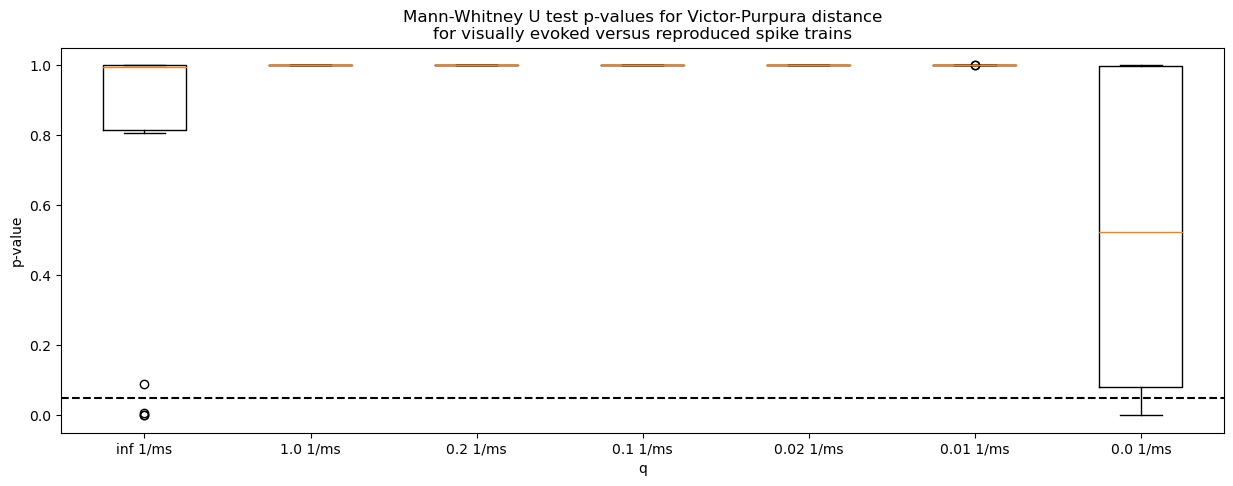

In [312]:
plt.figure(figsize=(15,5))

boxplot_data = []
for k,q in enumerate(q_list):
    boxplot_data.append(mannwhitney_p_values_together[:,k])

plt.boxplot(boxplot_data, labels=q_list)

plt.axhline(alph, color='k', linestyle='--')
plt.xlabel("q")
plt.ylabel("p-value")
plt.title(f"Mann-Whitney U test p-values for Victor-Purpura distance\nfor visually evoked versus reproduced spike trains")
plt.show()

/Volumes/Lab/Development/anaconda3/envs/RETINA/lib/python3.9/site-packages/quantities/quantity.py:351: RuntimeWarning: divide by zero encountered in true_divide
  return np.true_divide(other, self)


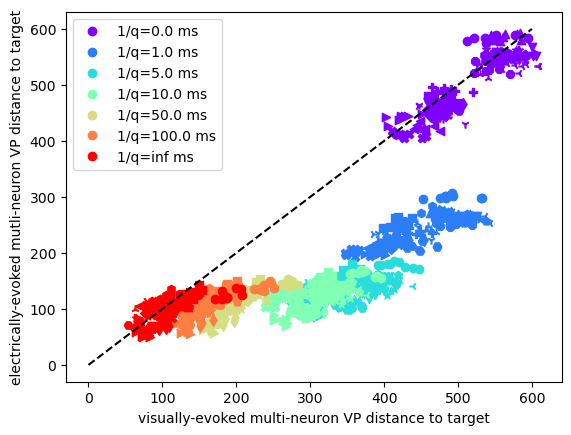

In [313]:
# vstim_vp_distances[cell,frame_no-5,q,trial]
# estim_espont_vp_distances[cell,frame_no-5,q,trial]

# Make a color vector from the rainbow colormap for each of the q values
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0, 1, len(q_list)))

# Make a shape vector for each of the 19 visual stimuli
shapes = ['o', 's', 'v', '^', 'd', 'p', 'P', '*', 'X', 'D', 'H', 'h', '8', '<', '>', '1', '2', '3', '4']

# Create the scatter plot
fig, ax = plt.subplots()
for i in range(len(colors)):
    for j in range(len(shapes)):
        ax.scatter(np.sum(vstim_vp_distances[:,j,i,:],axis=0), np.sum(estim_espont_vp_distances[:,j,i,:9],axis=0), color=colors[i], marker=shapes[j])
        # ax.scatter(vstim_vp_distances[:,j,i,:], estim_espont_vp_distances[:,j,i,:9], color=colors[i], marker=shapes[j])

# Set the labels and title
ax.set_xlabel('visually-evoked multi-neuron VP distance to target')
ax.set_ylabel('electrically-evoked mutli-neuron VP distance to target')

# Set the legend
legend_labels = [f"1/q={1/q}" for q in q_list]
legend_handles = [plt.Line2D([], [], color=colors[i], marker='o', linestyle='None') for i in range(len(colors))]
ax.legend(legend_handles, legend_labels)

# Make a x=y line
x = np.linspace(0, 600, 600)
ax.plot(x, x, color='k', linestyle='--')

# Show the plot
plt.show()